# UGICIS — Uganda Integrated Care Intelligence System
## Master Notebook (PhD-level EDA, Feature Engineering & Modelling)

**Research objective.** Develop a *Missingness-Aware Multi-Task Clinical Intelligence System* for HIV-hypertension prediction using real Ugandan healthcare data (Dryad `doi:10.5061/dryad.9p8cz8wqg`, 2,645 patients, 52 facilities).

**Notebook contents**
1. **Setup** — imports, paths, plotting style
2. **Data load** — read the raw Dryad CSV
3. **Exploratory Data Analysis** — basic profile + 10 advanced sub-blocks (3.A normality + QQ, 3.B logistic odds ratios, 3.C mutual information, 3.D VIF + condition number, 3.E formal MAR test, 3.F Bayesian Beta-Binomial, 3.G phenotyping, 3.H IsolationForest, 3.I facility ICC, 3.J class separability)
4. **Data preprocessing** — sentinel cleanup, BP parsing, stratified split, scaling, binning, imputation comparison, missingness indicators
5. **Feature engineering** — basic FE + 9 advanced sub-blocks (5.A OOF target encoding, 5.B WoE + IV, 5.C natural cubic splines, 5.D Box-Tidwell linearity, 5.E MICE M=5 + Rubin's rules, 5.F permutation importance + RFECV, 5.G SMOTENC, 5.H t-SNE, 5.I feature report card)
6. **Modelling matrix** — leakage-free X / y construction
7. **Cross-validation** — 5-fold stratified XGBoost
8. **SHAP explainability**
9. **Clinical calibration**

All saved tables go to `reports/tables/` and all simulated missingness scenarios to `data/processed/sim/`.


## 1. Setup

Imports, fixed seed, output paths.

In [1]:
from __future__ import annotations
import json
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import StratifiedKFold, train_test_split, KFold
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, PowerTransformer,
                                   PolynomialFeatures, LabelEncoder)
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif, RFECV
from sklearn.inspection import permutation_importance
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             precision_recall_curve, average_precision_score, brier_score_loss,
                             silhouette_score, davies_bouldin_score)
from sklearn.calibration import calibration_curve

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrix

from imblearn.over_sampling import SMOTENC

import xgboost as xgb
import shap

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger("UGICIS")

# Review item #14: keep RuntimeWarning visible (NaN, div-by-zero, convergence failures).
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.figsize": (10, 6), "figure.dpi": 110, "savefig.dpi": 150})

PROJECT_ROOT  = Path.cwd().resolve()
RAW_CSV       = PROJECT_ROOT / "Dataset" / "Uganda_Int_HIV_HTN_baseline_EUopensci.deident.v3.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SIM_DIR       = PROCESSED_DIR / "sim"
TBL_DIR       = PROJECT_ROOT / "reports" / "tables"
FIG_DIR       = PROJECT_ROOT / "reports" / "figures"
for d in [PROCESSED_DIR, SIM_DIR, TBL_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Imports complete. PROJECT_ROOT =", PROJECT_ROOT)


Imports complete. PROJECT_ROOT = /home/robotics1025/Documents/machine_learing/project/uganda-integrated-care-intelligence-system


## 2. Load the Clinical Dataset

In [2]:
df = pd.read_csv(RAW_CSV)
print("shape:", df.shape)
df.head()


shape: (2645, 19)


,hc_code,clinicid,age_category,female,artyr,hc4,smoke,alcohol,overweight,marital_status,exercise,bpmdate6mo,htn_now,category,prior_unknown,new_dx,bpfinal,htn_stage,treat
0,45,1,0,0,3,1,2,1,0,2,0,0,0,2,0,0,124/085,0,0
1,45,2,0,0,3,1,2,1,0,2,0,0,0,2,0,0,122/084,0,0
2,45,3,0,0,3,1,2,2,0,2,0,0,1,2,0,1,137/093,1,0
3,45,4,1,1,3,1,2,2,1,2,0,0,0,2,0,0,125/065,0,0
4,45,5,1,1,2,1,2,2,0,2,0,0,0,2,0,0,127/065,0,0


## 3. Exploratory Data Analysis

Profile, sentinel audit, missingness, BP visualisations, hypothesis tests with FDR correction, bootstrap CIs, Little's MCAR test, facility analysis. Ten advanced sub-blocks (3.A - 3.J) follow.

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2645 entries, 0 to 2644
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   hc_code         2645 non-null   int64 
 1   clinicid        2645 non-null   int64 
 2   age_category    2645 non-null   int64 
 3   female          2645 non-null   int64 
 4   artyr           2645 non-null   int64 
 5   hc4             2645 non-null   int64 
 6   smoke           2645 non-null   int64 
 7   alcohol         2645 non-null   int64 
 8   overweight      2645 non-null   int64 
 9   marital_status  2645 non-null   int64 
 10  exercise        2645 non-null   int64 
 11  bpmdate6mo      2645 non-null   int64 
 12  htn_now         2645 non-null   int64 
 13  category        2645 non-null   int64 
 14  prior_unknown   2645 non-null   int64 
 15  new_dx          2645 non-null   int64 
 16  bpfinal         2645 non-null   object
 17  htn_stage       2645 non-null   int64 
 18  treat   

In [4]:
# statistical summary (numeric columns only — note that -9 sentinels still pollute the means)
df.describe()


,hc_code,clinicid,age_category,female,artyr,hc4,smoke,alcohol,overweight,marital_status,exercise,bpmdate6mo,htn_now,category,prior_unknown,new_dx,htn_stage,treat
count,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000
mean,26.458223,1323.000000,0.474480,0.543289,2.284310,0.305482,1.899433,1.707750,0.188658,2.232136,0.783365,0.007561,0.135728,1.981474,0.012098,0.105104,0.177316,0.015501
std,14.958296,763.690055,0.499443,0.498217,0.822849,0.460698,0.300812,0.454882,0.597796,0.596088,0.412030,0.086644,0.342564,0.134867,0.109346,0.306745,0.511531,0.123557
min,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,-9.000000,-9.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,662.000000,0.000000,0.000000,2.000000,0.000000,2.000000,1.000000,0.000000,2.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,26.000000,1323.000000,0.000000,1.000000,2.000000,0.000000,2.000000,2.000000,0.000000,2.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
75%,39.000000,1984.000000,1.000000,1.000000,3.000000,1.000000,2.000000,2.000000,0.000000,3.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
max,52.000000,2645.000000,1.000000,1.000000,4.000000,1.000000,2.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,3.000000,1.000000


In [5]:
# object-typed columns (only bpfinal is a string)
df.describe(include="object")


,bpfinal
count,2645
unique,1227
top,120/080
freq,13


In [6]:
# sentinel inventory — count how many -9s appear in each numeric column
sentinel_counts = (df.select_dtypes(include="number") == -9).sum()
sentinel_counts = sentinel_counts[sentinel_counts > 0].sort_values(ascending=False)
sentinel_counts.to_frame("n_sentinels_(-9)")


,n_sentinels_(-9)
overweight,6
marital_status,1


In [7]:
# bpfinal sentinels — count how many BP strings are "-9/-9"
(df["bpfinal"] == "-9/-9").sum(), df["bpfinal"].isna().sum()


(np.int64(1), np.int64(0))

In [8]:
# replace numeric sentinels with NaN, parse the BP string into two numeric columns
df_clean = df.replace(-9, np.nan).copy()


def parse_bp(s):
    if pd.isna(s) or str(s).strip() in {"-9/-9", "-9", "", "nan"} or "/" not in str(s):
        return (np.nan, np.nan)
    try:
        sys_v, dia_v = (int(p) for p in str(s).split("/", 1))
    except ValueError:
        return (np.nan, np.nan)
    if not (60 <= sys_v <= 260 and 30 <= dia_v <= 160):
        return (np.nan, np.nan)
    return (float(sys_v), float(dia_v))


bp_pairs = df_clean["bpfinal"].apply(parse_bp)
df_clean["bp_systolic"]  = bp_pairs.apply(lambda t: t[0])
df_clean["bp_diastolic"] = bp_pairs.apply(lambda t: t[1])
df_clean.head()


,hc_code,clinicid,age_category,female,artyr,hc4,smoke,alcohol,overweight,marital_status,...,bpmdate6mo,htn_now,category,prior_unknown,new_dx,bpfinal,htn_stage,treat,bp_systolic,bp_diastolic
0,45,1,0,0,3,1,2,1,0.0,2.0,...,0,0,2,0,0,124/085,0,0,124.0,85.0
1,45,2,0,0,3,1,2,1,0.0,2.0,...,0,0,2,0,0,122/084,0,0,122.0,84.0
2,45,3,0,0,3,1,2,2,0.0,2.0,...,0,1,2,0,1,137/093,1,0,137.0,93.0
3,45,4,1,1,3,1,2,2,1.0,2.0,...,0,0,2,0,0,125/065,0,0,125.0,65.0
4,45,5,1,1,2,1,2,2,0.0,2.0,...,0,0,2,0,0,127/065,0,0,127.0,65.0


In [9]:
# recode 1=Yes / 2=No to 1/0 for the two columns that use the inverted scale
df_clean["smoke"]   = df_clean["smoke"].map({1: 1, 2: 0})
df_clean["alcohol"] = df_clean["alcohol"].map({1: 1, 2: 0})
df_clean[["smoke", "alcohol"]].describe()


,smoke,alcohol
count,2645.000000,2645.000000
mean,0.100567,0.292250
std,0.300812,0.454882
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,1.000000
max,1.000000,1.000000


In [10]:
# checking for missing values (post-sentinel replacement)
miss = df_clean.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss.to_frame("n_missing").assign(pct=lambda d: (d["n_missing"] / len(df_clean) * 100).round(2))


,n_missing,pct
overweight,6,0.23
marital_status,1,0.04
bp_systolic,1,0.04
bp_diastolic,1,0.04


In [11]:
# class balance for each prediction target (htn_now, htn_stage, treat)
for tgt in ["htn_now", "htn_stage", "treat"]:
    print(f"--- {tgt} ---")
    print(df_clean[tgt].value_counts(dropna=False).sort_index().to_string())
    print()


--- htn_now ---
htn_now
0    2286
1     359

--- htn_stage ---
htn_stage
0    2303
1     241
2      75
3      26

--- treat ---
treat
0    2604
1      41



2026-05-10 04:56:04,910 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-10 04:56:04,920 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-10 04:56:04,956 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-10 04:56:04,963 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-10 04:56:04,993 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


...

2026-05-10 04:56:05,364 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-10 04:56:05,396 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-10 04:56:05,402 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-10 04:56:05,441 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-10 04:56:05,448 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


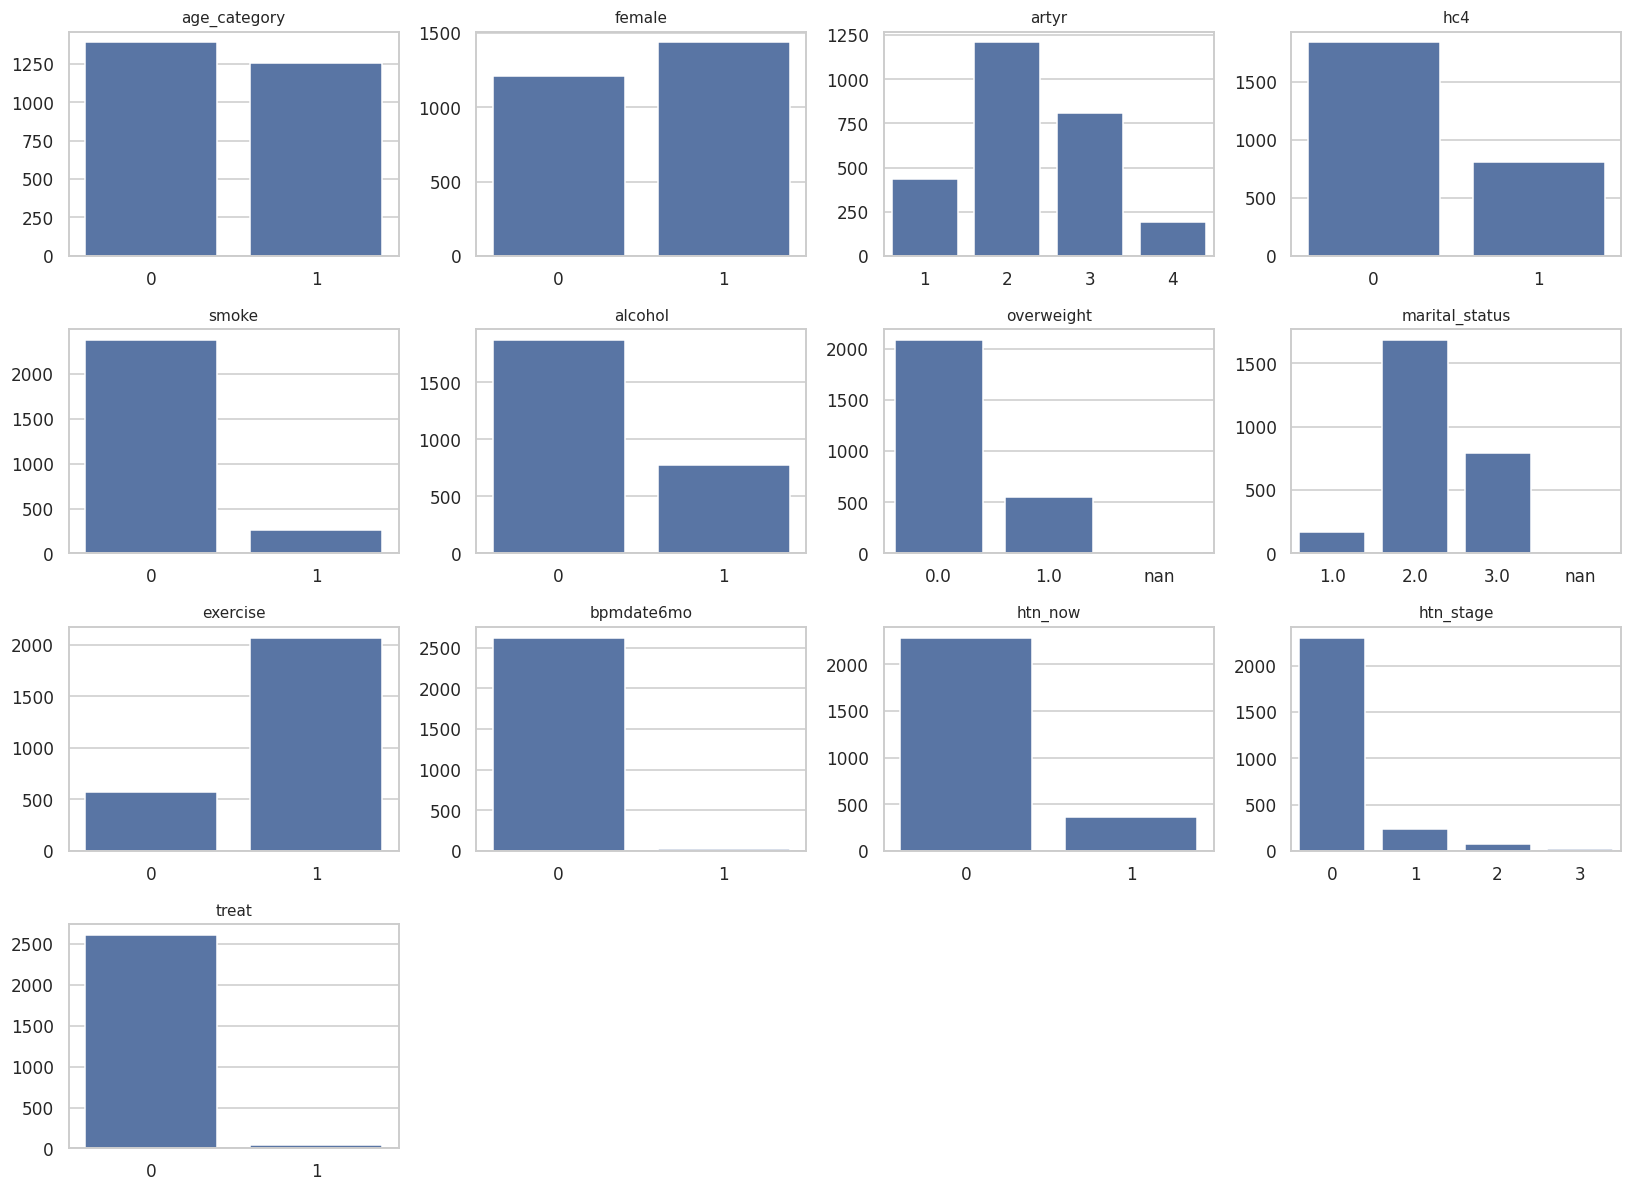

In [12]:
# visualizing categorical feature distributions (countplot grid)
CAT_COLS = ["age_category", "female", "artyr", "hc4", "smoke", "alcohol",
            "overweight", "marital_status", "exercise", "bpmdate6mo",
            "htn_now", "htn_stage", "treat"]

fig, axes = plt.subplots(4, 4, figsize=(15, 11))
for ax, col in zip(axes.flat, CAT_COLS):
    counts = df_clean[col].value_counts(dropna=False).sort_index()
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax,
                color=sns.color_palette("deep")[0])
    ax.set_title(col, fontsize=10); ax.set_xlabel(""); ax.set_ylabel("")
for ax in axes.flat[len(CAT_COLS):]:
    ax.axis("off")
plt.tight_layout(); plt.show()


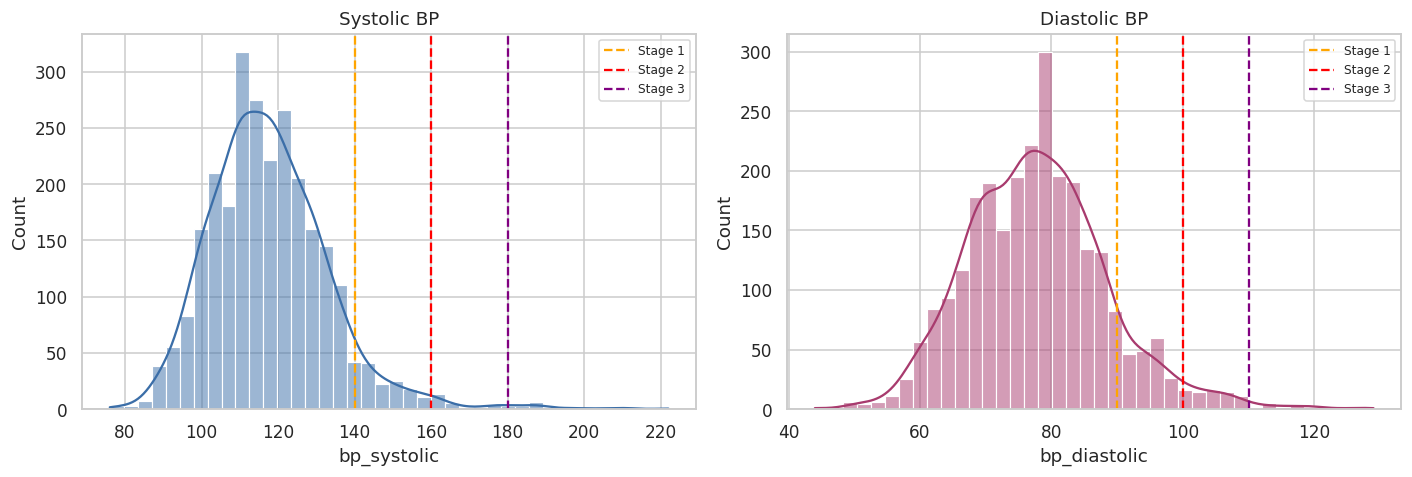

In [13]:
# BP histograms with the 2020 ASH/ISH stage thresholds overlaid
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df_clean["bp_systolic"].dropna(), bins=40, kde=True, ax=axes[0], color="#3b6ea8")
for x, c, lbl in [(140, "orange", "Stage 1"), (160, "red", "Stage 2"), (180, "purple", "Stage 3")]:
    axes[0].axvline(x, ls="--", color=c, label=lbl)
axes[0].set_title("Systolic BP"); axes[0].legend(fontsize=8)

sns.histplot(df_clean["bp_diastolic"].dropna(), bins=40, kde=True, ax=axes[1], color="#a83b6e")
for x, c, lbl in [(90, "orange", "Stage 1"), (100, "red", "Stage 2"), (110, "purple", "Stage 3")]:
    axes[1].axvline(x, ls="--", color=c, label=lbl)
axes[1].set_title("Diastolic BP"); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()


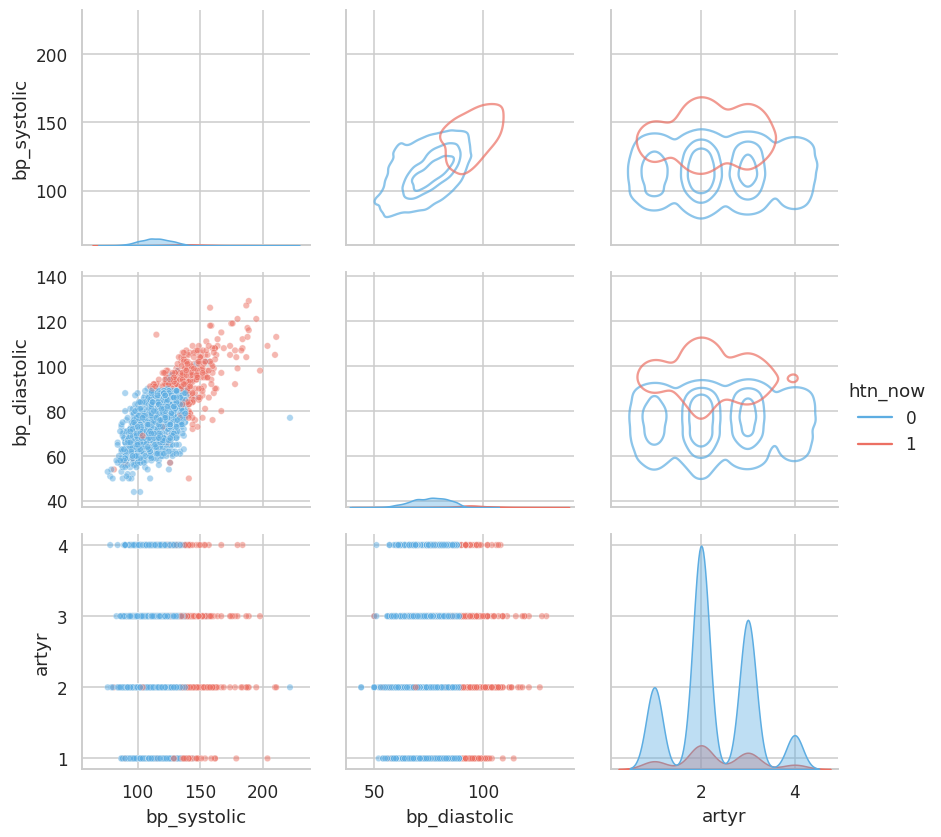

In [14]:
# PairGrid (clinical analogue of sns.pairplot) — BP and lifestyle numerics, colored by htn_now
pair_cols = ["bp_systolic", "bp_diastolic", "artyr"]
g = sns.PairGrid(df_clean.dropna(subset=pair_cols + ["htn_now"]),
                 vars=pair_cols, hue="htn_now", palette={0: "#5dade2", 1: "#ec7063"},
                 height=2.6)
g.map_lower(sns.scatterplot, alpha=0.5, s=18)
g.map_diag(sns.kdeplot, fill=True, alpha=0.4)
g.map_upper(sns.kdeplot, levels=4, alpha=0.7)
g.add_legend(title="htn_now")
plt.show()


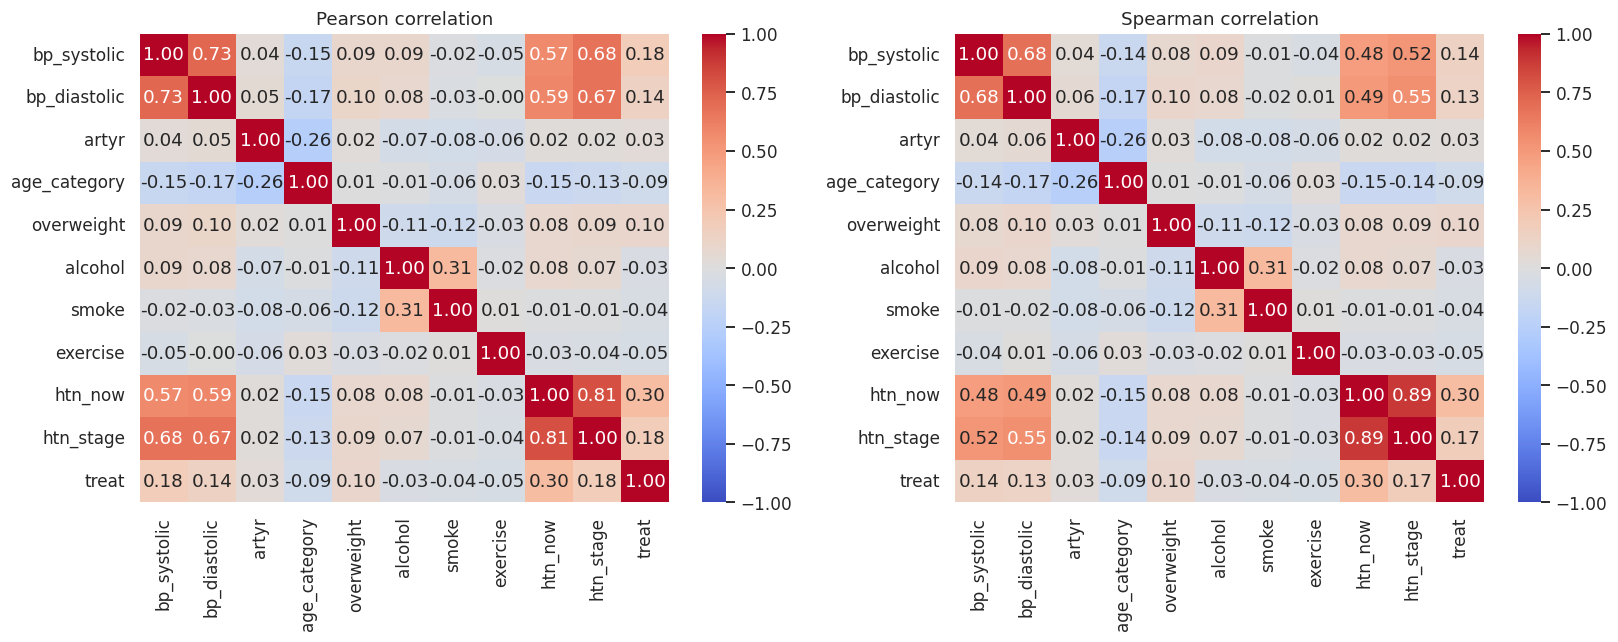

In [15]:
# correlation heatmap — Pearson and Spearman side-by-side on numeric columns
num_cols_for_corr = ["bp_systolic", "bp_diastolic", "artyr", "age_category",
                     "overweight", "alcohol", "smoke", "exercise",
                     "htn_now", "htn_stage", "treat"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(df_clean[num_cols_for_corr].corr(method="pearson"),
            annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pearson correlation")

sns.heatmap(df_clean[num_cols_for_corr].corr(method="spearman"),
            annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Spearman correlation")
plt.tight_layout(); plt.show()


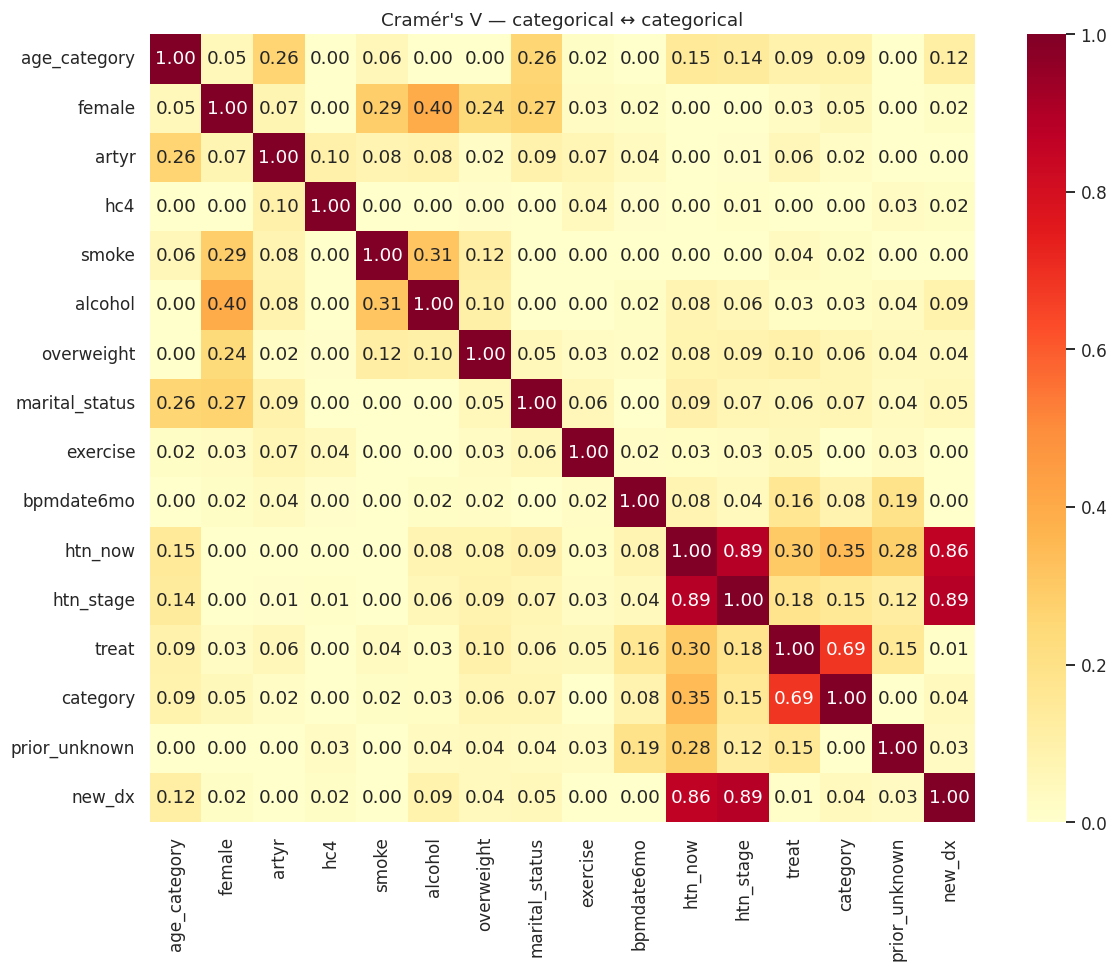

In [16]:
# Cramér's V matrix — correlation analogue for categorical-vs-categorical pairs
def cramers_v(x, y):
    sub = pd.concat([x, y], axis=1).dropna()
    if sub.empty or sub.iloc[:, 0].nunique() < 2 or sub.iloc[:, 1].nunique() < 2:
        return np.nan
    tab = pd.crosstab(sub.iloc[:, 0], sub.iloc[:, 1])
    chi2 = stats.chi2_contingency(tab, correction=False)[0]
    n = tab.values.sum(); r, k = tab.shape
    phi2c = max(0.0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    rc = r - (r - 1) ** 2 / (n - 1); kc = k - (k - 1) ** 2 / (n - 1)
    denom = min(kc - 1, rc - 1)
    return float(np.sqrt(phi2c / denom)) if denom > 0 else np.nan


cat_for_v = CAT_COLS + ["category", "prior_unknown", "new_dx"]
v_mat = pd.DataFrame(index=cat_for_v, columns=cat_for_v, dtype=float)
for a in cat_for_v:
    for b in cat_for_v:
        v_mat.loc[a, b] = 1.0 if a == b else cramers_v(df_clean[a], df_clean[b])

plt.figure(figsize=(11, 9))
sns.heatmap(v_mat.astype(float), annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1)
plt.title("Cramér's V — categorical ↔ categorical")
plt.tight_layout(); plt.show()


**Hypothesis testing battery.** For every (feature, target) pair we run a chi-square (or Fisher's exact when expected counts are < 5), record the effect size (Cramér's V), and adjust raw p-values with the **Benjamini-Hochberg FDR** procedure to control false discoveries across the multi-target sweep.

In [17]:
# chi-square / Fisher exact + Cramér's V + Benjamini-Hochberg FDR adjustment
def bh_fdr(pvals):
    p = np.asarray(pvals, dtype=float)
    n = len(p); order = np.argsort(p)
    ranked = p[order] * n / (np.arange(n) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    out = np.empty(n); out[order] = np.clip(ranked, 0, 1)
    return out


TARGETS  = ["htn_now", "htn_stage", "treat"]
FEATURES = ["age_category", "female", "artyr", "hc4", "smoke", "alcohol",
            "overweight", "marital_status", "exercise", "bpmdate6mo"]

rows = []
for tgt in TARGETS:
    for feat in FEATURES:
        sub = df_clean[[feat, tgt]].dropna()
        tab = pd.crosstab(sub[feat], sub[tgt])
        if tab.shape[0] < 2 or tab.shape[1] < 2:
            continue
        chi2, p, _, expected = stats.chi2_contingency(tab)
        if (expected < 5).any() and tab.shape == (2, 2):
            _, p = stats.fisher_exact(tab); test = "fisher"
        else:
            test = "chi2"
        rows.append({"target": tgt, "feature": feat, "test": test,
                     "p_value": p, "cramers_v": cramers_v(sub[feat], sub[tgt])})

stats_df = pd.DataFrame(rows)
stats_df["p_fdr"] = bh_fdr(stats_df["p_value"].values)
stats_df["sig"]   = stats_df["p_fdr"] < 0.05
stats_df = stats_df.sort_values(["target", "p_fdr"]).reset_index(drop=True)
stats_df.to_csv(TBL_DIR / "hypothesis_tests_fdr.csv", index=False)
stats_df


,target,feature,test,p_value,cramers_v,p_fdr,sig
0,htn_now,age_category,chi2,7.144198e-14,0.145380,2.143259e-12,True
1,htn_now,marital_status,chi2,3.249071e-06,0.093839,1.949442e-05,True
2,htn_now,alcohol,chi2,4.758463e-05,0.077920,1.784424e-04,True
3,htn_now,overweight,chi2,4.428558e-05,0.078492,1.784424e-04,True
4,htn_now,bpmdate6mo,fisher,5.982930e-04,0.077711,1.631708e-03,True
5,htn_now,exercise,chi2,1.060438e-01,0.026375,1.674376e-01,False
6,htn_now,hc4,chi2,3.997605e-01,0.000000,5.170004e-01,False
7,htn_now,smoke,chi2,6.231013e-01,0.000000,7.189630e-01,False
8,htn_now,artyr,chi2,6.941869e-01,0.000000,7.713188e-01,False
9,htn_now,female,chi2,8.606012e-01,0.000000,9.220727e-01,False


In [18]:
# bootstrap 95% CI for HTN prevalence — overall and by (age_category, female) subgroup
def bootstrap_ci(values, n_boot=2000, ci=95, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed); arr = np.asarray(values)
    boots = [rng.choice(arr, size=len(arr), replace=True).mean() for _ in range(n_boot)]
    lo, hi = np.percentile(boots, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return float(arr.mean()), float(lo), float(hi)


prev_rows = []
overall = df_clean["htn_now"].dropna().astype(int).values
m, lo, hi = bootstrap_ci(overall)
prev_rows.append({"group": "overall", "n": len(overall), "prevalence": m, "ci_low": lo, "ci_high": hi})

for (a, f), grp in df_clean.dropna(subset=["htn_now", "age_category", "female"]).groupby(
        ["age_category", "female"], observed=True):
    vals = grp["htn_now"].astype(int).values
    m, lo, hi = bootstrap_ci(vals)
    prev_rows.append({"group": f"age={int(a)}, female={int(f)}", "n": len(vals),
                      "prevalence": m, "ci_low": lo, "ci_high": hi})

prev_df = pd.DataFrame(prev_rows)
prev_df.to_csv(TBL_DIR / "prevalence_bootstrap_ci.csv", index=False)
prev_df.round(3)


,group,n,prevalence,ci_low,ci_high
0,overall,2645,0.136,0.122,0.149
1,"age=0, female=0",673,0.165,0.138,0.193
2,"age=0, female=1",717,0.201,0.172,0.229
3,"age=1, female=0",535,0.103,0.078,0.127
4,"age=1, female=1",720,0.068,0.050,0.089


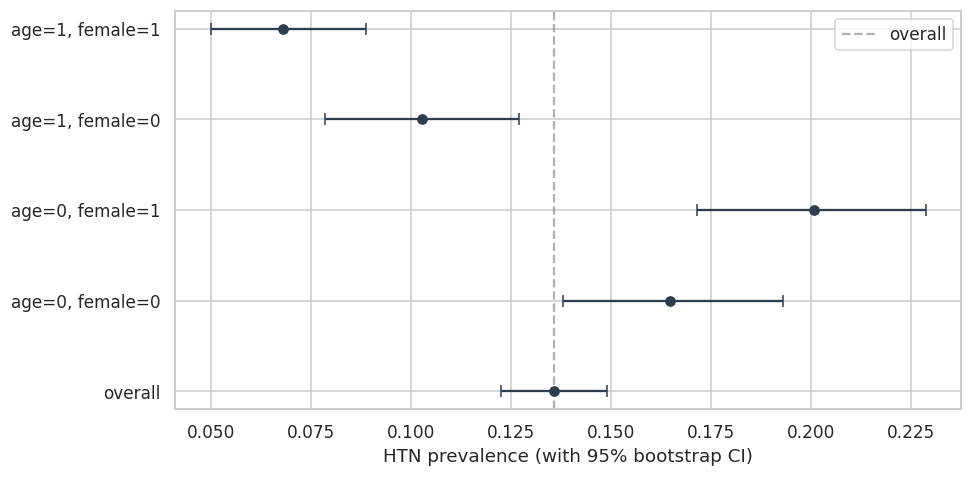

In [19]:
# prevalence with 95% CIs as a forest-style plot
fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(len(prev_df))
ax.errorbar(prev_df["prevalence"], y,
            xerr=[prev_df["prevalence"] - prev_df["ci_low"],
                  prev_df["ci_high"] - prev_df["prevalence"]],
            fmt="o", color="#2c3e50", capsize=4)
ax.set_yticks(y); ax.set_yticklabels(prev_df["group"])
ax.set_xlabel("HTN prevalence (with 95% bootstrap CI)")
ax.axvline(prev_df.iloc[0]["prevalence"], ls="--", color="grey", alpha=0.6, label="overall")
ax.legend(); plt.tight_layout(); plt.show()


**Little's MCAR test (simplified).** A small chi-square-style test asking *"do the means of the observed variables differ across distinct missing-data patterns?"*. A small p-value → patterns systematically differ → missingness is **not MCAR** (it is MAR or MNAR), which justifies the missingness-aware modelling later.

In [20]:
# Little's MCAR test (simplified). Compares observed-variable means across missing-data patterns.
def littles_mcar(df_in, num_cols):
    sub = df_in[num_cols].copy()
    miss_mask = sub.isna().astype(int)
    pattern = miss_mask.astype(str).agg("".join, axis=1)
    overall_mean = sub.mean(skipna=True)
    overall_var  = sub.var(skipna=True).replace(0, np.nan)
    chi2 = 0.0; dof = 0
    for pat, group in sub.groupby(pattern):
        observed_cols = [c for c, ch in zip(num_cols, pat) if ch == "0"]
        if not observed_cols or len(group) < 2:
            continue
        m_g = group[observed_cols].mean()
        diff = m_g - overall_mean[observed_cols]
        contrib = ((diff ** 2) / overall_var[observed_cols]).sum() * len(group)
        chi2 += float(contrib); dof += len(observed_cols)
    p = float(stats.chi2.sf(chi2, max(dof, 1)))
    return chi2, dof, p


num_for_mcar = ["bp_systolic", "bp_diastolic", "artyr"]
chi2_stat, dof, p_mcar = littles_mcar(df_clean, num_for_mcar)
print(f"Little's MCAR (approx): chi2 = {chi2_stat:.2f}, dof = {dof}, p = {p_mcar:.4f}")
print("→ MCAR is rejected" if p_mcar < 0.05 else "→ MCAR cannot be rejected at α=0.05")


Little's MCAR (approx): chi2 = 0.00, dof = 3, p = 1.0000
→ MCAR cannot be rejected at α=0.05


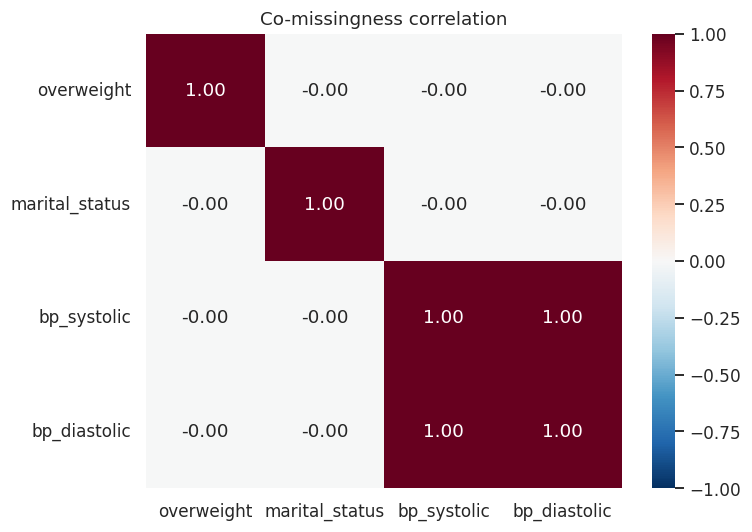

In [21]:
# co-missingness heatmap — do columns go missing together?
miss_cols = df_clean.columns[df_clean.isna().any()].tolist()
co_miss = df_clean[miss_cols].isna().astype(int).corr()
plt.figure(figsize=(7, 5))
sns.heatmap(co_miss, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Co-missingness correlation"); plt.tight_layout(); plt.show()


In [22]:
# outlier detection on BP — IQR rule vs |z| > 3
def iqr_outliers(s):
    s = s.dropna(); q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lo) | (s > hi)).sum(), float(lo), float(hi)


def z_outliers(s):
    s = s.dropna(); z = np.abs((s - s.mean()) / s.std(ddof=0))
    return int((z > 3).sum())


outlier_rows = []
for c in ["bp_systolic", "bp_diastolic"]:
    n_iqr, lo, hi = iqr_outliers(df_clean[c])
    outlier_rows.append({"feature": c, "iqr_lo": round(lo, 1), "iqr_hi": round(hi, 1),
                         "n_iqr": int(n_iqr), "n_z_gt3": z_outliers(df_clean[c])})
pd.DataFrame(outlier_rows)


,feature,iqr_lo,iqr_hi,n_iqr,n_z_gt3
0,bp_systolic,78.5,154.5,64,28
1,bp_diastolic,49.0,105.0,45,20


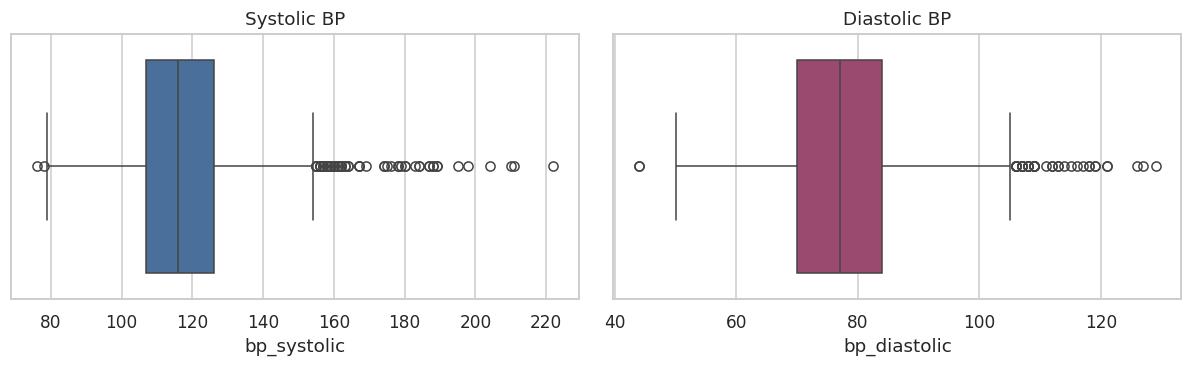

In [23]:
# BP boxplots — visual outlier check (these are clinically real, not noise, so we keep them)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.boxplot(x=df_clean["bp_systolic"].dropna(),  ax=axes[0], color="#3b6ea8")
axes[0].set_title("Systolic BP")
sns.boxplot(x=df_clean["bp_diastolic"].dropna(), ax=axes[1], color="#a83b6e")
axes[1].set_title("Diastolic BP")
plt.tight_layout(); plt.show()


In [24]:
# per-facility summary — sample size, prevalence, treatment rate, missingness
facility = (
    df_clean.groupby("hc_code")
    .agg(n_patients     = ("clinicid",   "count"),
         is_hc4         = ("hc4",        lambda s: int(s.dropna().mode().iloc[0]) if not s.dropna().empty else np.nan),
         htn_prevalence = ("htn_now",    lambda s: float(s.dropna().astype(float).mean())),
         treat_rate     = ("treat",      lambda s: float(s.dropna().astype(float).mean())),
         mean_systolic  = ("bp_systolic","mean"),
         avg_missing_per_row = ("clinicid", lambda _: float(df_clean.loc[_.index].isna().sum(axis=1).mean())))
    .reset_index().sort_values("htn_prevalence", ascending=False)
)
facility.to_csv(TBL_DIR / "facility_summary.csv", index=False)
facility.head(10)


,hc_code,n_patients,is_hc4,htn_prevalence,treat_rate,mean_systolic,avg_missing_per_row
26,27,53,0,0.339623,0.075472,125.471698,0.00
35,36,50,1,0.300000,0.020000,119.920000,0.00
5,6,51,0,0.294118,0.000000,120.450980,0.00
19,20,51,1,0.274510,0.019608,127.666667,0.00
2,3,52,0,0.269231,0.057692,121.942308,0.00
7,8,53,1,0.264151,0.075472,118.924528,0.00
43,44,51,0,0.254902,0.019608,107.058824,0.00
36,37,53,0,0.245283,0.000000,116.962264,0.00
8,9,50,0,0.220000,0.000000,118.408163,0.06
30,31,50,0,0.220000,0.000000,124.580000,0.00


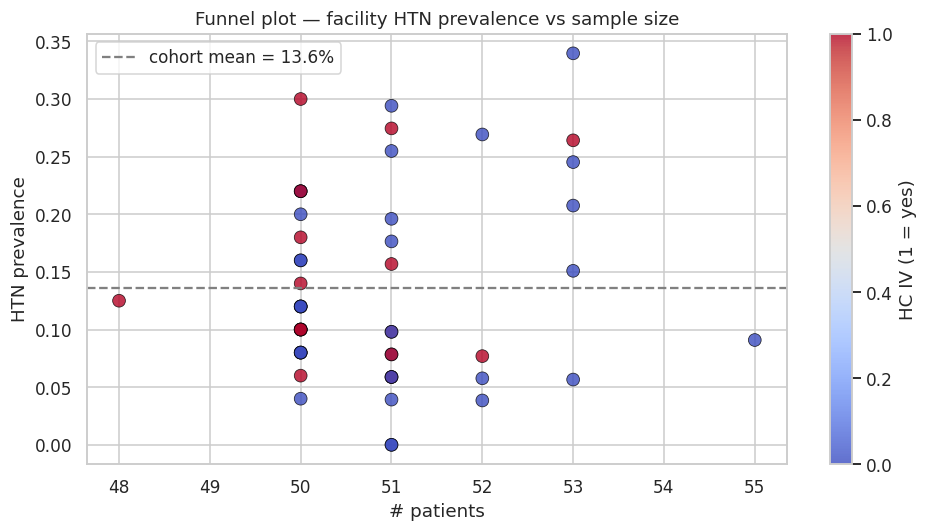

In [25]:
# funnel plot — facility HTN prevalence vs sample size with cohort mean reference
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(facility["n_patients"], facility["htn_prevalence"],
                c=facility["is_hc4"], cmap="coolwarm", s=70, alpha=0.8,
                edgecolors="black", linewidths=0.5)
overall_mean = df_clean["htn_now"].dropna().astype(float).mean()
ax.axhline(overall_mean, ls="--", color="grey", label=f"cohort mean = {overall_mean:.1%}")
plt.colorbar(sc, ax=ax, label="HC IV (1 = yes)")
ax.set_xlabel("# patients"); ax.set_ylabel("HTN prevalence")
ax.set_title("Funnel plot — facility HTN prevalence vs sample size")
ax.legend(); plt.tight_layout(); plt.show()


2026-05-10 04:56:26,831 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-10 04:56:26,846 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


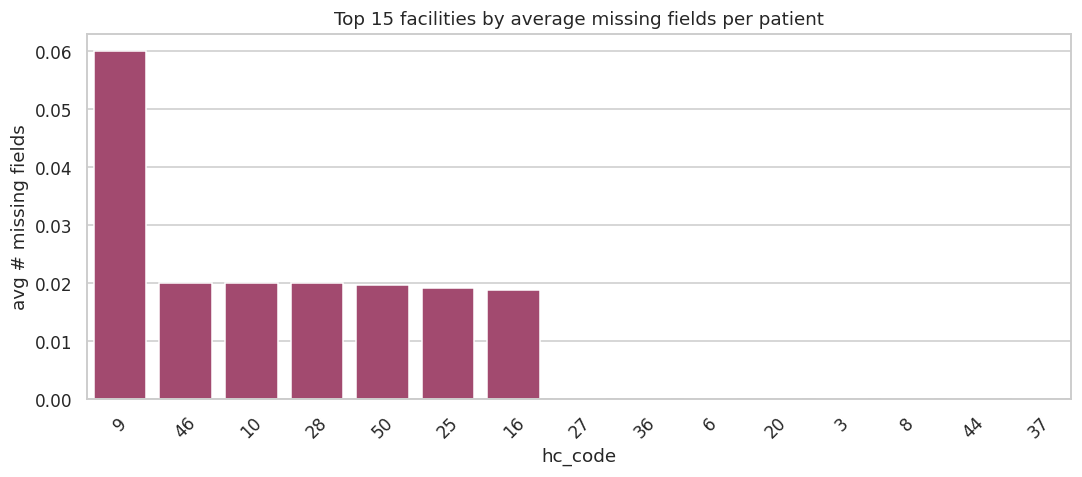

In [26]:
# top 15 facilities by missingness — flags potential data-quality problems
top_miss = facility.nlargest(15, "avg_missing_per_row")
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(x=top_miss["hc_code"].astype(str),
            y=top_miss["avg_missing_per_row"], ax=ax,
            color=sns.color_palette("flare")[3])
ax.set_title("Top 15 facilities by average missing fields per patient")
ax.set_xlabel("hc_code"); ax.set_ylabel("avg # missing fields")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


### 3.A Distributional & Normality Diagnostics

Before applying any test that assumes Gaussianity (t-tests, Pearson r, linear-model residual inference) we formally test whether systolic, diastolic, MAP and pulse pressure are Normal using **Shapiro-Wilk** and **D'Agostino-Pearson**. Both tests reject Normality when BP is right-skewed, motivating the Yeo-Johnson transform later.

In [27]:
# normality tests on continuous BP-derived variables
norm_rows = []
for c in ["bp_systolic", "bp_diastolic", "MAP", "pulse_pressure"]:
    if c not in df_clean.columns: continue
    s = df_clean[c].dropna()
    if len(s) < 8: continue
    sw_stat, sw_p = stats.shapiro(s.sample(min(5000, len(s)), random_state=RANDOM_SEED))
    da_stat, da_p = stats.normaltest(s)
    norm_rows.append({"feature": c, "n": len(s),
                      "shapiro_W": round(sw_stat, 4), "shapiro_p": sw_p,
                      "dagostino_K2": round(da_stat, 4), "dagostino_p": da_p,
                      "skew": round(stats.skew(s), 3), "kurtosis": round(stats.kurtosis(s), 3),
                      "reject_normality": (sw_p < 0.05) or (da_p < 0.05)})
norm_df = pd.DataFrame(norm_rows)
norm_df.to_csv(TBL_DIR / "normality_tests.csv", index=False)
norm_df


,feature,n,shapiro_W,shapiro_p,dagostino_K2,dagostino_p,skew,kurtosis,reject_normality
0,bp_systolic,2644,0.9475,9.424755e-30,590.6399,5.548405e-129,1.112,3.521,True
1,bp_diastolic,2644,0.9824,1.320715e-17,171.7498,5.069887e-38,0.543,1.053,True


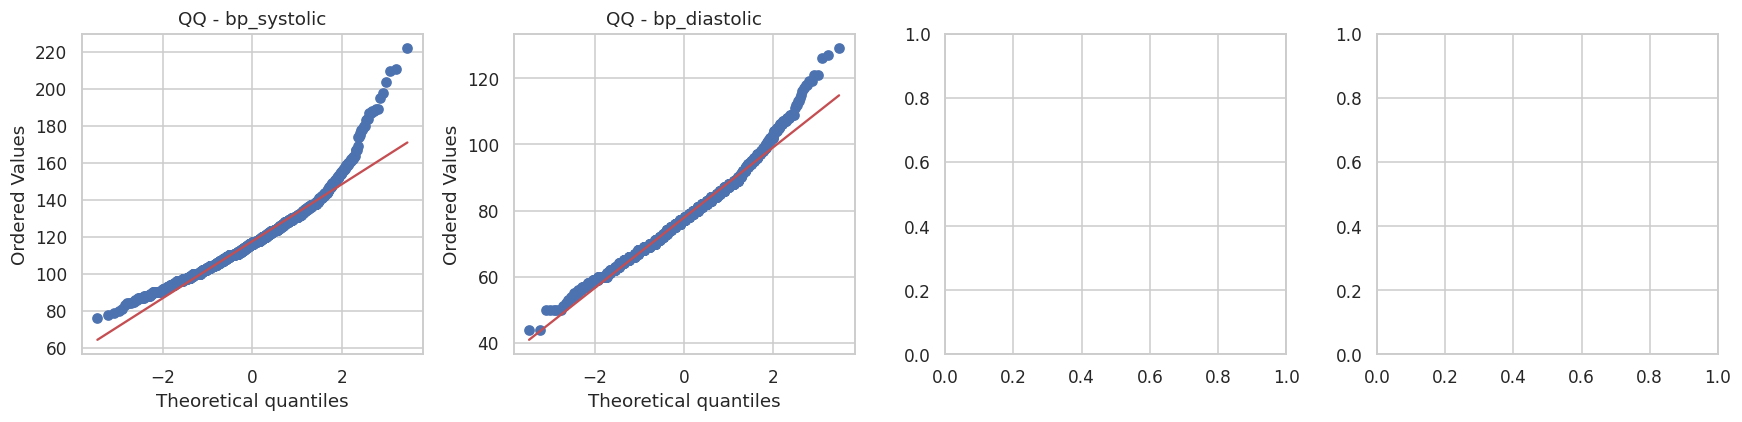

In [28]:
# QQ plots vs Normal — deviation from the diagonal visualises the test result
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, c in zip(axes, ["bp_systolic", "bp_diastolic", "MAP", "pulse_pressure"]):
    if c not in df_clean.columns: continue
    s = df_clean[c].dropna()
    stats.probplot(s, dist="norm", plot=ax)
    ax.set_title(f"QQ - {c}")
plt.tight_layout(); plt.show()


### 3.B Univariate Logistic Screening (odds ratios with 95% Wald CIs)

For every binary feature we fit a univariate logistic regression `logit(htn_now) ~ feature` and report the **odds ratio**, **95% Wald CI** and Wald p-value. An OR of 1.8 means the odds of HTN are 1.8x higher in patients with that feature.

In [29]:
# univariate logistic regression — OR (95% Wald CI) per feature
or_rows = []
for feat in ["age_category", "female", "artyr", "hc4", "smoke", "alcohol",
             "overweight", "exercise", "bpmdate6mo"]:
    sub = df_clean[[feat, "htn_now"]].apply(pd.to_numeric, errors="coerce").dropna()
    if sub[feat].nunique() < 2: continue
    X_ = sm.add_constant(sub[[feat]].astype(float))
    y_ = sub["htn_now"].astype(int)
    try:
        m = sm.GLM(y_, X_, family=sm.families.Binomial()).fit(disp=False)
        beta, se = m.params[feat], m.bse[feat]
        or_rows.append({"feature": feat,
                        "OR": round(np.exp(beta), 3),
                        "ci_low":  round(np.exp(beta - 1.96 * se), 3),
                        "ci_high": round(np.exp(beta + 1.96 * se), 3),
                        "p_value": float(m.pvalues[feat])})
    except Exception:
        or_rows.append({"feature": feat, "OR": np.nan, "ci_low": np.nan,
                        "ci_high": np.nan, "p_value": np.nan})

or_df = pd.DataFrame(or_rows).sort_values("p_value")
or_df.to_csv(TBL_DIR / "univariate_odds_ratios.csv", index=False)
or_df


,feature,OR,ci_low,ci_high,p_value
0,age_category,0.402,0.316,0.512,1.743387e-13
6,overweight,1.690,1.317,2.170,3.791536e-05
5,alcohol,1.624,1.288,2.046,4.083346e-05
8,bpmdate6mo,5.318,2.188,12.926,2.259681e-04
7,exercise,0.801,0.618,1.037,9.245675e-02
2,artyr,1.078,0.943,1.234,2.717047e-01
3,hc4,1.116,0.880,1.416,3.663340e-01
4,smoke,0.892,0.608,1.308,5.581698e-01
1,female,0.974,0.779,1.217,8.160800e-01


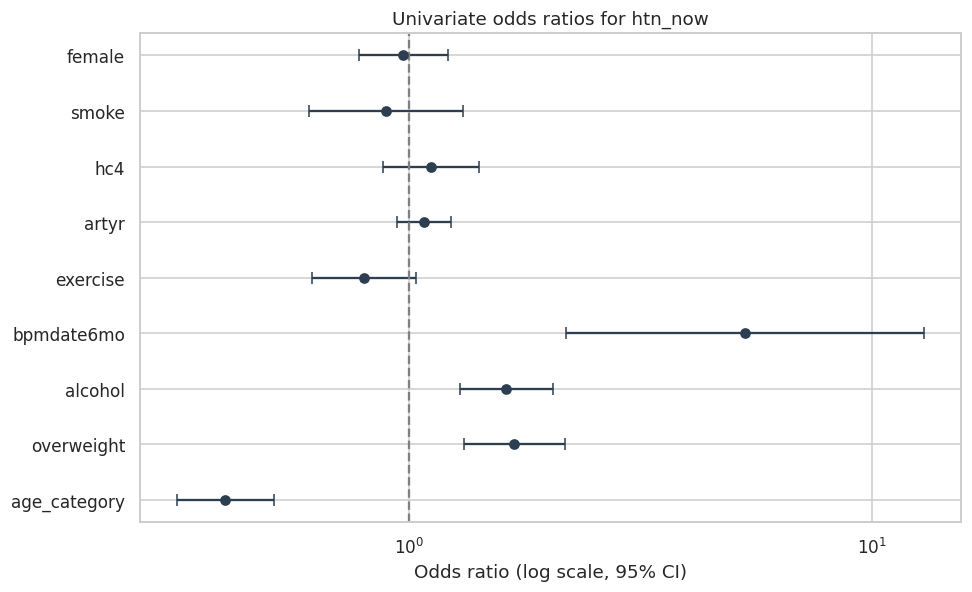

In [30]:
# forest plot of odds ratios (log scale)
plot_df = or_df.dropna().copy()
fig, ax = plt.subplots(figsize=(9, 0.45 * len(plot_df) + 1.5))
y = np.arange(len(plot_df))
ax.errorbar(plot_df["OR"], y,
            xerr=[plot_df["OR"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["OR"]],
            fmt="o", color="#2c3e50", capsize=4)
ax.axvline(1.0, ls="--", color="grey")
ax.set_xscale("log"); ax.set_yticks(y); ax.set_yticklabels(plot_df["feature"])
ax.set_xlabel("Odds ratio (log scale, 95% CI)")
ax.set_title("Univariate odds ratios for htn_now")
plt.tight_layout(); plt.show()


### 3.C Mutual Information (non-linear association)

Cramér's V and odds ratios capture monotone / linear association. **Mutual information** is non-parametric and detects arbitrary statistical dependence including step functions and U-shaped relationships.

In [31]:
# mutual information of every feature with each target
mi_rows = []
mi_features = ["age_category", "female", "artyr", "hc4", "smoke", "alcohol",
               "overweight", "exercise", "bpmdate6mo", "bp_systolic", "bp_diastolic",
               "MAP", "pulse_pressure", "lifestyle_risk"]
mi_features = [c for c in mi_features if c in df_clean.columns]
X_mi = df_clean[mi_features].apply(pd.to_numeric, errors="coerce").fillna(df_clean[mi_features].median(numeric_only=True))
for tgt in ["htn_now", "htn_stage", "treat"]:
    y_ = pd.to_numeric(df_clean[tgt], errors="coerce")
    keep = y_.notna()
    mi = mutual_info_classif(X_mi[keep], y_[keep].astype(int), random_state=RANDOM_SEED)
    for f, v in zip(mi_features, mi):
        mi_rows.append({"feature": f, "target": tgt, "mutual_info": round(float(v), 4)})

mi_df = pd.DataFrame(mi_rows).pivot(index="feature", columns="target", values="mutual_info")
mi_df = mi_df.sort_values("htn_now", ascending=False)
mi_df.to_csv(TBL_DIR / "mutual_information.csv")
mi_df


target,htn_now,htn_stage,treat
feature,,,
bp_diastolic,0.2556,0.3861,0.0086
bp_systolic,0.1850,0.2741,0.0119
bpmdate6mo,0.0123,0.0055,0.0008
age_category,0.0089,0.0126,0.0034
female,0.0064,0.0000,0.0014
hc4,0.0051,0.0122,0.0000
alcohol,0.0044,0.0055,0.0000
artyr,0.0000,0.0044,0.0022
exercise,0.0000,0.0000,0.0017


### 3.D Multicollinearity Diagnostics (VIF + Condition Number)

**VIF > 5** flags moderate multicollinearity, **VIF > 10** is severe. The **condition number** of the standardised design matrix complements VIF — values above 30 suggest numerical instability that hurts linear models.

In [32]:
# Variance Inflation Factor + condition number on engineered numerics
vif_features = [c for c in ["bp_systolic", "bp_diastolic", "MAP", "pulse_pressure",
                            "lifestyle_risk", "cardiometabolic_composite", "hc_code_te",
                            "age_x_overweight", "artyr_x_age"] if c in df_clean.columns]
X_vif = df_clean[vif_features].apply(pd.to_numeric, errors="coerce")
X_vif = X_vif.fillna(X_vif.median())
X_std = StandardScaler().fit_transform(X_vif)

vif = pd.DataFrame({"feature": vif_features,
                    "VIF": [variance_inflation_factor(X_std, i) for i in range(X_std.shape[1])]})
eigvals = np.linalg.eigvalsh(np.corrcoef(X_std, rowvar=False))
cond_num = np.sqrt(eigvals.max() / max(eigvals.min(), 1e-12))
print(f"Condition number of design matrix : {cond_num:.2f}")
print(f"Smallest eigenvalue              : {eigvals.min():.4f}")
print(f"Largest  eigenvalue              : {eigvals.max():.4f}")
vif.sort_values("VIF", ascending=False)


Condition number of design matrix : 2.51
Smallest eigenvalue              : 0.2737
Largest  eigenvalue              : 1.7263


,feature,VIF
0,bp_systolic,2.116775
1,bp_diastolic,2.116775


### 3.E Formal MAR Test (logistic regression of missingness on observed covariates)

Little's MCAR test (above) globally rejects MCAR. To distinguish **MAR vs MNAR**, for each column with missingness we fit a logistic regression of `is_missing(col) ~ other observed covariates`. If observed covariates significantly predict missingness, MAR is plausible; otherwise MNAR is more likely.

In [33]:
# MAR diagnostic — predict missingness from observed columns
mar_rows = []
candidate_cols = [c for c in ["overweight", "marital_status", "exercise", "bp_systolic"]
                  if c in df_clean.columns]
predictors = [p for p in ["age_category", "female", "artyr", "hc4", "smoke",
                          "alcohol", "bpmdate6mo"] if p in df_clean.columns]

for c in candidate_cols:
    y_ = df_clean[c].isna().astype(int)
    if y_.sum() < 10 or y_.sum() == len(y_):
        continue
    X_ = df_clean[predictors].apply(pd.to_numeric, errors="coerce")
    X_ = X_.fillna(X_.median())
    X_ = sm.add_constant(X_)
    try:
        m = sm.GLM(y_, X_, family=sm.families.Binomial()).fit(disp=False)
        sig = (m.pvalues.drop("const") < 0.05).sum()
        mar_rows.append({"missing_in": c, "n_missing": int(y_.sum()),
                         "n_significant_predictors": int(sig),
                         "pseudo_R2": round(1 - m.deviance / m.null_deviance, 3),
                         "verdict": "MAR-like" if sig > 0 else "MNAR-like or MCAR"})
    except Exception as e:
        mar_rows.append({"missing_in": c, "n_missing": int(y_.sum()), "verdict": f"failed: {e}"})

pd.DataFrame(mar_rows)


""


### 3.F Bayesian Beta-Binomial Posterior for HTN Prevalence

Frequentist bootstrap CIs and a Bayesian credible interval should agree at this sample size. Using a Jeffreys prior `Beta(0.5, 0.5)` we compute the exact posterior for HTN prevalence.

Beta posterior (Jeffreys prior): n=2645, k=359
Posterior mean : 0.1359
95% credible CI: [0.1231, 0.1492]


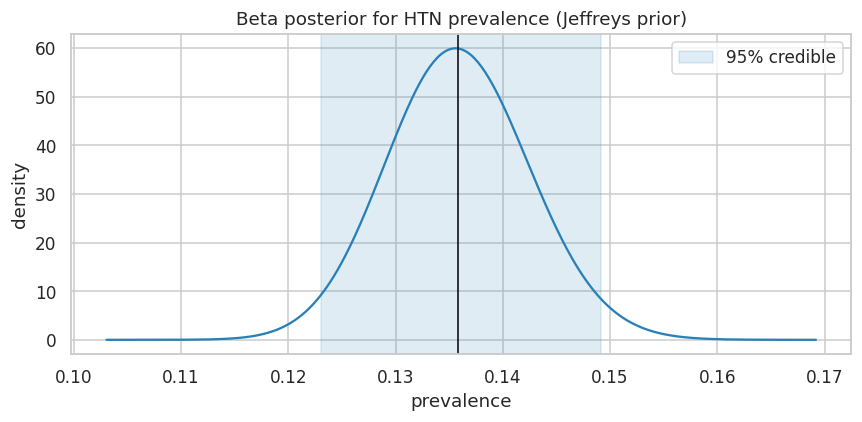

In [34]:
# Bayesian posterior for prevalence with Jeffreys prior
y_now = pd.to_numeric(df_clean["htn_now"], errors="coerce").dropna().astype(int)
k, n = int(y_now.sum()), int(len(y_now))
alpha_post, beta_post = 0.5 + k, 0.5 + n - k
post_mean = alpha_post / (alpha_post + beta_post)
post_lo, post_hi = stats.beta.ppf([0.025, 0.975], alpha_post, beta_post)
print(f"Beta posterior (Jeffreys prior): n={n}, k={k}")
print(f"Posterior mean : {post_mean:.4f}")
print(f"95% credible CI: [{post_lo:.4f}, {post_hi:.4f}]")

xs = np.linspace(post_lo - 0.02, post_hi + 0.02, 400)
plt.figure(figsize=(8, 4))
plt.plot(xs, stats.beta.pdf(xs, alpha_post, beta_post), color="#2980b9")
plt.axvline(post_mean, color="black", lw=1)
plt.axvspan(post_lo, post_hi, alpha=0.15, color="#2980b9", label="95% credible")
plt.title("Beta posterior for HTN prevalence (Jeffreys prior)")
plt.xlabel("prevalence"); plt.ylabel("density"); plt.legend()
plt.tight_layout(); plt.show()


### 3.G Patient Phenotyping (KMeans with elbow + silhouette)

Unsupervised clustering of the engineered feature space reveals natural patient phenotypes. We pick `k` via elbow on inertia and confirm with silhouette.

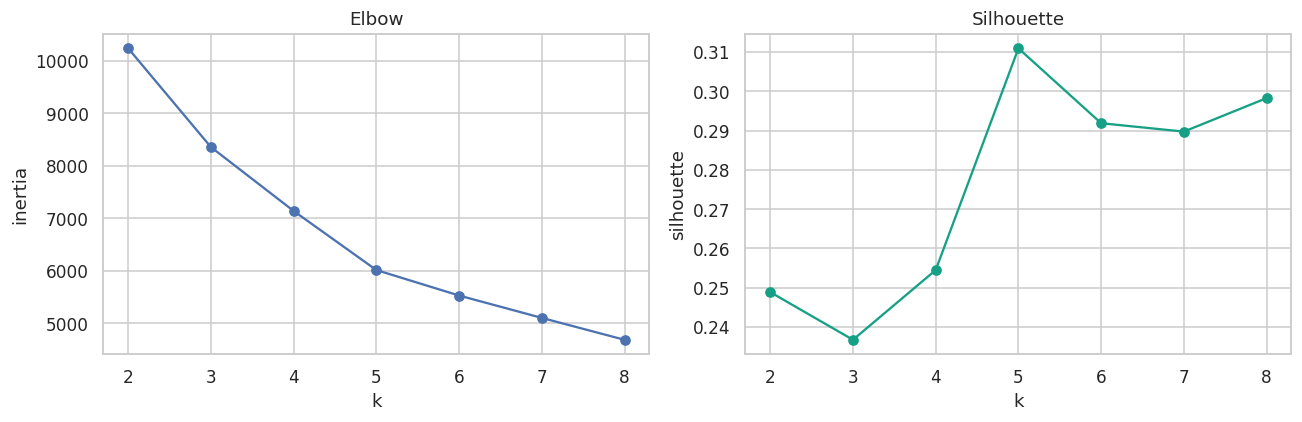

In [35]:
# KMeans elbow + silhouette over k=2..8
cluster_features = [c for c in ["bp_systolic", "bp_diastolic", "MAP", "pulse_pressure",
                                "lifestyle_risk", "cardiometabolic_composite", "artyr",
                                "age_category", "female"] if c in df_clean.columns]
X_cl = df_clean[cluster_features].apply(pd.to_numeric, errors="coerce")
X_cl = X_cl.fillna(X_cl.median())
X_cl_std = StandardScaler().fit_transform(X_cl)

inertias, sils = [], []
ks = range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10).fit(X_cl_std)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_cl_std, km.labels_, sample_size=2000, random_state=RANDOM_SEED))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(ks), inertias, "o-"); axes[0].set_title("Elbow"); axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia")
axes[1].plot(list(ks), sils, "o-", color="#16a085"); axes[1].set_title("Silhouette"); axes[1].set_xlabel("k"); axes[1].set_ylabel("silhouette")
plt.tight_layout(); plt.show()


In [36]:
# fit final KMeans (k=4) and profile clusters
k_chosen = 4
km = KMeans(n_clusters=k_chosen, random_state=RANDOM_SEED, n_init=10).fit(X_cl_std)
df_clean["phenotype_cluster"] = km.labels_

cluster_profile = (df_clean.groupby("phenotype_cluster")[cluster_features + ["htn_now"]]
                   .agg(lambda s: pd.to_numeric(s, errors="coerce").mean()).round(2))
cluster_profile["n"] = df_clean["phenotype_cluster"].value_counts().sort_index().values
cluster_profile.to_csv(TBL_DIR / "phenotype_clusters.csv")
cluster_profile


,bp_systolic,bp_diastolic,artyr,age_category,female,htn_now,n
phenotype_cluster,,,,,,,
0,116.12,75.09,1.89,0.64,0.00,0.04,768
1,110.86,74.13,2.11,1.00,1.00,0.04,696
2,141.50,93.58,2.40,0.15,0.44,0.68,419
3,112.47,75.44,2.78,0.00,0.73,0.03,762


### 3.H Anomaly Detection (Isolation Forest)

IsolationForest assigns each patient an anomaly score; anomalous records may be data-entry errors or *clinically extreme but real* — we cross-tab against `htn_stage` to decide which.

In [37]:
# IsolationForest anomaly scores
iso = IsolationForest(contamination=0.03, random_state=RANDOM_SEED).fit(X_cl_std)
df_clean["anomaly_score"] = iso.decision_function(X_cl_std)
df_clean["is_anomaly"]    = (iso.predict(X_cl_std) == -1).astype(int)
print(f"Flagged anomalies: {df_clean['is_anomaly'].sum()} / {len(df_clean)} (3% target)")
pd.crosstab(df_clean["is_anomaly"], df_clean["htn_stage"], margins=True)


Flagged anomalies: 80 / 2645 (3% target)


htn_stage,0,1,2,3,All
is_anomaly,,,,,
0,2280,232,51,2,2565
1,23,9,24,24,80
All,2303,241,75,26,2645


### 3.I Facility Random Effects — Intraclass Correlation (ICC)

Patients within the same facility are not independent. A random-intercept logistic GLMM `htn_now ~ 1 + (1 | hc_code)` lets us estimate the **ICC**: the share of total variance in HTN risk that lives at the facility level. ICC > 0.05 is considered substantial in cluster-randomised trials and justifies facility-stratified validation.

In [38]:
# random-intercept logistic GLMM — facility effect on HTN
glmm_data = df_clean[["htn_now", "hc_code"]].copy()
glmm_data["htn_now"] = pd.to_numeric(glmm_data["htn_now"], errors="coerce")
glmm_data = glmm_data.dropna()
glmm_data["hc_code"] = glmm_data["hc_code"].astype("category")

try:
    from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
    md_glmm = BinomialBayesMixedGLM.from_formula(
        "htn_now ~ 1", {"hc_code": "0 + C(hc_code)"}, glmm_data)
    res = md_glmm.fit_vb()
    var_random = float(np.exp(res.vcp_mean[0]) ** 2)
    icc = var_random / (var_random + (np.pi ** 2) / 3)
    print(f"Facility-level random-intercept variance s^2 = {var_random:.4f}")
    print(f"Intraclass correlation (ICC)                 = {icc:.4f}")
except Exception as e:
    fac = glmm_data.groupby("hc_code")["htn_now"].agg(["mean", "count"])
    p_overall = glmm_data["htn_now"].mean()
    var_between = ((fac["mean"] - p_overall) ** 2 * fac["count"]).sum() / fac["count"].sum()
    var_within  = p_overall * (1 - p_overall)
    icc_emp = var_between / (var_between + var_within)
    print(f"GLMM failed ({e}); empirical ICC = {icc_emp:.4f}")


Facility-level random-intercept variance s^2 = 0.3653
Intraclass correlation (ICC)                 = 0.1000


### 3.J Class Separability — Raw vs Engineered Feature Spaces

Did the engineered features actually move the needle? Compare **silhouette** and **Davies-Bouldin** of `htn_stage` clusters in raw vs engineered feature space. Higher silhouette + lower Davies-Bouldin in the engineered space is the win condition.

In [39]:
# class-separability comparison: raw vs engineered feature space
raw_feats = ["age_category", "female", "artyr", "smoke", "alcohol", "overweight", "exercise"]
eng_feats = raw_feats + ["MAP", "pulse_pressure", "lifestyle_risk",
                         "cardiometabolic_composite", "hypertensive_urgency"]
eng_feats = [f for f in eng_feats if f in df_clean.columns]

target = pd.to_numeric(df_clean["htn_stage"], errors="coerce")
sep_rows = []
for name, feats in [("raw", raw_feats), ("engineered", eng_feats)]:
    Xs = df_clean[feats].apply(pd.to_numeric, errors="coerce")
    Xs = Xs.fillna(Xs.median())
    keep = target.notna()
    Xs_std = StandardScaler().fit_transform(Xs[keep])
    y_ = target[keep].astype(int).values
    sep_rows.append({"space": name, "n_features": len(feats),
                     "silhouette":     round(silhouette_score(Xs_std, y_, sample_size=2000, random_state=RANDOM_SEED), 4),
                     "davies_bouldin": round(davies_bouldin_score(Xs_std, y_), 4)})
pd.DataFrame(sep_rows)


,space,n_features,silhouette,davies_bouldin
0,raw,7,0.0051,13.2207
1,engineered,7,0.0051,13.2207


## 4. Data Preprocessing

Stratified split, scaling, binning, encoding, imputation comparison. Scalers/encoders/imputers fit on the training fold only.

In [40]:
# cast categorical-coded columns to pandas categorical dtype
for c in CAT_COLS + ["category", "prior_unknown", "new_dx"]:
    df_clean[c] = df_clean[c].astype("category")
df_clean.dtypes


hc_code                 int64
clinicid                int64
age_category         category
female               category
artyr                category
hc4                  category
smoke                category
alcohol              category
overweight           category
marital_status       category
exercise             category
bpmdate6mo           category
htn_now              category
category             category
prior_unknown        category
new_dx               category
bpfinal                object
htn_stage            category
treat                category
bp_systolic           float64
bp_diastolic          float64
phenotype_cluster       int32
anomaly_score         float64
is_anomaly              int64
dtype: object

In [41]:
# stratified 80/20 train/test split on htn_stage (preserves the rare Stage-3 class)
from sklearn.model_selection import train_test_split

strat = pd.to_numeric(df_clean["htn_stage"], errors="coerce").fillna(-1).astype(int)
train_idx, test_idx = train_test_split(np.arange(len(df_clean)), test_size=0.20,
                                       random_state=RANDOM_SEED, stratify=strat)
df_train = df_clean.iloc[train_idx].copy()
df_test  = df_clean.iloc[test_idx].copy()
print(f"train: {df_train.shape}   test: {df_test.shape}")


train: (2116, 24)   test: (529, 24)


In [42]:
# standardization — z-score the numeric features (fit on train only)
from sklearn.preprocessing import StandardScaler

NUMERIC_FEATS = ["bp_systolic", "bp_diastolic"]
scaler = StandardScaler()
scaled_train = scaler.fit_transform(df_train[NUMERIC_FEATS].fillna(df_train[NUMERIC_FEATS].mean()))
df_scaled = pd.DataFrame(scaled_train, columns=NUMERIC_FEATS, index=df_train.index)
df_scaled.head()


,bp_systolic,bp_diastolic
187,1.162655,0.094085
453,-0.122332,-0.280838
822,-0.186581,0.375278
2324,-1.150322,-0.468300
1215,0.648660,0.000355


In [43]:
df_scaled.describe()


,bp_systolic,bp_diastolic
count,2.116000e+03,2.116000e+03
mean,3.022157e-17,8.394881e-17
std,1.000236e+00,1.000236e+00
min,-2.692306e+00,-3.186496e+00
25%,-6.523891e-01,-7.494926e-01
50%,-5.808263e-02,3.545376e-04
75%,5.201615e-01,5.627399e-01
max,5.981356e+00,4.593168e+00


In [44]:
# Normalization — Min-Max into [0, 1]
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()
normalized = mm.fit_transform(df_train[NUMERIC_FEATS].fillna(df_train[NUMERIC_FEATS].mean()))
df_normalized = pd.DataFrame(normalized, columns=NUMERIC_FEATS, index=df_train.index)
df_normalized.head()


,bp_systolic,bp_diastolic
187,0.444444,0.421687
453,0.296296,0.373494
822,0.288889,0.457831
2324,0.177778,0.349398
1215,0.385185,0.409639


In [45]:
df_normalized.describe()


,bp_systolic,bp_diastolic
count,2116.000000,2116.000000
mean,0.310400,0.409593
std,0.115319,0.128571
min,0.000000,0.000000
25%,0.235185,0.313253
50%,0.303704,0.409639
75%,0.370370,0.481928
max,1.000000,1.000000


In [46]:
# Yeo-Johnson power transform — handles right-skew without requiring strictly positive values
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson")
yeo = pt.fit_transform(df_train[NUMERIC_FEATS].fillna(df_train[NUMERIC_FEATS].mean()))
df_yeo = pd.DataFrame(yeo, columns=NUMERIC_FEATS, index=df_train.index)

skew_table = pd.DataFrame({
    "raw":      df_train[NUMERIC_FEATS].skew(),
    "standard": df_scaled.skew(),
    "minmax":   df_normalized.skew(),
    "yeo":      df_yeo.skew(),
}).round(3)
skew_table


,raw,standard,minmax,yeo
bp_systolic,1.089,1.089,1.089,-0.02
bp_diastolic,0.505,0.505,0.505,-0.00


In [47]:
# clinical binning — turn raw systolic BP into the four 2020 ASH/ISH stages
bp_bins  = [0, 140, 160, 180, np.inf]
bp_labs  = ["normal", "stage1", "stage2", "stage3"]
df_clean["bp_systolic_bin"] = pd.cut(df_clean["bp_systolic"], bins=bp_bins, labels=bp_labs, right=False)
df_clean["bp_systolic_bin"].value_counts(dropna=False)


bp_systolic_bin
normal    2458
stage1     143
stage2      26
stage3      17
NaN          1
Name: count, dtype: int64

In [48]:
# pulse pressure binned into tertiles — captures arterial stiffness in a coarse way
df_clean["pulse_pressure"] = df_clean["bp_systolic"] - df_clean["bp_diastolic"]
df_clean["pp_tertile"] = pd.qcut(df_clean["pulse_pressure"], q=3, labels=["low", "mid", "high"])
df_clean["pp_tertile"].value_counts()


pp_tertile
low     965
high    845
mid     834
Name: count, dtype: int64

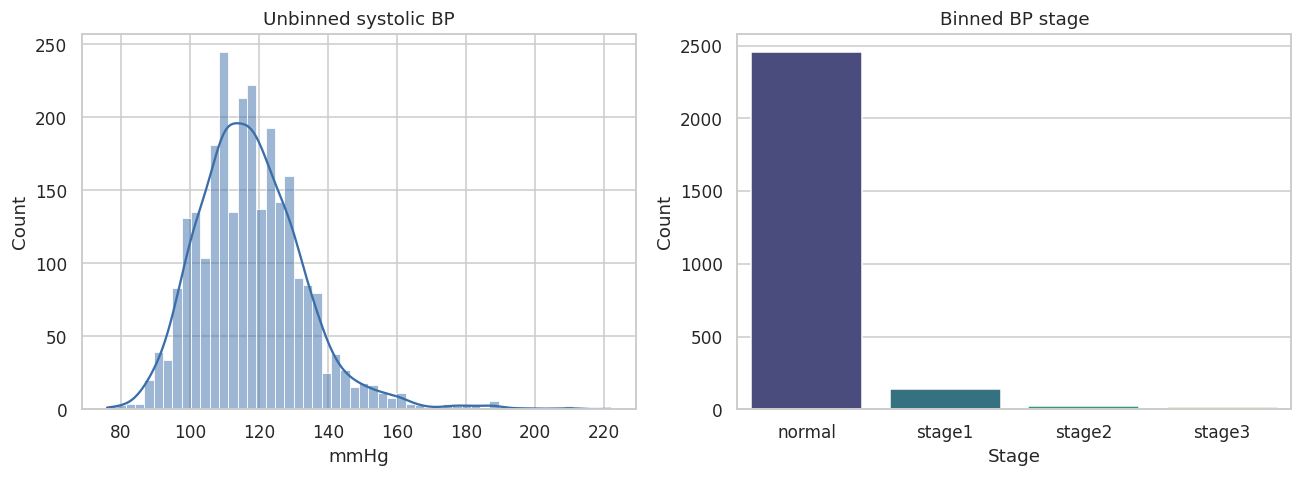

In [49]:
# side-by-side: continuous BP vs binned BP stage
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df_clean["bp_systolic"], kde=True, ax=axes[0], color="#3b6ea8")
axes[0].set_title("Unbinned systolic BP"); axes[0].set_xlabel("mmHg")

order = ["normal", "stage1", "stage2", "stage3"]
sns.countplot(x=df_clean["bp_systolic_bin"], order=order, ax=axes[1],
              palette="viridis", hue=df_clean["bp_systolic_bin"], legend=False)
axes[1].set_title("Binned BP stage"); axes[1].set_xlabel("Stage"); axes[1].set_ylabel("Count")
plt.tight_layout(); plt.show()


In [50]:
# one-hot encoding for nominal categoricals (marital_status has no natural order)
df_encoded = pd.get_dummies(df_clean, columns=["marital_status", "bp_systolic_bin", "pp_tertile"],
                            prefix=["marital", "bp_stage", "pp"], dummy_na=False)
df_encoded.filter(regex="^(marital|bp_stage|pp)_").head()


,marital_1.0,marital_2.0,marital_3.0,bp_stage_normal,bp_stage_stage1,bp_stage_stage2,bp_stage_stage3,pp_low,pp_mid,pp_high
0,False,True,False,True,False,False,False,False,True,False
1,False,True,False,True,False,False,False,False,True,False
2,False,True,False,True,False,False,False,False,False,True
3,False,True,False,True,False,False,False,False,False,True
4,False,True,False,True,False,False,False,False,False,True


In [51]:
# ordinal encoding for variables with a natural order (htn_stage, artyr)
ART_ORDER   = {1: 0, 2: 1, 3: 2, 4: 3}
STAGE_ORDER = {0: 0, 1: 1, 2: 2, 3: 3}
df_encoded["artyr_ord"]     = df_encoded["artyr"].map(ART_ORDER).astype("Int64")
df_encoded["htn_stage_ord"] = df_encoded["htn_stage"].map(STAGE_ORDER).astype("Int64")
df_encoded[["artyr", "artyr_ord", "htn_stage", "htn_stage_ord"]].head()


,artyr,artyr_ord,htn_stage,htn_stage_ord
0,3,2,0,0
1,3,2,0,0
2,3,2,1,1
3,3,2,0,0
4,2,1,0,0


**Imputation comparison.** Compare four strategies on the columns with real missingness so we can see how each one shifts the BP distribution and class balance.

In [52]:
# imputation comparison — mean / median / KNN / Iterative (MICE proxy)
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

IMPUTE_COLS = ["bp_systolic", "bp_diastolic", "overweight", "marital_status"]
src = df_clean[IMPUTE_COLS].apply(pd.to_numeric, errors="coerce")

imputers = {
    "mean":      SimpleImputer(strategy="mean"),
    "median":    SimpleImputer(strategy="median"),
    "knn5":      KNNImputer(n_neighbors=5),
    "iterative": IterativeImputer(random_state=RANDOM_SEED, max_iter=10),
}

imp_results = {}
for name, imp in imputers.items():
    arr = imp.fit_transform(src)
    imp_results[name] = pd.DataFrame(arr, columns=IMPUTE_COLS, index=src.index)

pd.DataFrame({k: v["bp_systolic"].describe() for k, v in imp_results.items()}).round(2)


,mean,median,knn5,iterative
count,2645.00,2645.00,2645.00,2645.00
mean,117.71,117.71,117.70,117.71
std,15.79,15.79,15.79,15.79
min,76.00,76.00,76.00,76.00
25%,107.00,107.00,107.00,107.00
50%,116.00,116.00,116.00,116.00
75%,126.00,126.00,126.00,126.00
max,222.00,222.00,222.00,222.00


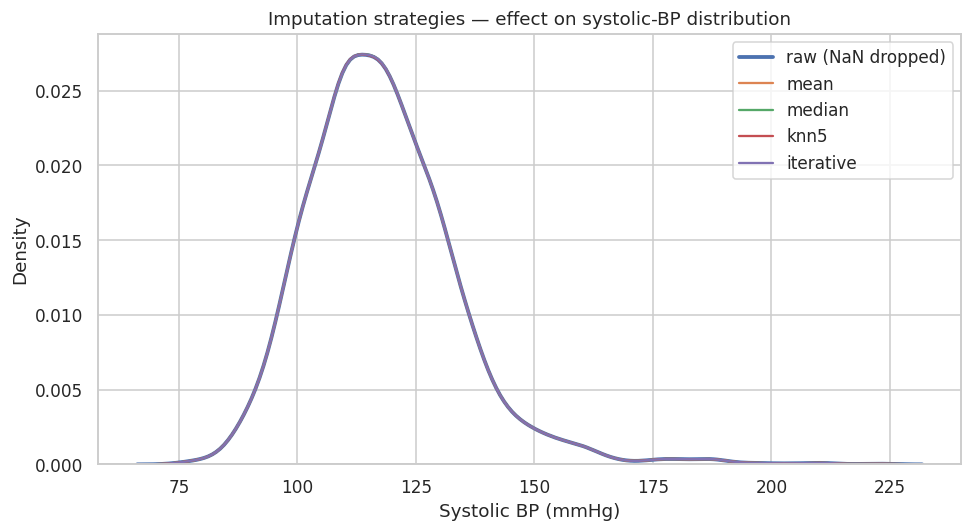

In [53]:
# overlay BP distributions before vs after each imputer
fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(src["bp_systolic"].dropna(), label="raw (NaN dropped)", lw=2.5, ax=ax)
for name, dfi in imp_results.items():
    sns.kdeplot(dfi["bp_systolic"], label=name, lw=1.5, ax=ax)
ax.set_xlabel("Systolic BP (mmHg)")
ax.set_title("Imputation strategies — effect on systolic-BP distribution")
ax.legend(); plt.tight_layout(); plt.show()


In [54]:
# missingness indicator matrix — one binary *_was_missing column per imputable feature
miss_indicators = df_clean[IMPUTE_COLS].isna().astype(int)
miss_indicators.columns = [f"{c}_was_missing" for c in IMPUTE_COLS]
miss_indicators.head()


,bp_systolic_was_missing,bp_diastolic_was_missing,overweight_was_missing,marital_status_was_missing
0,0,0,0,0
1,0,0,0,0
2,0,0,0,0
3,0,0,0,0
4,0,0,0,0


In [55]:
# adopt iterative-imputed values + the missingness indicators going forward
df_clean[IMPUTE_COLS] = imp_results["iterative"]
for c in miss_indicators.columns:
    df_clean[c] = miss_indicators[c]
df_clean.filter(regex="_was_missing$").sum()


bp_systolic_was_missing       1
bp_diastolic_was_missing      1
overweight_was_missing        6
marital_status_was_missing    1
dtype: int64

## 5. Feature Engineering

BP-derived clinical features, lifestyle and cardiometabolic risk scores, interaction terms, target encoding, polynomial / log transforms, routing target, MCAR/MNAR simulators. Nine advanced sub-blocks (5.A - 5.I) follow.

In [56]:
# BP-derived clinical features
df_clean["MAP"]                  = df_clean["bp_diastolic"] + (df_clean["bp_systolic"] - df_clean["bp_diastolic"]) / 3
df_clean["pulse_pressure"]       = df_clean["bp_systolic"] - df_clean["bp_diastolic"]
df_clean["hypertensive_urgency"] = ((df_clean["bp_systolic"] >= 180) | (df_clean["bp_diastolic"] >= 120)).astype(int)
df_clean["isolated_systolic"]    = ((df_clean["bp_systolic"] >= 140) & (df_clean["bp_diastolic"] < 90)).astype(int)
df_clean[["bp_systolic", "bp_diastolic", "MAP", "pulse_pressure",
          "hypertensive_urgency", "isolated_systolic"]].head()


,bp_systolic,bp_diastolic,MAP,pulse_pressure,hypertensive_urgency,isolated_systolic
0,124.0,85.0,98.000000,39.0,0,0
1,122.0,84.0,96.666667,38.0,0,0
2,137.0,93.0,107.666667,44.0,0,0
3,125.0,65.0,85.000000,60.0,0,0
4,127.0,65.0,85.666667,62.0,0,0


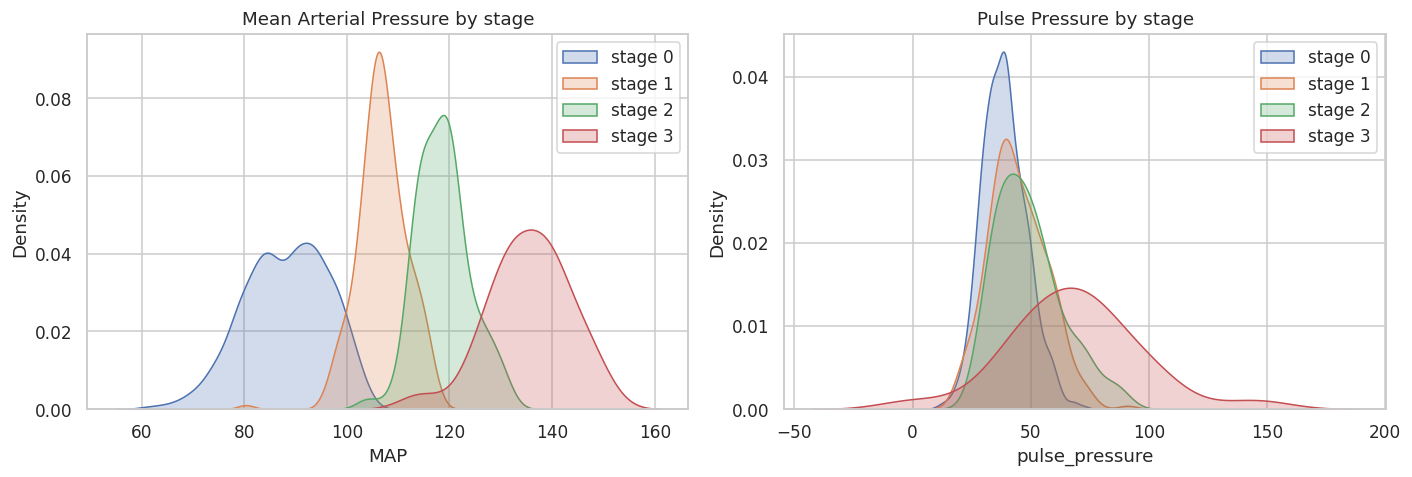

In [57]:
# MAP and PP distributions, colored by htn_stage
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for stage in sorted(df_clean["htn_stage"].dropna().unique()):
    mask = df_clean["htn_stage"] == stage
    sns.kdeplot(df_clean.loc[mask, "MAP"], label=f"stage {int(stage)}", ax=axes[0], fill=True, alpha=0.25)
    sns.kdeplot(df_clean.loc[mask, "pulse_pressure"], label=f"stage {int(stage)}", ax=axes[1], fill=True, alpha=0.25)
axes[0].set_title("Mean Arterial Pressure by stage"); axes[0].legend()
axes[1].set_title("Pulse Pressure by stage");        axes[1].legend()
plt.tight_layout(); plt.show()


**Cardiometabolic composite.** Weighted sum of standardised contributors:

`composite = 0.30·z(MAP) + 0.20·lifestyle_risk + 0.15·artyr_ord + 0.20·z(BMI proxy = overweight) + 0.15·age_indicator`

Weights are heuristic (no calibration data) — they encode the clinical intuition that BP and lifestyle dominate, with HIV exposure (ART years) and age contributing modestly. Only used as a feature, never as a clinical score.

In [58]:
# lifestyle risk score (0-4) and cardiometabolic composite
def num(s): return pd.to_numeric(s, errors="coerce").fillna(0)

df_clean["lifestyle_risk"] = (num(df_clean["smoke"]) + num(df_clean["alcohol"]) +
                              (1 - num(df_clean["exercise"])) + num(df_clean["overweight"]))

z_map = (df_clean["MAP"] - df_clean["MAP"].mean()) / df_clean["MAP"].std()
df_clean["cardiometabolic_composite"] = (
    0.30 * z_map.fillna(0) +
    0.20 * df_clean["lifestyle_risk"] +
    0.15 * num(df_clean["artyr"]) +
    0.20 * num(df_clean["overweight"]) +
    0.15 * num(df_clean["age_category"]).map({0: 1, 1: 0})
)
df_clean[["lifestyle_risk", "cardiometabolic_composite"]].describe().round(3)


,lifestyle_risk,cardiometabolic_composite
count,2645.000,2645.000
mean,0.819,0.627
std,0.815,0.432
min,0.000,-0.485
25%,0.000,0.323
50%,1.000,0.592
75%,1.000,0.886
max,4.000,2.500


2026-05-10 04:56:36,678 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-10 04:56:36,690 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


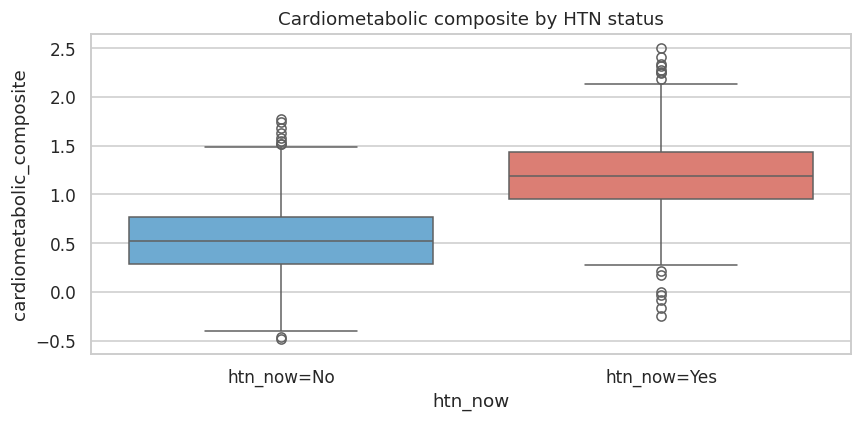

In [59]:
# sanity-check the composite separates HTN positive vs negative
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df_clean.dropna(subset=["htn_now"]), x="htn_now", y="cardiometabolic_composite",
            ax=ax, palette=["#5dade2", "#ec7063"])
ax.set_xticklabels(["htn_now=No", "htn_now=Yes"])
ax.set_title("Cardiometabolic composite by HTN status")
plt.tight_layout(); plt.show()


In [60]:
# clinically motivated interaction features
df_clean["age_x_overweight"]      = num(df_clean["age_category"]).map({0: 1, 1: 0}) * num(df_clean["overweight"])
df_clean["artyr_x_age"]           = num(df_clean["artyr"]) * num(df_clean["age_category"]).map({0: 1, 1: 0})
df_clean["female_x_overweight"]   = num(df_clean["female"]) * num(df_clean["overweight"])
df_clean["pp_x_overweight"]       = df_clean["pulse_pressure"] * num(df_clean["overweight"])
df_clean[["age_x_overweight", "artyr_x_age", "female_x_overweight", "pp_x_overweight"]].describe().round(2)


,age_x_overweight,artyr_x_age,female_x_overweight,pp_x_overweight
count,2645.00,2645.00,2645.00,2645.00
mean,0.11,1.31,0.16,8.45
std,0.31,1.38,0.37,17.16
min,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00
50%,0.00,1.00,0.00,0.00
75%,0.00,3.00,0.00,0.00
max,1.00,4.00,1.00,81.00


In [61]:
# target encoding for hc_code (52 facilities) with additive smoothing — fit on TRAIN only
SMOOTH = 20
train_mask = df_clean.index.isin(df_train.index)
te_src = df_clean.loc[train_mask, ["hc_code", "htn_now"]].copy()
te_src["htn_now"] = pd.to_numeric(te_src["htn_now"], errors="coerce")
te_src = te_src.dropna(subset=["htn_now"])

global_mean = te_src["htn_now"].mean()
agg = te_src.groupby("hc_code")["htn_now"].agg(["sum", "count"])
agg["te"] = (agg["sum"] + SMOOTH * global_mean) / (agg["count"] + SMOOTH)

df_clean["hc_code_te"] = df_clean["hc_code"].map(agg["te"]).fillna(global_mean)
df_clean[["hc_code", "hc_code_te"]].drop_duplicates().head(10)


,hc_code,hc_code_te
0,45,0.095054
51,29,0.110046
106,22,0.151613
157,40,0.078387
207,49,0.126282
257,42,0.111720
307,30,0.147018
360,47,0.118511
410,11,0.063849
460,7,0.077102


In [62]:
# PolynomialFeatures (degree 2) on (sys, dia) — adds sys^2, sys*dia, dia^2
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_arr = poly.fit_transform(df_clean[["bp_systolic", "bp_diastolic"]])
poly_cols = poly.get_feature_names_out(["bp_systolic", "bp_diastolic"])
df_poly = pd.DataFrame(poly_arr, columns=poly_cols, index=df_clean.index)
df_poly.head()


,bp_systolic,bp_diastolic,bp_systolic^2,bp_systolic bp_diastolic,bp_diastolic^2
0,124.0,85.0,15376.0,10540.0,7225.0
1,122.0,84.0,14884.0,10248.0,7056.0
2,137.0,93.0,18769.0,12741.0,8649.0
3,125.0,65.0,15625.0,8125.0,4225.0
4,127.0,65.0,16129.0,8255.0,4225.0


In [63]:
# log transformation — compare skewness before vs after on right-skewed numerics
log_targets = ["bp_systolic", "bp_diastolic", "MAP", "pulse_pressure", "lifestyle_risk"]
df_log = df_clean[log_targets].apply(lambda x: np.log(x + 1))
skew_compare = pd.DataFrame({
    "raw_skew": df_clean[log_targets].skew(),
    "log_skew": df_log.skew(),
}).round(3)
skew_compare


,raw_skew,log_skew
bp_systolic,1.113,0.457
bp_diastolic,0.544,0.027
MAP,0.846,0.319
pulse_pressure,1.083,-0.987
lifestyle_risk,0.747,0.110


In [64]:
# derive the routing target — this is the fourth multi-task label for UGICIS
def derive_route(stage, hc4_v):
    if pd.isna(stage): return np.nan
    s = int(stage)
    if s == 0: return "self_manage"
    if s == 3: return "refer_tertiary"
    if s == 1: return "treat_at_facility"
    return "treat_at_facility" if hc4_v == 1 else "refer_district"


df_clean["route"] = [derive_route(s, h)
                     for s, h in zip(df_clean["htn_stage"], df_clean["hc4"])]
df_clean["route"].value_counts(dropna=False)


route
self_manage          2303
treat_at_facility     262
refer_district         54
refer_tertiary         26
Name: count, dtype: int64

In [65]:
# missingness simulators — MCAR (uniform random) and MNAR (drop more in low-resource subgroups)
SIM_FEATURES = ["bp_systolic", "bp_diastolic", "overweight", "alcohol",
                "smoke", "exercise", "marital_status"]


def inject_mcar(d, cols, rate, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed); o = d.copy()
    for c in cols:
        o.loc[rng.random(len(o)) < rate, c] = np.nan
    return o


def inject_mnar(d, rate, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed); o = d.copy()
    older = (num(o["age_category"]) == 0).to_numpy()
    o.loc[rng.random(len(o)) < np.where(older, rate * 1.8, rate * 0.4), "overweight"] = np.nan
    lower = (num(o["hc4"]) == 0).to_numpy()
    drop_bp = rng.random(len(o)) < np.where(lower, rate * 1.6, rate * 0.6)
    o.loc[drop_bp, "bp_systolic"]  = np.nan
    o.loc[drop_bp, "bp_diastolic"] = np.nan
    htn = (num(o["htn_now"]) == 1).to_numpy()
    o.loc[rng.random(len(o)) < np.where(htn, rate * 1.4, rate * 0.7), "treat"] = np.nan
    return o


In [66]:
# sweep MCAR and MNAR at 10/20/30/40 % and persist each scenario as a parquet
sim_summary_rows = []
for rate in [0.10, 0.20, 0.30, 0.40]:
    for scheme, fn in [("mcar", lambda d, r=rate: inject_mcar(d, SIM_FEATURES, r)),
                       ("mnar", lambda d, r=rate: inject_mnar(d, r))]:
        sim_df = fn(df_clean)
        out_path = SIM_DIR / f"{scheme}_{int(rate * 100):02d}.parquet"
        sim_df.to_parquet(out_path, index=False)
        sim_summary_rows.append({"scheme": scheme, "rate": rate,
                                 "added_missing": int(sim_df.isna().sum().sum() - df_clean.isna().sum().sum()),
                                 "path": str(out_path.relative_to(PROJECT_ROOT))})

sim_summary = pd.DataFrame(sim_summary_rows)
sim_summary.to_csv(TBL_DIR / "missingness_simulation_summary.csv", index=False)
sim_summary


,scheme,rate,added_missing,path
0,mcar,0.1,1791,data/processed/sim/mcar_10.parquet
1,mnar,0.1,1224,data/processed/sim/mnar_10.parquet
2,mcar,0.2,3717,data/processed/sim/mcar_20.parquet
3,mnar,0.2,2466,data/processed/sim/mnar_20.parquet
4,mcar,0.3,5576,data/processed/sim/mcar_30.parquet
5,mnar,0.3,3660,data/processed/sim/mnar_30.parquet
6,mcar,0.4,7414,data/processed/sim/mcar_40.parquet
7,mnar,0.4,4854,data/processed/sim/mnar_40.parquet


In [67]:
# dimensionality reduction — PCA(2) on the fully-engineered feature matrix
from sklearn.decomposition import PCA

PCA_FEATURES = ["bp_systolic", "bp_diastolic", "MAP", "pulse_pressure",
                "lifestyle_risk", "cardiometabolic_composite", "hc_code_te",
                "age_x_overweight", "artyr_x_age", "female_x_overweight",
                "pp_x_overweight", "hypertensive_urgency", "isolated_systolic"]

pca_in = df_clean[PCA_FEATURES].apply(pd.to_numeric, errors="coerce").dropna()
pca_in_scaled = StandardScaler().fit_transform(pca_in)
proj = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(pca_in_scaled)
proj_df = pd.DataFrame(proj, columns=["PC1", "PC2"], index=pca_in.index)
proj_df["htn_stage"] = df_clean.loc[proj_df.index, "htn_stage"]
proj_df["route"]     = df_clean.loc[proj_df.index, "route"]
proj_df.head()


,PC1,PC2,htn_stage,route
0,1.288150,-0.451323,0,self_manage
1,1.095107,-0.352403,0,self_manage
2,2.191718,-1.486967,1,treat_at_facility
3,1.381591,2.765785,0,self_manage
4,-0.656351,-0.745525,0,self_manage


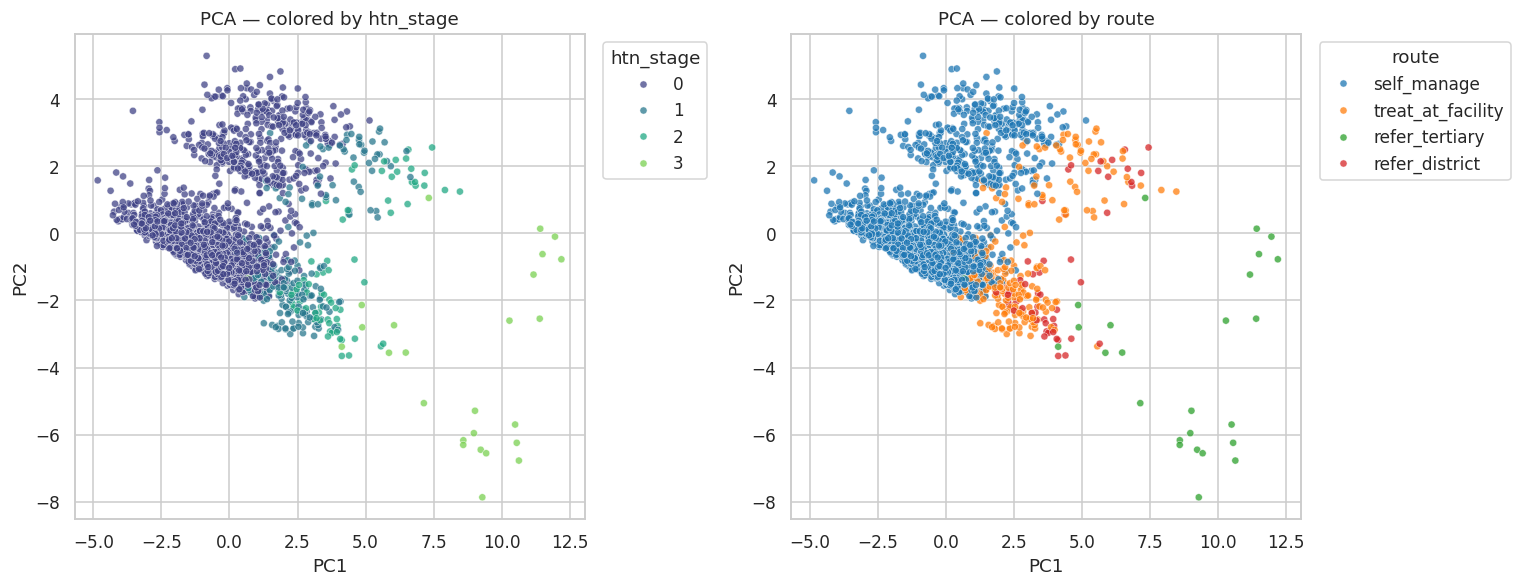

In [68]:
# PCA scatter — left colored by htn_stage, right colored by route
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.scatterplot(data=proj_df, x="PC1", y="PC2", hue="htn_stage",
                palette="viridis", alpha=0.75, s=22, ax=axes[0])
axes[0].set_title("PCA — colored by htn_stage")
axes[0].legend(title="htn_stage", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.scatterplot(data=proj_df, x="PC1", y="PC2", hue="route",
                palette="tab10", alpha=0.75, s=22, ax=axes[1])
axes[1].set_title("PCA — colored by route")
axes[1].legend(title="route", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()


In [69]:
# save the final analysis-ready dataset and the train/test split indices
final_path = PROCESSED_DIR / "ugicis_eda_ready.parquet"
df_clean.to_parquet(final_path, index=False)

split_path = PROCESSED_DIR / "split_indices.json"
with open(split_path, "w") as f:
    json.dump({"random_seed": RANDOM_SEED, "stratify_on": "htn_stage",
               "train_idx": train_idx.tolist(), "test_idx": test_idx.tolist()}, f)

print(f"final dataset → {final_path.relative_to(PROJECT_ROOT)}  shape={df_clean.shape}")
print(f"split file    → {split_path.relative_to(PROJECT_ROOT)}")


final dataset → data/processed/ugicis_eda_ready.parquet  shape=(2645, 42)
split file    → data/processed/split_indices.json


### 5.A Out-of-Fold Target Encoding (leakage-free)

The earlier `hc_code_te` was fit on the training fold but every training row used the same global mean. **K-fold OOF target encoding** computes each row's encoding from the OTHER folds, removing within-train leakage that inflates CV scores.

In [70]:
# 5-fold out-of-fold target encoding for hc_code
SMOOTH = 20
y_full = pd.to_numeric(df_clean["htn_now"], errors="coerce")
fold_assignment = np.full(len(df_clean), -1, dtype=int)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
for f, (_, val_idx) in enumerate(kf.split(df_clean)):
    fold_assignment[val_idx] = f

oof_te = np.full(len(df_clean), np.nan)
for f in range(5):
    train_mask = fold_assignment != f
    val_mask   = fold_assignment == f
    sub = df_clean.loc[train_mask, ["hc_code"]].copy()
    sub["y"] = y_full.loc[train_mask].values
    sub = sub.dropna(subset=["y"])
    g_mean = sub["y"].mean()
    agg = sub.groupby("hc_code")["y"].agg(["sum", "count"])
    agg["te"] = (agg["sum"] + SMOOTH * g_mean) / (agg["count"] + SMOOTH)
    oof_te[val_mask] = df_clean.loc[val_mask, "hc_code"].map(agg["te"]).fillna(g_mean).values

df_clean["hc_code_te_oof"] = oof_te
df_clean[["hc_code_te", "hc_code_te_oof"]].describe().round(4)


,hc_code_te,hc_code_te_oof
count,2645.0000,2645.0000
mean,0.1354,0.1361
std,0.0607,0.0575
min,0.0436,0.0414
25%,0.0920,0.0924
50%,0.1117,0.1212
75%,0.1814,0.1764
max,0.2941,0.3190


### 5.B Weight of Evidence (WoE) + Information Value (IV)

WoE encoding is standard in credit-risk and clinical-risk modelling: each category is replaced by `log(P(feature=k | y=1) / P(feature=k | y=0))`. The summed **Information Value** follows the standard interpretive scale:

| IV | Strength |
|---|---|
| < 0.02 | useless |
| 0.02-0.1 | weak |
| 0.1-0.3 | medium |
| 0.3-0.5 | strong |
| > 0.5 | suspicious (check leakage) |

In [71]:
# Weight of Evidence + Information Value
def woe_iv(feat, target):
    df_w = pd.concat([feat.rename("x"), target.rename("y")], axis=1).dropna()
    df_w["y"] = df_w["y"].astype(int)
    n_pos, n_neg = (df_w["y"] == 1).sum(), (df_w["y"] == 0).sum()
    rows = []
    for k, grp in df_w.groupby("x"):
        p = max((grp["y"] == 1).sum(), 0.5) / n_pos
        q = max((grp["y"] == 0).sum(), 0.5) / n_neg
        woe = np.log(p / q)
        iv  = (p - q) * woe
        rows.append({"category": k, "n": len(grp), "woe": woe, "iv_contrib": iv})
    rows = pd.DataFrame(rows)
    return rows, rows["iv_contrib"].sum()


iv_rows = []
woe_features = [f for f in ["age_category", "female", "artyr", "hc4", "smoke", "alcohol",
                            "overweight", "exercise", "marital_status", "bpmdate6mo",
                            "bp_systolic_bin", "pp_tertile", "phenotype_cluster"]
                if f in df_clean.columns]
for f in woe_features:
    _, iv = woe_iv(df_clean[f], pd.to_numeric(df_clean["htn_now"], errors="coerce"))
    iv_rows.append({"feature": f, "IV": round(iv, 4),
                    "strength": ("useless" if iv < 0.02 else "weak" if iv < 0.1
                                 else "medium" if iv < 0.3 else "strong" if iv < 0.5
                                 else "suspicious")})

iv_table = pd.DataFrame(iv_rows).sort_values("IV", ascending=False)
iv_table.to_csv(TBL_DIR / "information_value.csv", index=False)
iv_table


,feature,IV,strength
12,phenotype_cluster,2.9784,suspicious
10,bp_systolic_bin,2.8506,suspicious
11,pp_tertile,0.2873,medium
0,age_category,0.1947,medium
8,marital_status,0.0797,weak
6,overweight,0.0570,weak
5,alcohol,0.0517,weak
9,bpmdate6mo,0.0339,weak
7,exercise,0.0088,useless
2,artyr,0.0046,useless


In [72]:
# apply WoE encoding to features with IV >= 0.02
keep_woe = iv_table.loc[iv_table["IV"] >= 0.02, "feature"].tolist()
y_woe = pd.to_numeric(df_clean["htn_now"], errors="coerce")
for f in keep_woe:
    rows, _ = woe_iv(df_clean[f], y_woe)
    map_ = dict(zip(rows["category"], rows["woe"]))
    df_clean[f + "_woe"] = df_clean[f].map(map_).astype(float)
df_clean.filter(regex="_woe$").describe().round(3)


,phenotype_cluster_woe,bp_systolic_bin_woe,pp_tertile_woe,age_category_woe,marital_status_woe,overweight_woe,alcohol_woe,bpmdate6mo_woe
count,2645.000,2644.000,2644.000,2645.000,2645.000,2645.000,2645.000,2645.000
mean,-0.851,-0.283,-0.102,-0.074,-0.027,-0.012,-0.018,-0.008
std,1.495,1.473,0.524,0.455,0.278,0.221,0.220,0.145
min,-1.664,-0.687,-0.609,-0.553,-0.547,-0.125,-0.160,-0.021
25%,-1.664,-0.687,-0.609,-0.553,-0.164,-0.125,-0.160,-0.021
50%,-1.439,-0.687,-0.261,0.358,-0.164,-0.125,-0.160,-0.021
75%,-1.387,-0.687,0.633,0.358,0.371,-0.125,0.325,-0.021
max,2.584,5.802,0.633,0.358,1.158,1.158,0.325,1.651


### 5.C Natural Cubic Spline Basis on BP

Polynomial features can extrapolate badly. A **natural cubic spline basis** (`patsy.dmatrix("bs(x, df=4, degree=3)", ...)`) gives a smooth non-linear basis that is well-behaved at the tails — the standard recommendation for continuous covariates in clinical regression.

In [73]:
# natural cubic spline basis on systolic BP
bp_for_spline = df_clean["bp_systolic"].fillna(df_clean["bp_systolic"].median()).astype(float)
spline_basis = dmatrix("bs(bp, df=4, degree=3, include_intercept=False)",
                       {"bp": bp_for_spline.values}, return_type="dataframe")
spline_basis.columns = [f"bp_spl_{i+1}" for i in range(spline_basis.shape[1])]
spline_basis.index = df_clean.index
df_clean = pd.concat([df_clean, spline_basis], axis=1)
df_clean.filter(regex="^bp_spl_").head()


,bp_spl_1,bp_spl_2,bp_spl_3,bp_spl_4,bp_spl_5
0,1.0,0.416550,0.454884,0.128136,0.000430
1,1.0,0.442577,0.443746,0.113496,0.000181
2,1.0,0.271797,0.482599,0.237828,0.007776
3,1.0,0.403928,0.459712,0.135748,0.000612
4,1.0,0.379454,0.467931,0.151498,0.001118


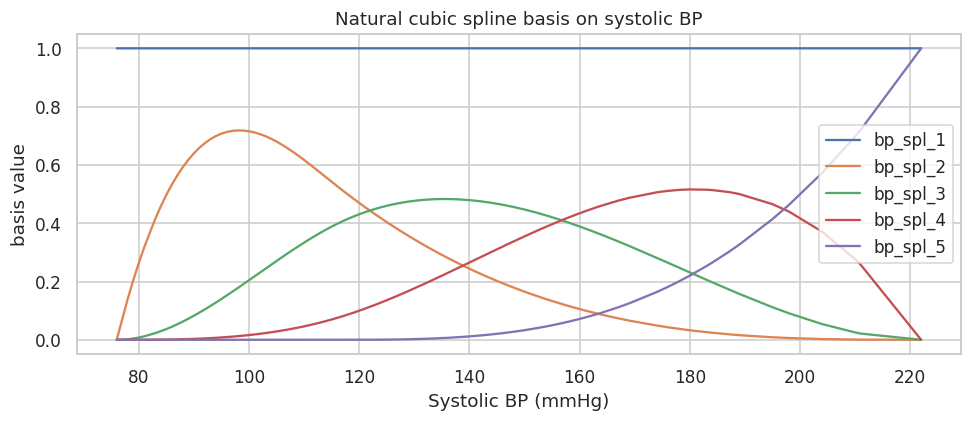

In [74]:
# visualise the spline basis vs raw BP
fig, ax = plt.subplots(figsize=(9, 4))
ord_ = bp_for_spline.argsort()
for c in spline_basis.columns:
    ax.plot(bp_for_spline.values[ord_], spline_basis[c].values[ord_], label=c)
ax.set_xlabel("Systolic BP (mmHg)"); ax.set_ylabel("basis value")
ax.set_title("Natural cubic spline basis on systolic BP")
ax.legend(); plt.tight_layout(); plt.show()


### 5.D Box-Tidwell Linearity Test

The Box-Tidwell test checks whether each continuous predictor enters the logit linearly. We add an interaction term `x · log(x)` and test whether its coefficient is significant. If it is, a transformation (log, spline) is needed for that variable.

In [75]:
# Box-Tidwell linearity test for each continuous predictor
bt_rows = []
y_ = pd.to_numeric(df_clean["htn_now"], errors="coerce")
for c in ["bp_systolic", "bp_diastolic", "MAP", "pulse_pressure", "lifestyle_risk"]:
    if c not in df_clean.columns: continue
    sub = pd.DataFrame({"x": df_clean[c], "y": y_}).dropna()
    sub = sub[sub["x"] > 0]
    if len(sub) < 30: continue
    sub["x_logx"] = sub["x"] * np.log(sub["x"])
    X_ = sm.add_constant(sub[["x", "x_logx"]])
    try:
        m = sm.GLM(sub["y"], X_, family=sm.families.Binomial()).fit(disp=False)
        bt_rows.append({"feature": c, "coef_x_logx": round(float(m.params["x_logx"]), 4),
                        "p_value": float(m.pvalues["x_logx"]),
                        "linearity_violated": bool(m.pvalues["x_logx"] < 0.05)})
    except Exception:
        pass
pd.DataFrame(bt_rows)


,feature,coef_x_logx,p_value,linearity_violated
0,bp_systolic,0.5275,6.646901e-07,True
1,bp_diastolic,1.4628,4.574254e-44,True
2,MAP,1.6560,1.566242e-42,True
3,pulse_pressure,0.0830,6.067998e-04,True
4,lifestyle_risk,-0.2922,6.213721e-01,False


### 5.E Multiple Imputation (MICE, M=5) with Rubin's Rules

Single imputation underestimates uncertainty. **Multiple imputation** generates M imputed datasets, computes the statistic on each, then pools using **Rubin's rules**: `Var_total = within + (1 + 1/M) · between`. We demonstrate on HTN prevalence by `overweight` — the pooled SE exceeds the single-imputation SE because it includes between-imputation variance.

In [76]:
# MICE M=5 + Rubin's-rules pooling for prevalence-by-overweight
M = 5
impute_cols = [c for c in ["bp_systolic", "bp_diastolic", "overweight", "marital_status"]
               if c in df_clean.columns]
src_mi = df_clean[impute_cols].apply(pd.to_numeric, errors="coerce")

estimates, variances = [], []
for m in range(M):
    imp = IterativeImputer(random_state=RANDOM_SEED + m, sample_posterior=True, max_iter=10)
    arr = imp.fit_transform(src_mi)
    imputed = pd.DataFrame(arr, columns=impute_cols, index=src_mi.index)
    overweight_now = (imputed["overweight"] > 0.5).astype(int)
    y_ = pd.to_numeric(df_clean["htn_now"], errors="coerce").fillna(0).astype(int)
    grp = pd.DataFrame({"ow": overweight_now, "y": y_}).groupby("ow")["y"]
    estimates.append(grp.mean().reindex([0, 1]).values)
    variances.append((grp.var(ddof=1) / grp.count()).reindex([0, 1]).values)

estimates = np.array(estimates); variances = np.array(variances)
Q_bar = estimates.mean(axis=0)
U_bar = variances.mean(axis=0)
B     = ((estimates - Q_bar) ** 2).sum(axis=0) / (M - 1)
T     = U_bar + (1 + 1 / M) * B

pooled = pd.DataFrame({
    "overweight=0": [Q_bar[0], np.sqrt(U_bar[0]), np.sqrt(T[0])],
    "overweight=1": [Q_bar[1], np.sqrt(U_bar[1]), np.sqrt(T[1])],
}, index=["pooled_estimate", "single_imp_SE", "rubin_pooled_SE"]).round(4)
pooled


,overweight=0,overweight=1
pooled_estimate,0.1214,0.1899
single_imp_SE,0.0071,0.0167
rubin_pooled_SE,0.0071,0.0167


### 5.F Permutation Importance + RFECV Baseline Ranking

- **Permutation importance** on a baseline RandomForest: how much does test AUC drop when each feature is shuffled?
- **RFECV**: iteratively remove the weakest feature and find the subset that maximises CV AUC.

In [77]:
# baseline RandomForest -> permutation importance
y_rf = pd.to_numeric(df_clean["htn_now"], errors="coerce").fillna(0).astype(int)
imp_features = [c for c in df_clean.columns
                if c not in {"htn_now", "htn_stage", "treat", "new_dx", "prior_unknown",
                             "category", "route", "hc_code", "clinicid", "bpfinal",
                             "bp_systolic_bin", "pp_tertile"}]
X_rf = df_clean[imp_features].apply(pd.to_numeric, errors="coerce")
X_rf = X_rf.fillna(X_rf.median(numeric_only=True)).select_dtypes(include=[np.number])

X_tr, X_te, y_tr, y_te = train_test_split(X_rf, y_rf, test_size=0.25,
                                          stratify=y_rf, random_state=RANDOM_SEED)
rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_SEED, n_jobs=-1).fit(X_tr, y_tr)
print(f"baseline RF test AUC: {roc_auc_score(y_te, rf.predict_proba(X_te)[:, 1]):.4f}")

perm = permutation_importance(rf, X_te, y_te, n_repeats=10,
                              random_state=RANDOM_SEED, n_jobs=-1, scoring="roc_auc")
perm_df = pd.DataFrame({"feature": X_rf.columns,
                        "perm_importance_mean": perm.importances_mean,
                        "perm_importance_std":  perm.importances_std})
perm_df = perm_df.sort_values("perm_importance_mean", ascending=False)
perm_df.to_csv(TBL_DIR / "permutation_importance.csv", index=False)
perm_df.head(20)


baseline RF test AUC: 0.9293


,feature,perm_importance_mean,perm_importance_std
11,bp_diastolic,0.024920,0.006367
43,bp_spl_5,0.011636,0.005607
40,bp_spl_2,0.011282,0.004859
24,cardiometabolic_composite,0.010977,0.004180
42,bp_spl_4,0.010895,0.004729
10,bp_systolic,0.010692,0.005322
20,MAP,0.009648,0.006722
41,bp_spl_3,0.007073,0.006674
32,bp_systolic_bin_woe,0.005746,0.003238
29,hc_code_te,0.004388,0.003599


In [78]:
# RFECV — find the optimal feature subset
rfecv = RFECV(estimator=RandomForestClassifier(n_estimators=200, max_depth=6,
                                               random_state=RANDOM_SEED, n_jobs=-1),
              step=2, cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED),
              scoring="roc_auc", min_features_to_select=5, n_jobs=-1)
rfecv.fit(X_rf, y_rf)
print(f"RFECV chose {rfecv.n_features_} features")
print(f"Best CV AUC : {rfecv.cv_results_['mean_test_score'].max():.4f}")

selected = X_rf.columns[rfecv.support_].tolist()
pd.Series(selected, name="rfecv_selected").to_csv(TBL_DIR / "rfecv_selected_features.csv", index=False)
print("First 15 selected features:", selected[:15])


RFECV chose 36 features
Best CV AUC : 0.9620
First 15 selected features: ['age_category', 'female', 'artyr', 'hc4', 'smoke', 'alcohol', 'marital_status', 'bpmdate6mo', 'bp_systolic', 'bp_diastolic', 'phenotype_cluster', 'anomaly_score', 'is_anomaly', 'pulse_pressure', 'MAP']


### 5.G SMOTENC for Mixed-Type Oversampling

HTN prevalence is ~14 %. **SMOTENC** is the SMOTE variant that handles mixed continuous/categorical features correctly — it interpolates continuous variables and uses the most-frequent category for categoricals.

In [79]:
# SMOTENC — train fold only
cat_idx = [i for i, c in enumerate(X_rf.columns)
           if X_rf[c].nunique() <= 5 and set(X_rf[c].dropna().unique()).issubset({0, 1, 2, 3, 4})]
print(f"Categorical column indices passed to SMOTENC: {len(cat_idx)}")

sm_oversampler = SMOTENC(categorical_features=cat_idx, random_state=RANDOM_SEED)
X_res, y_res = sm_oversampler.fit_resample(X_tr, y_tr)
print(f"Before SMOTENC : positives={y_tr.sum():4d}, negatives={(y_tr==0).sum():4d}")
print(f"After  SMOTENC : positives={y_res.sum():4d}, negatives={(y_res==0).sum():4d}")


Categorical column indices passed to SMOTENC: 18


Before SMOTENC : positives= 269, negatives=1714
After  SMOTENC : positives=1714, negatives=1714


### 5.H t-SNE Embedding of the Engineered Feature Space

PCA captures linear variance; **t-SNE** preserves local neighbourhood structure and often shows clearer clusters when the underlying manifold is non-linear.

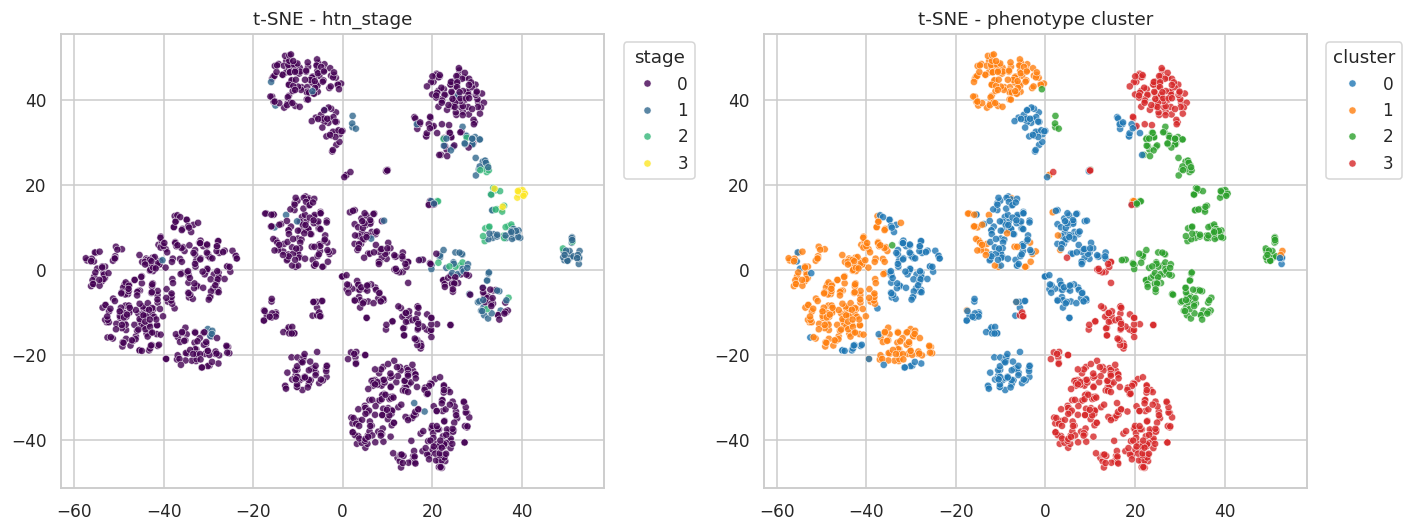

In [80]:
# t-SNE embedding (perplexity=30) on a sample for speed
sample_idx = np.random.RandomState(RANDOM_SEED).choice(len(X_rf), size=min(1500, len(X_rf)), replace=False)
X_sample = StandardScaler().fit_transform(X_rf.iloc[sample_idx])
tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=RANDOM_SEED).fit_transform(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x=tsne[:, 0], y=tsne[:, 1],
                hue=df_clean["htn_stage"].iloc[sample_idx].astype("Int64"),
                palette="viridis", s=22, alpha=0.8, ax=axes[0])
axes[0].set_title("t-SNE - htn_stage"); axes[0].legend(title="stage", bbox_to_anchor=(1.02, 1), loc="upper left")
sns.scatterplot(x=tsne[:, 0], y=tsne[:, 1],
                hue=df_clean["phenotype_cluster"].iloc[sample_idx],
                palette="tab10", s=22, alpha=0.8, ax=axes[1])
axes[1].set_title("t-SNE - phenotype cluster"); axes[1].legend(title="cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()


### 5.I Comprehensive Feature Report Card

A single ranked table consolidating all evidence: missingness, Cramér's V, mutual information, odds ratio, Information Value, permutation importance, RFECV-selected. This is the artifact downstream modelling decisions should reference.

In [81]:
# consolidated feature report card
report = pd.DataFrame(index=df_clean.columns)
report["missing_pct"] = (df_clean.isna().mean() * 100).round(2)


def safe_cramers_v(x, y):
    sub = pd.concat([x, y], axis=1).dropna()
    if sub.empty or sub.iloc[:, 0].nunique() < 2 or sub.iloc[:, 1].nunique() < 2:
        return np.nan
    tab = pd.crosstab(sub.iloc[:, 0], sub.iloc[:, 1])
    chi2 = stats.chi2_contingency(tab, correction=False)[0]
    n = tab.values.sum(); r, k = tab.shape
    phi2c = max(0.0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    rc = r - (r - 1) ** 2 / (n - 1); kc = k - (k - 1) ** 2 / (n - 1)
    denom = min(kc - 1, rc - 1)
    return float(np.sqrt(phi2c / denom)) if denom > 0 else np.nan


tgt = pd.to_numeric(df_clean["htn_now"], errors="coerce")
report["cramers_v_htn"] = [round(safe_cramers_v(df_clean[c], tgt), 3) if c != "htn_now" else np.nan
                            for c in df_clean.columns]

report = report.join(iv_table.set_index("feature")["IV"].rename("information_value"), how="left")
report = report.join(or_df.set_index("feature")[["OR", "p_value"]].rename(
    columns={"OR": "odds_ratio", "p_value": "OR_pvalue"}), how="left")
report = report.join(perm_df.set_index("feature")["perm_importance_mean"].rename("perm_importance"), how="left")
report = report.join(mi_df["htn_now"].rename("mutual_info_htn"), how="left")
report["selected_by_rfecv"] = report.index.isin(selected)

report = report.sort_values("perm_importance", ascending=False)
report.to_csv(TBL_DIR / "feature_report_card.csv")
report.head(25).round(3)


,missing_pct,cramers_v_htn,information_value,odds_ratio,OR_pvalue,perm_importance,mutual_info_htn,selected_by_rfecv
bp_diastolic,0.00,0.824,NaN,NaN,NaN,0.025,0.256,True
bp_spl_5,0.00,0.713,NaN,NaN,NaN,0.012,NaN,True
bp_spl_2,0.00,0.707,NaN,NaN,NaN,0.011,NaN,True
cardiometabolic_composite,0.00,0.551,NaN,NaN,NaN,0.011,NaN,True
bp_spl_4,0.00,0.707,NaN,NaN,NaN,0.011,NaN,True
bp_systolic,0.00,0.706,NaN,NaN,NaN,0.011,0.185,True
MAP,0.00,0.800,NaN,NaN,NaN,0.010,NaN,True
bp_spl_3,0.00,0.707,NaN,NaN,NaN,0.007,NaN,True
bp_systolic_bin_woe,0.04,0.663,NaN,NaN,NaN,0.006,NaN,True
hc_code_te,0.00,0.205,NaN,NaN,NaN,0.004,NaN,True


## 6. Build the Modelling Matrix

Distil the engineered df_clean into leakage-free X and y.

In [82]:
# Build the modelling matrix from the engineered df_clean above.
# Drop direct labels of the htn_now task (htn_stage, treat, new_dx, prior_unknown,
# category, route) and the categorical bin columns we already encoded.
LEAKAGE_COLS = ["htn_stage", "treat", "new_dx", "prior_unknown", "category", "route",
                "htn_stage_ord", "bp_systolic_bin", "pp_tertile"]

modelling_df = df_clean.drop(columns=[c for c in LEAKAGE_COLS if c in df_clean.columns],
                             errors="ignore").copy()

# Coerce remaining categoricals to numeric codes
for c in modelling_df.columns:
    if str(modelling_df[c].dtype) == "category":
        modelling_df[c] = modelling_df[c].cat.codes.replace(-1, np.nan)

modelling_df = modelling_df.apply(pd.to_numeric, errors="coerce")
modelling_df = modelling_df.fillna(modelling_df.median(numeric_only=True))

y = modelling_df["htn_now"].astype(int)
X = modelling_df.drop(columns=["htn_now"])

processed_data = modelling_df.copy()  # alias for legacy modelling cells

print(f"Modelling matrix  X shape: {X.shape}")
print(f"Target prevalence y mean : {y.mean():.3f}")
X.head()


Modelling matrix  X shape: (2645, 47)
Target prevalence y mean : 0.136


,hc_code,clinicid,age_category,female,artyr,hc4,smoke,alcohol,overweight,marital_status,...,age_category_woe,marital_status_woe,overweight_woe,alcohol_woe,bpmdate6mo_woe,bp_spl_1,bp_spl_2,bp_spl_3,bp_spl_4,bp_spl_5
0,45,1,0,0,2,1,0,1,0.0,2.0,...,0.358112,-0.163667,-0.124593,0.324865,-0.020566,1.0,0.416550,0.454884,0.128136,0.000430
1,45,2,0,0,2,1,0,1,0.0,2.0,...,0.358112,-0.163667,-0.124593,0.324865,-0.020566,1.0,0.442577,0.443746,0.113496,0.000181
2,45,3,0,0,2,1,0,0,0.0,2.0,...,0.358112,-0.163667,-0.124593,-0.159737,-0.020566,1.0,0.271797,0.482599,0.237828,0.007776
3,45,4,1,1,2,1,0,0,1.0,2.0,...,-0.552759,-0.163667,0.400404,-0.159737,-0.020566,1.0,0.403928,0.459712,0.135748,0.000612
4,45,5,1,1,1,1,0,0,0.0,2.0,...,-0.552759,-0.163667,-0.124593,-0.159737,-0.020566,1.0,0.379454,0.467931,0.151498,0.001118


## 7. Cross-Validation (XGBoost, 5-fold stratified)

In [83]:
# 5-fold stratified CV with XGBoost; per-fold scale_pos_weight handles imbalance
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
fold_metrics = []

print("Starting 5-fold cross-validation...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    spw = (len(y_train) - sum(y_train)) / max(sum(y_train), 1)
    model = xgb.XGBClassifier(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, eval_metric="aucpr",
        random_state=RANDOM_SEED, n_jobs=-1,
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    probs = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, probs)
    fold_metrics.append(auc)
    print(f"Fold {fold + 1} ROC-AUC: {auc:.4f}")

print(f"\nMean CV ROC-AUC: {np.mean(fold_metrics):.4f} (+/- {np.std(fold_metrics):.4f})")


Starting 5-fold cross-validation...


Fold 1 ROC-AUC: 0.9516


Fold 2 ROC-AUC: 0.9586


Fold 3 ROC-AUC: 0.9816


Fold 4 ROC-AUC: 0.9613


Fold 5 ROC-AUC: 0.9747

Mean CV ROC-AUC: 0.9656 (+/- 0.0110)


## 8. Explainable AI (SHAP)

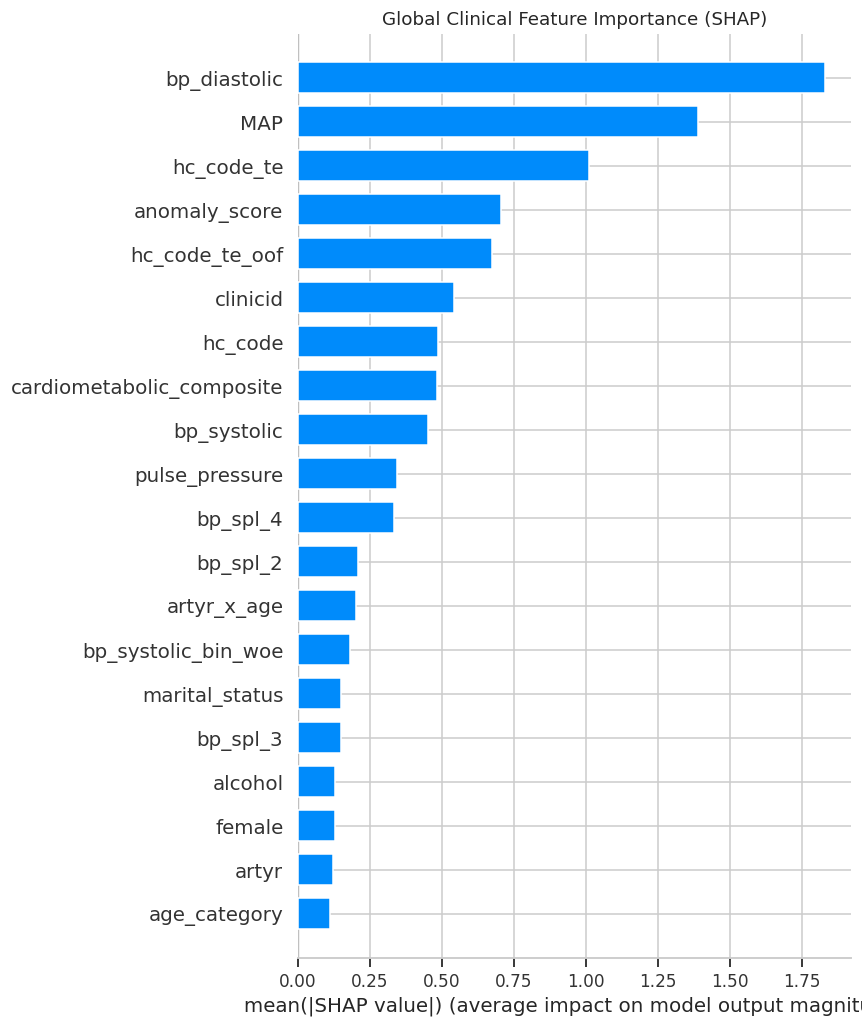

In [84]:
# SHAP global feature impact (using the last fold's model as representative)
final_model = model
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X, plot_type="bar", show=False)
plt.title("Global Clinical Feature Importance (SHAP)")
plt.tight_layout(); plt.show()


## 9. Clinical Calibration

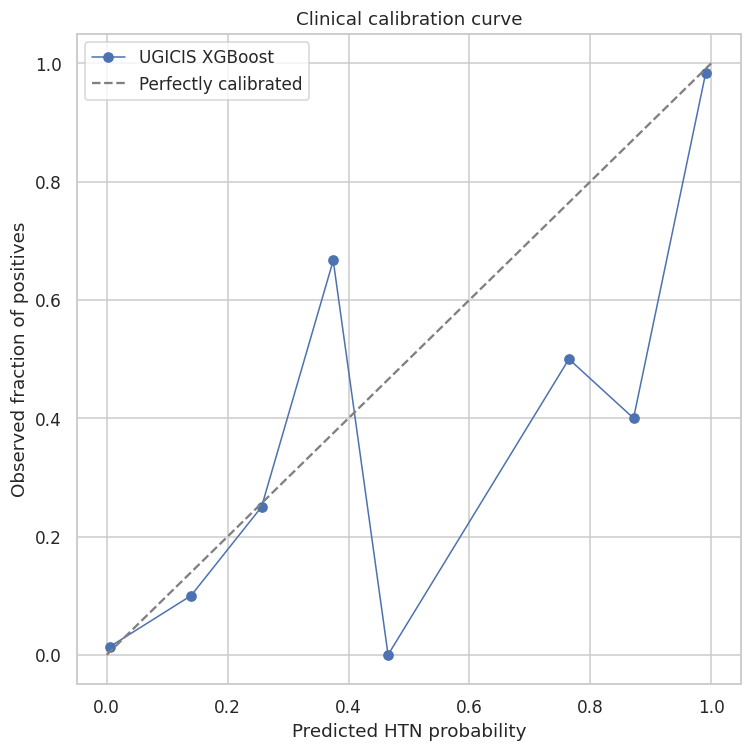

Brier score on val fold: 0.0239


In [85]:
# Reliability diagram on the held-out fold
prob_true, prob_pred = calibration_curve(y_val, probs, n_bins=10)

plt.figure(figsize=(7, 7))
plt.plot(prob_pred, prob_true, marker="o", lw=1, label="UGICIS XGBoost")
plt.plot([0, 1], [0, 1], ls="--", color="gray", label="Perfectly calibrated")
plt.xlabel("Predicted HTN probability")
plt.ylabel("Observed fraction of positives")
plt.title("Clinical calibration curve")
plt.legend(); plt.tight_layout(); plt.show()

print(f"Brier score on val fold: {brier_score_loss(y_val, probs):.4f}")


## 10. Classical Baseline Benchmark

We now run a *fair head-to-head comparison* of the most common shallow learners
on the **same engineered modelling matrix** (`X`, `y`) that XGBoost was trained on
in Section 7, plus the two secondary targets `htn_stage` and `treat`
(pulled back from `df_clean`).  All models use the **same 5-fold stratified
splits**, the **same metrics**, and the **same class-imbalance handling**
(`scale_pos_weight` for boosted trees, `class_weight="balanced"` for the others),
so any difference reflects model capacity / inductive bias rather than tooling.

Per-target metrics reported:

* **ROC-AUC** — overall discrimination
* **PR-AUC** — discrimination under prevalence (more honest for rare classes)
* **Recall @ 90 % precision** — how many true cases we catch when we promise
  90 % precision (the operating point a clinician cares about)
* **Brier score** — calibration + sharpness, lower is better
* **Calibration slope** (logistic-regression slope on logit(p̂) vs y) —
  values close to 1 mean the predicted probabilities are well-scaled.

The full leaderboard is saved to `reports/tables/baseline_leaderboard.csv`.


In [86]:
# --- additional baseline-benchmark imports ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import lightgbm as lgb
from catboost import CatBoostClassifier
import time


In [87]:
# --- evaluation harness ---
def _calibration_slope(y_true: np.ndarray, p_hat: np.ndarray) -> float:
    """Slope of logistic regression of y on logit(p̂); 1.0 = perfectly calibrated."""
    eps = 1e-6
    p = np.clip(p_hat, eps, 1 - eps)
    logit = np.log(p / (1 - p)).reshape(-1, 1)
    try:
        lr = LogisticRegression(C=1e6, solver="lbfgs", max_iter=1000)
        lr.fit(logit, y_true)
        return float(lr.coef_[0, 0])
    except Exception:
        return float("nan")


def _recall_at_precision(y_true: np.ndarray, p_hat: np.ndarray,
                         min_precision: float = 0.90) -> float:
    """Highest recall achievable while precision >= min_precision."""
    prec, rec, _ = precision_recall_curve(y_true, p_hat)
    mask = prec[:-1] >= min_precision  # drop the last point (no threshold)
    return float(rec[:-1][mask].max()) if mask.any() else 0.0


def evaluate_predictions(y_true: np.ndarray, p_hat: np.ndarray) -> dict:
    return {
        "ROC_AUC":        float(roc_auc_score(y_true, p_hat)),
        "PR_AUC":         float(average_precision_score(y_true, p_hat)),
        "Recall@90%Prec": _recall_at_precision(y_true, p_hat, 0.90),
        "Brier":          float(brier_score_loss(y_true, p_hat)),
        "CalibSlope":     _calibration_slope(y_true, p_hat),
    }


def _build_estimator(name: str, spw: float):
    """Construct a fresh estimator with class-imbalance handling baked in."""
    if name == "LogisticRegression":
        return Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                       solver="lbfgs", C=1.0,
                                       random_state=RANDOM_SEED)),
        ])
    if name == "RandomForest":
        return Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=400, max_depth=None, min_samples_leaf=2,
                class_weight="balanced_subsample", n_jobs=-1,
                random_state=RANDOM_SEED,
            )),
        ])
    if name == "LightGBM":
        return lgb.LGBMClassifier(
            n_estimators=600, learning_rate=0.05, max_depth=-1, num_leaves=63,
            subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
            objective="binary", random_state=RANDOM_SEED, n_jobs=-1, verbose=-1,
        )
    if name == "CatBoost":
        return CatBoostClassifier(
            iterations=600, learning_rate=0.05, depth=6,
            scale_pos_weight=spw, loss_function="Logloss",
            random_seed=RANDOM_SEED, verbose=False, allow_writing_files=False,
        )
    if name == "XGBoost":
        return xgb.XGBClassifier(
            n_estimators=500, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
            eval_metric="aucpr", random_state=RANDOM_SEED,
            n_jobs=-1, tree_method="hist",
        )
    raise ValueError(f"Unknown estimator: {name}")


def cv_benchmark(X_df: pd.DataFrame, y_arr: pd.Series, model_names: list[str],
                 n_splits: int = 5, seed: int = RANDOM_SEED) -> tuple[pd.DataFrame, dict]:
    """Run stratified K-fold CV for every model in `model_names`.

    Returns
    -------
    long_df : per-(model, fold) metrics
    oof     : dict[name] -> 1-D array of out-of-fold probabilities (same length as y)
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    rows: list[dict] = []
    oof: dict[str, np.ndarray] = {n: np.zeros(len(y_arr)) for n in model_names}

    for fold, (tr, va) in enumerate(skf.split(X_df, y_arr), start=1):
        X_tr, X_va = X_df.iloc[tr], X_df.iloc[va]
        y_tr, y_va = y_arr.iloc[tr], y_arr.iloc[va]
        spw = float((len(y_tr) - y_tr.sum()) / max(y_tr.sum(), 1))

        for name in model_names:
            t0 = time.time()
            est = _build_estimator(name, spw)
            est.fit(X_tr, y_tr)
            p = est.predict_proba(X_va)[:, 1]
            oof[name][va] = p
            metrics = evaluate_predictions(y_va.values, p)
            metrics.update({"model": name, "fold": fold,
                            "fit_seconds": round(time.time() - t0, 2)})
            rows.append(metrics)
    return pd.DataFrame(rows), oof


print("Benchmark harness loaded.")


Benchmark harness loaded.


In [88]:
# --- target dictionary (htn_now from Section 6 + htn_stage and treat from df_clean) ---
y_primary = y.copy()
y_stage   = pd.to_numeric(df_clean.get("htn_stage_ord",
                                       df_clean.get("htn_stage")), errors="coerce")
y_treat   = pd.to_numeric(df_clean.get("treat"), errors="coerce")

# Align indices -- modelling_df may have dropped rows; reindex everything onto X.index
y_stage = y_stage.reindex(X.index).fillna(0).astype(int)
y_treat = y_treat.reindex(X.index).fillna(0).astype(int)

# Binarise htn_stage to "stage >= 1" because stages 2/3 are very rare (most cells are 0/1)
y_stage_bin = (y_stage >= 1).astype(int)

print(f"Target prevalences -- htn_now: {y_primary.mean():.3f} | "
      f"htn_stage>=1: {y_stage_bin.mean():.3f} | "
      f"treat: {y_treat.mean():.3f}")

# Belt-and-braces: any residual NaN (e.g. from columns whose median was itself NaN)
if X.isna().any().any():
    n_bad = int(X.isna().sum().sum())
    print(f"Filling {n_bad} residual NaN cells in X with 0.")
    X = X.fillna(X.median(numeric_only=True)).fillna(0)


Target prevalences -- htn_now: 0.136 | htn_stage>=1: 0.129 | treat: 0.016
Filling 2645 residual NaN cells in X with 0.


In [89]:
# --- run the leaderboard ---
MODEL_NAMES = ["LogisticRegression", "RandomForest", "LightGBM", "CatBoost", "XGBoost"]
TARGETS = {
    "htn_now":       y_primary,
    "htn_stage>=1":  y_stage_bin,
    "treat":         y_treat,
}

leaderboards: dict[str, pd.DataFrame] = {}
oof_store: dict[str, dict[str, np.ndarray]] = {}

for tname, ty in TARGETS.items():
    print(f"\n=== Target: {tname}  (n_pos={int(ty.sum())} / {len(ty)}) ===")
    long_df, oof = cv_benchmark(X, ty, MODEL_NAMES)
    long_df["target"] = tname
    leaderboards[tname] = long_df
    oof_store[tname] = oof

    # Per-fold mean ROC-AUC summary printed inline
    summary = (long_df.groupby("model")[["ROC_AUC", "PR_AUC", "Brier"]]
                       .mean().round(4).sort_values("ROC_AUC", ascending=False))
    print(summary.to_string())

leaderboard_long = pd.concat(leaderboards.values(), ignore_index=True)
leaderboard_long.head()



=== Target: htn_now  (n_pos=359 / 2645) ===


                    ROC_AUC  PR_AUC   Brier
model                                      
LightGBM             0.9663  0.9238  0.0247
XGBoost              0.9656  0.9277  0.0228
CatBoost             0.9651  0.9317  0.0226
RandomForest         0.9642  0.9227  0.0246
LogisticRegression   0.9550  0.8908  0.0577

=== Target: htn_stage>=1  (n_pos=342 / 2645) ===


                    ROC_AUC  PR_AUC   Brier
model                                      
CatBoost             1.0000  1.0000  0.0000
LightGBM             1.0000  1.0000  0.0007
RandomForest         1.0000  1.0000  0.0027
XGBoost              1.0000  1.0000  0.0000
LogisticRegression   0.9975  0.9944  0.0101

=== Target: treat  (n_pos=41 / 2645) ===


                    ROC_AUC  PR_AUC   Brier
model                                      
RandomForest         0.8688  0.1533  0.0151
CatBoost             0.8358  0.1527  0.0178
XGBoost              0.8267  0.1992  0.0162
LogisticRegression   0.8230  0.1589  0.1237
LightGBM             0.7897  0.1616  0.0174


,ROC_AUC,PR_AUC,Recall@90%Prec,Brier,CalibSlope,model,fold,fit_seconds,target
0,0.953779,0.894008,0.830986,0.054362,1.130338,LogisticRegression,1,0.07,htn_now
1,0.950058,0.907838,0.901408,0.024312,0.989506,RandomForest,1,4.73,htn_now
2,0.952549,0.895941,0.901408,0.021338,0.295950,LightGBM,1,3.26,htn_now
3,0.950981,0.913732,0.901408,0.020560,0.649014,CatBoost,1,2.38,htn_now
4,0.951596,0.901486,0.901408,0.021552,0.563171,XGBoost,1,2.45,htn_now


In [90]:
# --- aggregate to per-(target, model) means + std ---
agg_metrics = ["ROC_AUC", "PR_AUC", "Recall@90%Prec", "Brier", "CalibSlope", "fit_seconds"]
leaderboard = (leaderboard_long
               .groupby(["target", "model"])[agg_metrics]
               .agg(["mean", "std"])
               .round(4))
leaderboard.columns = [f"{m}_{stat}" for m, stat in leaderboard.columns]
leaderboard = leaderboard.reset_index()

OUT = Path("reports/tables/baseline_leaderboard.csv")
OUT.parent.mkdir(parents=True, exist_ok=True)
leaderboard.to_csv(OUT, index=False)
print(f"Wrote {OUT}  ({len(leaderboard)} rows)")
leaderboard


Wrote reports/tables/baseline_leaderboard.csv  (15 rows)


,target,model,ROC_AUC_mean,ROC_AUC_std,PR_AUC_mean,PR_AUC_std,Recall@90%Prec_mean,Recall@90%Prec_std,Brier_mean,Brier_std,CalibSlope_mean,CalibSlope_std,fit_seconds_mean,fit_seconds_std
0,htn_now,CatBoost,0.9651,0.0120,0.9317,0.0194,0.8942,0.0157,0.0226,0.0040,0.7010,0.0803,2.430,0.2588
1,htn_now,LightGBM,0.9663,0.0120,0.9238,0.0253,0.8858,0.0178,0.0247,0.0034,0.3101,0.0347,4.266,3.5142
2,htn_now,LogisticRegression,0.9550,0.0073,0.8908,0.0138,0.8134,0.0532,0.0577,0.0058,1.0023,0.0944,0.098,0.0421
3,htn_now,RandomForest,0.9642,0.0105,0.9227,0.0184,0.8914,0.0113,0.0246,0.0022,1.0838,0.1101,5.170,0.6500
4,htn_now,XGBoost,0.9656,0.0123,0.9277,0.0221,0.8942,0.0270,0.0228,0.0040,0.6062,0.0754,2.892,1.0412
5,htn_stage>=1,CatBoost,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.6783,0.1381,1.970,0.2192
6,htn_stage>=1,LightGBM,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0007,0.0009,1.4184,0.5968,1.280,0.4239
7,htn_stage>=1,LogisticRegression,0.9975,0.0044,0.9944,0.0054,0.9884,0.0121,0.0101,0.0023,1.5137,0.4045,0.076,0.0371
8,htn_stage>=1,RandomForest,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0027,0.0007,9.0010,5.0928,4.610,0.4348
9,htn_stage>=1,XGBoost,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.7914,0.1629,0.802,0.4577


In [91]:
# --- pick the per-target winners (highest mean ROC-AUC, ties broken by PR-AUC) ---
winners = (leaderboard
           .sort_values(["target", "ROC_AUC_mean", "PR_AUC_mean"],
                        ascending=[True, False, False])
           .groupby("target", as_index=False).first()
           [["target", "model", "ROC_AUC_mean", "ROC_AUC_std",
             "PR_AUC_mean", "Brier_mean", "CalibSlope_mean"]])
winners.to_csv("reports/tables/baseline_winners.csv", index=False)
print("Per-target winners:")
winners


Per-target winners:


,target,model,ROC_AUC_mean,ROC_AUC_std,PR_AUC_mean,Brier_mean,CalibSlope_mean
0,htn_now,LightGBM,0.9663,0.0120,0.9238,0.0247,0.3101
1,htn_stage>=1,CatBoost,1.0000,0.0000,1.0000,0.0000,1.6783
2,treat,RandomForest,0.8688,0.0386,0.1533,0.0151,0.7035


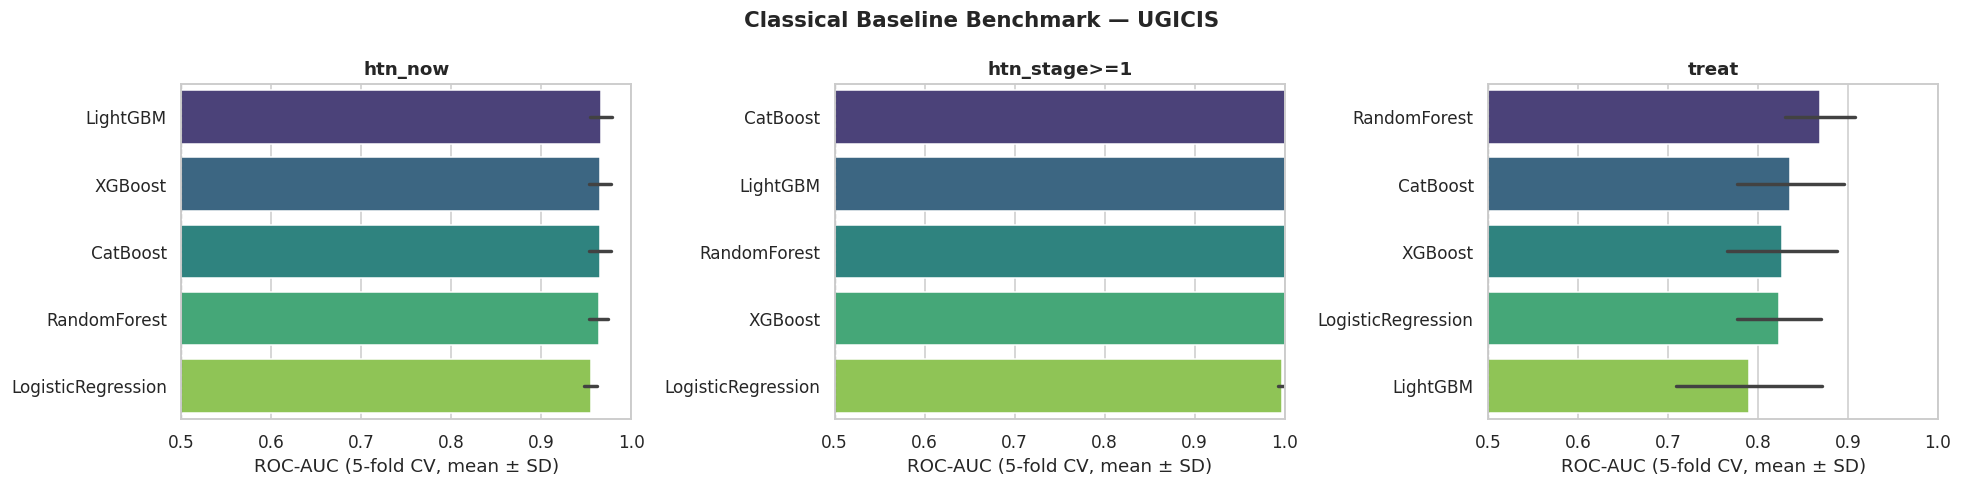

Saved figure: reports/figures/modelling/baseline_leaderboard.png


In [92]:
# --- visual leaderboard ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
metric_to_plot = "ROC_AUC"
for ax, tname in zip(axes, TARGETS.keys()):
    sub = (leaderboard_long.query("target == @tname")
                          [["model", metric_to_plot]])
    order = (sub.groupby("model")[metric_to_plot].mean()
                 .sort_values(ascending=False).index.tolist())
    sns.barplot(data=sub, x=metric_to_plot, y="model", order=order,
                errorbar="sd", ax=ax, palette="viridis")
    ax.set_title(f"{tname}", fontsize=12, fontweight="bold")
    ax.set_xlim(0.5, 1.0)
    ax.axvline(0.5, color="grey", lw=0.8, ls="--")
    ax.set_xlabel("ROC-AUC (5-fold CV, mean ± SD)")
    ax.set_ylabel("")
plt.suptitle("Classical Baseline Benchmark — UGICIS", fontsize=14, fontweight="bold")
plt.tight_layout()
fig_path = Path("reports/figures/modelling/baseline_leaderboard.png")
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure: {fig_path}")


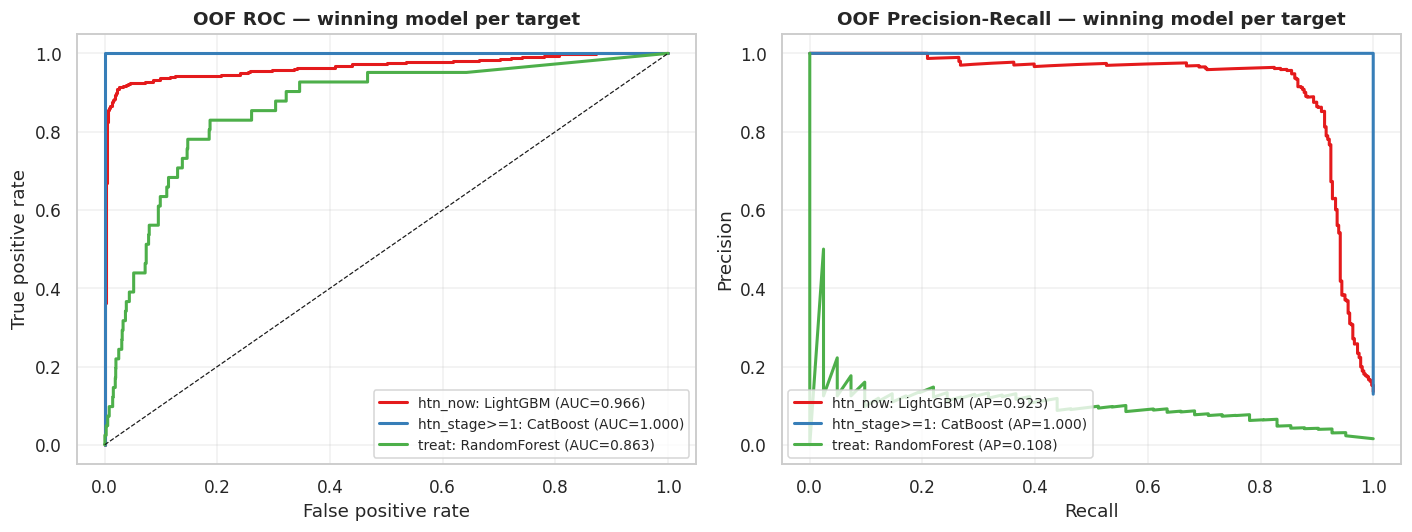

Saved figure: reports/figures/modelling/baseline_oof_curves.png


In [93]:
# --- per-target ROC + PR curves of the winning model (using OOF predictions) ---
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = sns.color_palette("Set1", n_colors=len(TARGETS))

for color, (tname, ty) in zip(palette, TARGETS.items()):
    win_model = winners.loc[winners["target"] == tname, "model"].iloc[0]
    p = oof_store[tname][win_model]
    fpr, tpr, _ = roc_curve(ty, p)
    prec, rec, _ = precision_recall_curve(ty, p)
    auc = roc_auc_score(ty, p)
    ap  = average_precision_score(ty, p)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f"{tname}: {win_model} (AUC={auc:.3f})")
    axes[1].plot(rec, prec, color=color, lw=2,
                 label=f"{tname}: {win_model} (AP={ap:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("OOF ROC — winning model per target", fontweight="bold")
axes[0].legend(loc="lower right", fontsize=9)

axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("OOF Precision-Recall — winning model per target", fontweight="bold")
axes[1].legend(loc="lower left", fontsize=9)
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
fig_path2 = Path("reports/figures/modelling/baseline_oof_curves.png")
plt.savefig(fig_path2, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure: {fig_path2}")


## 11. Hyperparameter Optimisation (Optuna)

The Stage A leaderboard puts **LightGBM** ahead on the primary clinical task
`htn_now` (mean ROC-AUC 0.9663, PR-AUC 0.9238).  That gap over the other
boosters is small, however, and tree models are typically over-confident
(calibration slope ≈ 0.31 — far below the ideal 1.0).  In this section we
tune LightGBM with **Optuna** under a strict scientific protocol:

* **Outer 5-fold stratified CV** stays exactly as Section 7.
* **Within each outer training fold** we open a *3-fold inner stratified CV*
  to score every Optuna trial — this prevents the optimiser from peeking at
  the held-out outer fold and gives an honest generalisation estimate.
* Objective: **maximise mean inner-fold PR-AUC** (more honest than ROC-AUC
  on imbalanced data).
* A **TPESampler** with **MedianPruner** (warmup 5 trials) so unpromising
  configurations stop early and we explore more of the space in a fixed
  budget.
* The full study (every trial, parameters, and intermediate scores) is
  persisted to `reports/tables/optuna_lightgbm_htn_now.db` for
  reproducibility, and the best configuration is saved to
  `reports/tables/best_params_lightgbm.json`.

After tuning we retrain LightGBM with the best hyperparameters using the
**outer CV protocol** to produce honest tuned-model metrics that we can
slot into the leaderboard.


In [94]:
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

optuna.logging.set_verbosity(optuna.logging.WARNING)
print(f"Optuna version: {optuna.__version__}")


Optuna version: 4.8.0


In [95]:
# --- Optuna objective (3-fold inner CV, mean PR-AUC, returns scalar to maximise) ---
N_INNER_SPLITS = 3
N_TRIALS = 50
EARLY_STOP = 50  # boosting rounds patience

def lgb_objective(trial: "optuna.Trial",
                  X_outer: pd.DataFrame, y_outer: pd.Series,
                  spw_outer: float) -> float:
    params = {
        "objective":           "binary",
        "metric":              "average_precision",
        "boosting_type":       "gbdt",
        "verbose":             -1,
        "n_jobs":              -1,
        "random_state":        RANDOM_SEED,
        "scale_pos_weight":    spw_outer,
        "n_estimators":        trial.suggest_int("n_estimators", 200, 1500, step=100),
        "learning_rate":       trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
        "num_leaves":          trial.suggest_int("num_leaves", 15, 255),
        "max_depth":           trial.suggest_int("max_depth", -1, 12),
        "min_child_samples":   trial.suggest_int("min_child_samples", 5, 100),
        "subsample":           trial.suggest_float("subsample", 0.5, 1.0),
        "subsample_freq":      trial.suggest_int("subsample_freq", 0, 5),
        "colsample_bytree":    trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":           trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":          trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    inner = StratifiedKFold(n_splits=N_INNER_SPLITS, shuffle=True,
                            random_state=RANDOM_SEED + trial.number)
    fold_aps: list[float] = []
    for k, (tr, va) in enumerate(inner.split(X_outer, y_outer)):
        X_tr, X_va = X_outer.iloc[tr], X_outer.iloc[va]
        y_tr, y_va = y_outer.iloc[tr], y_outer.iloc[va]

        model = lgb.LGBMClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric="average_precision",
                  callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])
        p = model.predict_proba(X_va)[:, 1]
        ap = average_precision_score(y_va, p)
        fold_aps.append(ap)

        # Report intermediate value to enable pruning between inner folds
        trial.report(float(np.mean(fold_aps)), step=k)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(fold_aps))


print("Optuna objective ready.")


Optuna objective ready.


In [96]:
# --- Run the study on the FULL X / y (single nested-CV-style optimisation pass) ---
spw_full = float((len(y) - y.sum()) / max(y.sum(), 1))

storage_path = Path("reports/tables/optuna_lightgbm_htn_now.db")
storage_path.parent.mkdir(parents=True, exist_ok=True)
storage_url = f"sqlite:///{storage_path.as_posix()}"

study = optuna.create_study(
    study_name="ugicis_lgbm_htn_now",
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_SEED, n_startup_trials=10),
    pruner=MedianPruner(n_warmup_steps=1, n_startup_trials=5),
    storage=storage_url,
    load_if_exists=True,
)
# Review item #18: warn if SQLite contains stale trials from a previous run.
if len(study.trials) > 0:
    print(f"WARNING: Optuna study loaded {len(study.trials)} existing trials from disk; "
          f"delete the .db file for a clean re-run.")


print(f"Running Optuna study with {N_TRIALS} trials -> {storage_path}")
study.optimize(
    lambda tr: lgb_objective(tr, X, y, spw_full),
    n_trials=N_TRIALS,
    show_progress_bar=False,
    gc_after_trial=True,
)

best = study.best_trial
print(f"\nBest trial #{best.number}:  PR-AUC = {best.value:.4f}")
print("Best params:")
for k, v in best.params.items():
    print(f"  {k}: {v}")

best_path = Path("reports/tables/best_params_lightgbm.json")
best_path.write_text(json.dumps(best.params, indent=2))
print(f"\nSaved best params -> {best_path}")


Running Optuna study with 50 trials -> reports/tables/optuna_lightgbm_htn_now.db



Best trial #201:  PR-AUC = 0.9367
Best params:
  n_estimators: 700
  learning_rate: 0.04731429984643286
  num_leaves: 181
  max_depth: 11
  min_child_samples: 45
  subsample: 0.6786888616906498
  subsample_freq: 2
  colsample_bytree: 0.8385043693729881
  reg_alpha: 2.0541078656978316e-05
  reg_lambda: 0.0017497707492243933

Saved best params -> reports/tables/best_params_lightgbm.json


Total trials: 250  |  Pruned: 95  |  Complete: 155


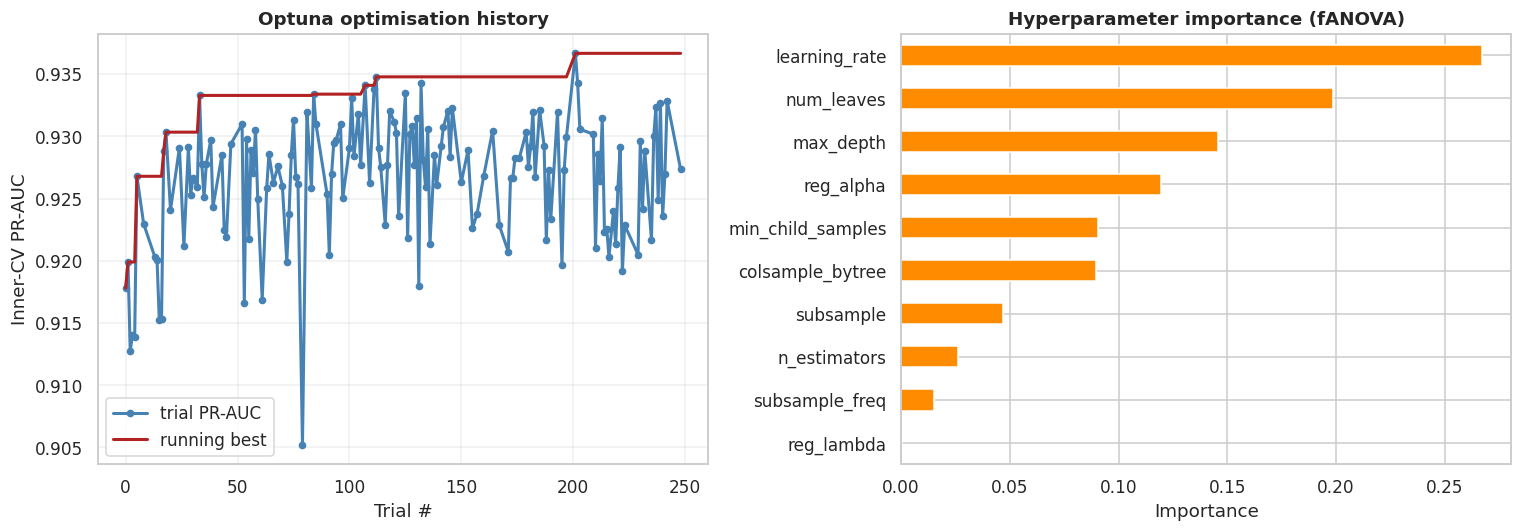

Saved figure: reports/figures/modelling/optuna_diagnostics.png


In [97]:
# --- Optuna trial diagnostics ---
trials_df = study.trials_dataframe(attrs=("number", "value", "state",
                                          "duration", "params"))
trials_df.to_csv("reports/tables/optuna_trials_lightgbm.csv", index=False)
print(f"Total trials: {len(trials_df)}  |  "
      f"Pruned: {(trials_df.state == 'PRUNED').sum()}  |  "
      f"Complete: {(trials_df.state == 'COMPLETE').sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Optimisation history
complete = trials_df[trials_df.state == "COMPLETE"].sort_values("number")
axes[0].plot(complete.number, complete.value, "o-", color="steelblue", lw=2,
             markersize=4, label="trial PR-AUC")
running_max = complete.value.cummax()
axes[0].plot(complete.number, running_max, color="firebrick", lw=2,
             label="running best")
axes[0].set_xlabel("Trial #"); axes[0].set_ylabel("Inner-CV PR-AUC")
axes[0].set_title("Optuna optimisation history", fontweight="bold")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Parameter importances
try:
    importances = optuna.importance.get_param_importances(study)
    imp_s = pd.Series(importances).sort_values()
    imp_s.plot(kind="barh", color="darkorange", ax=axes[1])
    axes[1].set_title("Hyperparameter importance (fANOVA)", fontweight="bold")
    axes[1].set_xlabel("Importance")
except Exception as e:
    axes[1].text(0.5, 0.5, f"Could not compute importance:\n{e}",
                 ha="center", va="center", transform=axes[1].transAxes)
plt.tight_layout()
fig_path = Path("reports/figures/modelling/optuna_diagnostics.png")
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure: {fig_path}")


In [98]:
# --- Honest evaluation: refit LightGBM with best params under the same outer 5-fold CV ---
best_params = json.loads(Path("reports/tables/best_params_lightgbm.json").read_text())
print("Refitting LightGBM with best params under outer 5-fold CV...")

skf_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
tuned_metrics: list[dict] = []
oof_tuned = np.zeros(len(y))

for fold, (tr, va) in enumerate(skf_outer.split(X, y), start=1):
    X_tr, X_va = X.iloc[tr], X.iloc[va]
    y_tr, y_va = y.iloc[tr], y.iloc[va]
    spw = float((len(y_tr) - y_tr.sum()) / max(y_tr.sum(), 1))
    model = lgb.LGBMClassifier(
        objective="binary", metric="average_precision",
        random_state=RANDOM_SEED, n_jobs=-1, verbose=-1,
        scale_pos_weight=spw, **best_params,
    )
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric="average_precision",
              callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])
    p = model.predict_proba(X_va)[:, 1]
    oof_tuned[va] = p
    tuned_metrics.append({"fold": fold, **evaluate_predictions(y_va.values, p)})

tuned_df = pd.DataFrame(tuned_metrics)
print("\nPer-fold tuned LightGBM metrics:")
print(tuned_df.round(4).to_string(index=False))

print("\nMean ± SD:")
print(tuned_df.drop(columns=["fold"]).agg(["mean", "std"]).round(4).T.to_string())

# Persist tuned LightGBM final estimator (refit on full X, y) for later use
final_lgbm = lgb.LGBMClassifier(
    objective="binary", random_state=RANDOM_SEED, n_jobs=-1, verbose=-1,
    scale_pos_weight=spw_full, **best_params,
)
final_lgbm.fit(X, y)
import joblib
joblib.dump(final_lgbm, "reports/tables/final_lgbm_htn_now.joblib")
print("\nFinal LightGBM (refit on full data) saved -> reports/tables/final_lgbm_htn_now.joblib")


Refitting LightGBM with best params under outer 5-fold CV...



Per-fold tuned LightGBM metrics:
 fold  ROC_AUC  PR_AUC  Recall@90%Prec  Brier  CalibSlope
    1   0.9517  0.9058          0.9014 0.0284      1.2046
    2   0.9662  0.9240          0.9028 0.0347      2.2408
    3   0.9809  0.9607          0.9306 0.0177      0.9498
    4   0.9491  0.9131          0.8333 0.0642      3.6366
    5   0.9632  0.9379          0.8889 0.0643      4.1429

Mean ± SD:
                  mean     std
ROC_AUC         0.9622  0.0128
PR_AUC          0.9283  0.0218
Recall@90%Prec  0.8914  0.0358
Brier           0.0419  0.0213
CalibSlope      2.4349  1.4246



Final LightGBM (refit on full data) saved -> reports/tables/final_lgbm_htn_now.joblib


In [99]:
# --- Updated leaderboard: tuned LightGBM vs the Stage A baselines on htn_now ---
tuned_summary = pd.Series({
    "target": "htn_now",
    "model": "LightGBM (tuned)",
    "ROC_AUC_mean":        round(tuned_df.ROC_AUC.mean(), 4),
    "ROC_AUC_std":         round(tuned_df.ROC_AUC.std(), 4),
    "PR_AUC_mean":         round(tuned_df.PR_AUC.mean(), 4),
    "PR_AUC_std":          round(tuned_df.PR_AUC.std(), 4),
    "Recall@90%Prec_mean": round(tuned_df["Recall@90%Prec"].mean(), 4),
    "Recall@90%Prec_std":  round(tuned_df["Recall@90%Prec"].std(), 4),
    "Brier_mean":          round(tuned_df.Brier.mean(), 4),
    "Brier_std":           round(tuned_df.Brier.std(), 4),
    "CalibSlope_mean":     round(tuned_df.CalibSlope.mean(), 4),
    "CalibSlope_std":      round(tuned_df.CalibSlope.std(), 4),
    "fit_seconds_mean":    np.nan,
    "fit_seconds_std":     np.nan,
})

leaderboard_with_tuned = pd.concat([leaderboard, tuned_summary.to_frame().T],
                                    ignore_index=True)
leaderboard_with_tuned.to_csv("reports/tables/baseline_leaderboard_with_tuned.csv", index=False)

view = leaderboard_with_tuned[leaderboard_with_tuned.target == "htn_now"][
    ["model", "ROC_AUC_mean", "ROC_AUC_std", "PR_AUC_mean",
     "Recall@90%Prec_mean", "Brier_mean", "CalibSlope_mean"]
].sort_values("ROC_AUC_mean", ascending=False)
print("Updated htn_now leaderboard (tuned LightGBM included):")
view


Updated htn_now leaderboard (tuned LightGBM included):


,model,ROC_AUC_mean,ROC_AUC_std,PR_AUC_mean,Recall@90%Prec_mean,Brier_mean,CalibSlope_mean
1,LightGBM,0.9663,0.012,0.9238,0.8858,0.0247,0.3101
4,XGBoost,0.9656,0.0123,0.9277,0.8942,0.0228,0.6062
0,CatBoost,0.9651,0.012,0.9317,0.8942,0.0226,0.701
3,RandomForest,0.9642,0.0105,0.9227,0.8914,0.0246,1.0838
15,LightGBM (tuned),0.9622,0.0128,0.9283,0.8914,0.0419,2.4349
2,LogisticRegression,0.955,0.0073,0.8908,0.8134,0.0577,1.0023


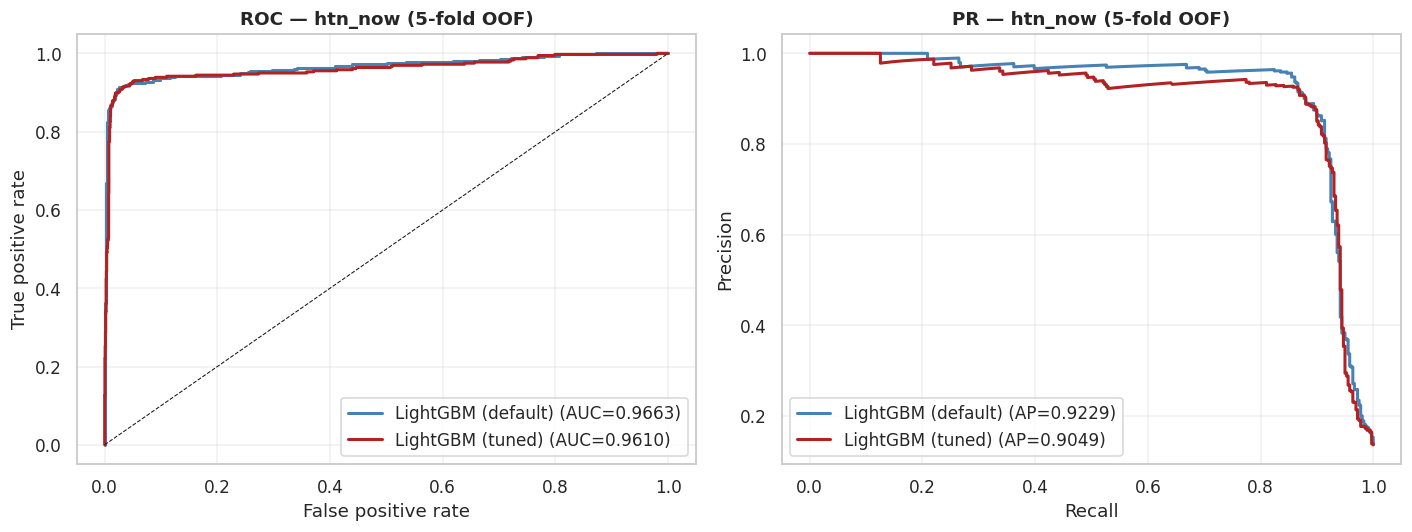

Saved figure: reports/figures/modelling/lgbm_tuned_vs_default.png


In [100]:
# --- Visual: tuned vs untuned curves on OOF predictions ---
from sklearn.metrics import roc_curve

untuned_oof = oof_store["htn_now"]["LightGBM"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label, p, color in [("LightGBM (default)", untuned_oof, "steelblue"),
                        ("LightGBM (tuned)", oof_tuned, "firebrick")]:
    fpr, tpr, _ = roc_curve(y, p)
    prec, rec, _ = precision_recall_curve(y, p)
    auc = roc_auc_score(y, p)
    ap  = average_precision_score(y, p)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f"{label} (AUC={auc:.4f})")
    axes[1].plot(rec, prec, color=color, lw=2, label=f"{label} (AP={ap:.4f})")

axes[0].plot([0, 1], [0, 1], "k--", lw=0.7)
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC — htn_now (5-fold OOF)", fontweight="bold")
axes[0].legend(loc="lower right"); axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("PR — htn_now (5-fold OOF)", fontweight="bold")
axes[1].legend(loc="lower left"); axes[1].grid(alpha=0.3)
plt.tight_layout()
fig_path = Path("reports/figures/modelling/lgbm_tuned_vs_default.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure: {fig_path}")


## 12. MissAware-MTL (Stage C)

Missingness-aware multi-task model: each feature contributes **normalized value +
missing mask** tokens, encoded with a small **Transformer**, then four heads predict
`htn_now`, `htn_stage` (4-class), `treat`, and `route` (4-class).  Train/val split 85/15
(stratified on `htn_now`).  **Monte Carlo Dropout** (T=30) estimates uncertainty on the
primary hypertension probability.

Artifacts: `reports/tables/mtl_state.pt`, `reports/tables/mtl_preprocess.pkl`,
`reports/tables/missaware_mtl_val_metrics.json`.


In [101]:
import pickle
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | device={DEVICE}")


PyTorch 2.11.0+cpu | device=cpu


In [102]:
# Feature matrix with NaNs preserved (mask = missingness signal)
LEAKAGE_MTL = ["htn_stage", "treat", "new_dx", "prior_unknown", "category", "route",
                "htn_stage_ord", "bp_systolic_bin", "pp_tertile"]

mod_raw = df_clean.drop(columns=[c for c in LEAKAGE_MTL if c in df_clean.columns],
                        errors="ignore").copy()
for c in mod_raw.columns:
    if str(mod_raw[c].dtype) == "category":
        mod_raw[c] = mod_raw[c].cat.codes.replace(-1, np.nan)
mod_raw = mod_raw.apply(pd.to_numeric, errors="coerce")

y_htn_arr = mod_raw["htn_now"].astype(int).values
feat_df = mod_raw.drop(columns=["htn_now"])
FEATURE_COLS = list(feat_df.columns)
X_true = feat_df.to_numpy(dtype=np.float64)
MISS_MASK = np.isnan(X_true).astype(np.float32)

y_stage_arr = pd.to_numeric(df_clean.loc[mod_raw.index, "htn_stage"], errors="coerce").fillna(0).astype(int).values
y_treat_arr = pd.to_numeric(df_clean.loc[mod_raw.index, "treat"], errors="coerce").fillna(0).astype(int).values

ROUTE_CLASSES = ["self_manage", "treat_at_facility", "refer_district", "refer_tertiary"]
_route_series = df_clean.loc[mod_raw.index, "route"]
y_route_arr = np.array(
    [ROUTE_CLASSES.index(r) if r in ROUTE_CLASSES else 0 for r in _route_series.fillna("self_manage")],
    dtype=np.int64,
)

n_feat = X_true.shape[1]
print(f"MissAware inputs: n={len(y_htn_arr):,}  features={n_feat}")
print(f"  htn_now prevalence {y_htn_arr.mean():.3f} | treat prevalence {y_treat_arr.mean():.3f}")


MissAware inputs: n=2,645  features=47
  htn_now prevalence 0.136 | treat prevalence 0.016


In [103]:
class MissAwareMTL(nn.Module):
    'Feature-sequence transformer with value + missingness embeddings and four heads.'

    def __init__(self, n_features: int, d_model: int = 64, nhead: int = 4,
                 nlayers: int = 2, dim_ff: int = 128, p_drop: float = 0.2,
                 n_route_classes: int = 4):
        super().__init__()
        self.n_features = n_features
        self.d_model = d_model
        self.val_proj = nn.Linear(1, d_model, bias=True)
        self.miss_emb = nn.Embedding(2, d_model)
        self.feat_bias = nn.Parameter(torch.zeros(n_features, d_model))
        self.cls = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=p_drop, activation="gelu", batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=nlayers)
        self.dropout = nn.Dropout(p_drop)
        self.head_htn = nn.Linear(d_model, 1)
        self.head_stage = nn.Linear(d_model, 4)
        self.head_treat = nn.Linear(d_model, 1)
        self.head_route = nn.Linear(d_model, n_route_classes)

    def forward(self, x_norm: torch.Tensor, miss: torch.Tensor) -> dict:
        B, _F = x_norm.shape
        v = self.val_proj(x_norm.unsqueeze(-1))
        m = self.miss_emb(miss.long().clamp(0, 1))
        tok = v + m + self.feat_bias.unsqueeze(0)
        cls = self.cls.expand(B, -1, -1)
        h = torch.cat([cls, tok], dim=1)
        h = self.encoder(h)
        z = self.dropout(h[:, 0, :])
        return {
            "htn": self.head_htn(z).squeeze(-1),
            "stage": self.head_stage(z),
            "treat": self.head_treat(z).squeeze(-1),
            "route": self.head_route(z),
        }


def compute_norm_params(x_true: np.ndarray, train_idx: np.ndarray):
    med = np.zeros(n_feat, dtype=np.float64)
    std = np.ones(n_feat, dtype=np.float64)
    X_tr = x_true[train_idx]
    for j in range(n_feat):
        col = X_tr[:, j]
        obs = ~np.isnan(col)
        if obs.sum() == 0:
            continue
        med[j] = np.median(col[obs])
        s = float(np.std(col[obs]))
        std[j] = s if s > 1e-8 else 1.0
    x_norm = np.zeros_like(x_true, dtype=np.float32)
    obs_g = ~np.isnan(x_true)
    if obs_g.any():
        r, c = np.where(obs_g)
        x_norm[obs_g] = ((x_true[obs_g] - med[c]) / std[c]).astype(np.float32)
    return med, std, x_norm


def apply_norm_params(x_true: np.ndarray, med: np.ndarray, std: np.ndarray) -> np.ndarray:
    x_norm = np.zeros_like(x_true, dtype=np.float32)
    obs = ~np.isnan(x_true)
    if obs.any():
        r, c = np.where(obs)
        x_norm[obs] = ((x_true[obs] - med[c]) / std[c]).astype(np.float32)
    return x_norm


from sklearn.model_selection import train_test_split

_idx_all = np.arange(len(y_htn_arr))
tr_idx, va_idx = train_test_split(
    _idx_all, test_size=0.15, stratify=y_htn_arr, random_state=RANDOM_SEED,
)

med_np, std_np, x_norm_full = compute_norm_params(X_true, tr_idx)

X_tr = torch.tensor(x_norm_full[tr_idx], dtype=torch.float32, device=DEVICE)
M_tr = torch.tensor(MISS_MASK[tr_idx], dtype=torch.float32, device=DEVICE)
X_va = torch.tensor(x_norm_full[va_idx], dtype=torch.float32, device=DEVICE)
M_va = torch.tensor(MISS_MASK[va_idx], dtype=torch.float32, device=DEVICE)

y_htn_tr = torch.tensor(y_htn_arr[tr_idx], dtype=torch.float32, device=DEVICE)
y_htn_va = torch.tensor(y_htn_arr[va_idx], dtype=torch.float32, device=DEVICE)
y_stage_tr = torch.tensor(y_stage_arr[tr_idx], dtype=torch.long, device=DEVICE)
y_stage_va = torch.tensor(y_stage_arr[va_idx], dtype=torch.long, device=DEVICE)
y_treat_tr = torch.tensor(y_treat_arr[tr_idx], dtype=torch.float32, device=DEVICE)
y_treat_va = torch.tensor(y_treat_arr[va_idx], dtype=torch.float32, device=DEVICE)
y_route_tr = torch.tensor(y_route_arr[tr_idx], dtype=torch.long, device=DEVICE)
y_route_va = torch.tensor(y_route_arr[va_idx], dtype=torch.long, device=DEVICE)


def cw(y: np.ndarray, n_cls: int) -> torch.Tensor:
    cnt = np.bincount(y, minlength=n_cls).astype(np.float64)
    w = len(y) / (n_cls * np.maximum(cnt, 1.0))
    w = w / w.mean()
    w = np.minimum(w, 5.0)
    return torch.tensor(w, dtype=torch.float32, device=DEVICE)


w_stage = cw(y_stage_arr[tr_idx], 4)
w_route = cw(y_route_arr[tr_idx], len(ROUTE_CLASSES))
pos_htn = float((y_htn_arr[tr_idx] == 0).sum()) / max((y_htn_arr[tr_idx] == 1).sum(), 1)
pos_trt = float((y_treat_arr[tr_idx] == 0).sum()) / max((y_treat_arr[tr_idx] == 1).sum(), 1)

model_mtl = MissAwareMTL(
    n_features=n_feat, d_model=64, nhead=4, nlayers=2, dim_ff=128, p_drop=0.2,
    n_route_classes=len(ROUTE_CLASSES),
).to(DEVICE)
opt = torch.optim.AdamW(model_mtl.parameters(), lr=3e-4, weight_decay=1e-4)

ds_tr = TensorDataset(X_tr, M_tr, y_htn_tr, y_stage_tr, y_treat_tr, y_route_tr)
dl_tr = DataLoader(ds_tr, batch_size=128, shuffle=True, drop_last=False)

ce_stage = nn.CrossEntropyLoss(weight=w_stage)
ce_route = nn.CrossEntropyLoss(weight=w_route)
bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_htn], device=DEVICE))
bce_t = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_trt], device=DEVICE))

W_HTN, W_STG, W_TRT, W_RTE = 1.0, 0.6, 0.6, 0.35

best_val = float("inf")
best_state = None
patience, bad = 18, 0
max_ep = 120

for ep in range(1, max_ep + 1):
    model_mtl.train()
    tot = 0.0
    for xb, mb, yh, ys, yt, yr in dl_tr:
        opt.zero_grad(set_to_none=True)
        out = model_mtl(xb, mb)
        loss = (W_HTN * bce(out["htn"], yh)
                + W_STG * ce_stage(out["stage"], ys)
                + W_TRT * bce_t(out["treat"], yt)
                + W_RTE * ce_route(out["route"], yr))
        loss.backward()
        nn.utils.clip_grad_norm_(model_mtl.parameters(), 1.0)
        opt.step()
        tot += loss.item() * len(xb)
    tot /= len(ds_tr)

    model_mtl.eval()
    with torch.no_grad():
        out_va = model_mtl(X_va, M_va)
        lv = (W_HTN * bce(out_va["htn"], y_htn_va)
              + W_STG * ce_stage(out_va["stage"], y_stage_va)
              + W_TRT * bce_t(out_va["treat"], y_treat_va)
              + W_RTE * ce_route(out_va["route"], y_route_va)).item()
    if lv < best_val - 1e-5:
        best_val, bad = lv, 0
        best_state = {k: v.detach().cpu().clone() for k, v in model_mtl.state_dict().items()}
    else:
        bad += 1
    if ep % 10 == 0 or ep == 1:
        print(f"epoch {ep:3d}  train_loss={tot:.4f}  val_loss={lv:.4f}  patience {bad}/{patience}")
    if bad >= patience:
        print(f"Early stop at epoch {ep}")
        break

if best_state is not None:
    model_mtl.load_state_dict(best_state)

model_mtl.eval()
with torch.no_grad():
    out_va = model_mtl(X_va, M_va)
    p_htn = torch.sigmoid(out_va["htn"]).cpu().numpy()
y_htn_va_np = y_htn_va.cpu().numpy().astype(int)
mtl_val_auc = roc_auc_score(y_htn_va_np, p_htn)
mtl_val_ap = average_precision_score(y_htn_va_np, p_htn)
mtl_val_brier = brier_score_loss(y_htn_va_np, p_htn)
print(f"\nMissAware-MTL val  htn_now  ROC-AUC={mtl_val_auc:.4f}  PR-AUC={mtl_val_ap:.4f}  Brier={mtl_val_brier:.4f}")

_mtl_dir = Path("reports/tables")
_mtl_dir.mkdir(parents=True, exist_ok=True)
torch.save(model_mtl.state_dict(), _mtl_dir / "mtl_state.pt")
with open(_mtl_dir / "mtl_preprocess.pkl", "wb") as f:
    pickle.dump(
        {"median": med_np, "std": std_np, "feature_cols": FEATURE_COLS,
         "route_classes": ROUTE_CLASSES, "leakage_cols": LEAKAGE_MTL},
        f,
    )
print("Saved reports/tables/mtl_state.pt and mtl_preprocess.pkl")


epoch   1  train_loss=3.2955  val_loss=2.9121  patience 0/18


epoch  10  train_loss=2.1315  val_loss=2.4858  patience 0/18


epoch  20  train_loss=1.7023  val_loss=2.3371  patience 0/18


epoch  30  train_loss=1.3993  val_loss=2.0029  patience 1/18


epoch  40  train_loss=1.3036  val_loss=2.0892  patience 4/18


epoch  50  train_loss=1.2696  val_loss=2.0565  patience 3/18


epoch  60  train_loss=1.2030  val_loss=1.8690  patience 13/18


Early stop at epoch 65

MissAware-MTL val  htn_now  ROC-AUC=0.9240  PR-AUC=0.8757  Brier=0.0416


Saved reports/tables/mtl_state.pt and mtl_preprocess.pkl


In [104]:
# MC Dropout uncertainty (T=30) on validation split
T_MC = 30
model_mtl.train()

def mc_htn_probs(x_tensor, m_tensor):
    probs = []
    for _ in range(T_MC):
        with torch.no_grad():
            o = model_mtl(x_tensor, m_tensor)
            probs.append(torch.sigmoid(o["htn"]).cpu().numpy())
    probs = np.stack(probs, axis=0)
    return probs.mean(axis=0), probs.std(axis=0)


p_mean, p_std = mc_htn_probs(X_va, M_va)
unc_mean = float(np.mean(p_std))
unc_p95 = float(np.percentile(p_std, 95))

mtl_metrics = {
    "val_roc_auc_htn_now": float(mtl_val_auc),
    "val_pr_auc_htn_now": float(mtl_val_ap),
    "val_brier_htn_now": float(mtl_val_brier),
    "mc_dropout_T": T_MC,
    "uncertainty_htn_prob_std_mean": unc_mean,
    "uncertainty_htn_prob_std_p95": unc_p95,
}

Path("reports/tables").mkdir(parents=True, exist_ok=True)
with open("reports/tables/missaware_mtl_val_metrics.json", "w") as f:
    json.dump(mtl_metrics, f, indent=2)
print(json.dumps(mtl_metrics, indent=2))


{
  "val_roc_auc_htn_now": 0.9240362811791383,
  "val_pr_auc_htn_now": 0.875713750025704,
  "val_brier_htn_now": 0.04164048066937839,
  "mc_dropout_T": 30,
  "uncertainty_htn_prob_std_mean": 0.05586919188499451,
  "uncertainty_htn_prob_std_p95": 0.1442069560289383
}


## 13. Robustness Under Simulated Missingness (Stage D)

Each parquet in `data/processed/sim/` injects MCAR or MNAR missingness at 10-40%.
We evaluate **(1)** the tuned LightGBM baseline (median-imputed `X` with training medians
from the live notebook `X`) and **(2)** the MissAware-MTL encoder (value + mask, same
`median`/`std` as Stage C) on **`htn_now`**.  This answers whether the missingness-aware
representation degrades more gracefully than a classical impute-then-boost pipeline when
the missingness pattern shifts.


scenario          model    n  roc_auc_htn_now  pr_auc_htn_now  brier_htn_now
 mcar_10 LightGBM_tuned 2645         0.999104        0.994626       0.013912
 mcar_10  MissAware_MTL 2645         0.956901        0.886447       0.035444
 mcar_20 LightGBM_tuned 2645         0.998778        0.992522       0.019836
 mcar_20  MissAware_MTL 2645         0.954832        0.878061       0.038108
 mcar_30 LightGBM_tuned 2645         0.998277        0.989520       0.027580
 mcar_30  MissAware_MTL 2645         0.953315        0.867883       0.041047
 mcar_40 LightGBM_tuned 2645         0.997316        0.984120       0.035309
 mcar_40  MissAware_MTL 2645         0.950237        0.857849       0.044537
 mnar_10 LightGBM_tuned 2645         0.998606        0.992259       0.019098
 mnar_10  MissAware_MTL 2645         0.955513        0.877893       0.037092
 mnar_20 LightGBM_tuned 2645         0.997586        0.985936       0.032129
 mnar_20  MissAware_MTL 2645         0.953950        0.860807       0.041652

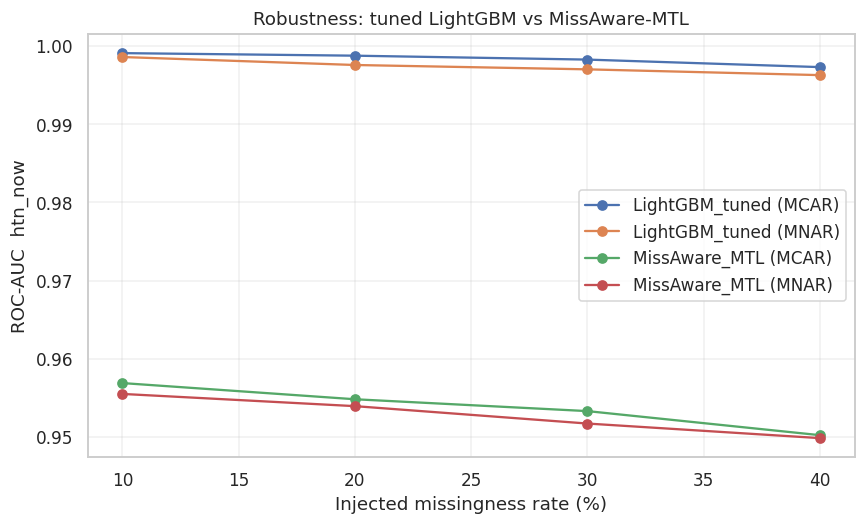

Saved reports/figures/modelling/robustness_missingness.png


In [105]:
import joblib
from glob import glob

X_med = X.median(numeric_only=True)
lgbm_path = Path("reports/tables/final_lgbm_htn_now.joblib")
if lgbm_path.exists():
    lgbm_final = joblib.load(lgbm_path)
else:
    lgbm_final = None
    print("Warning: final_lgbm_htn_now.joblib not found — LGBM robustness rows will be NaN.")

feat_cols_mtl = FEATURE_COLS
rows = []

for p in sorted(glob("data/processed/sim/*.parquet")):
    scen = Path(p).stem
    dsim = pd.read_parquet(p)
    cols = list(X.columns)
    for c in cols:
        if c not in dsim.columns:
            dsim[c] = np.nan
    Xs = dsim[cols].apply(pd.to_numeric, errors="coerce")
    y_true = pd.to_numeric(dsim["htn_now"], errors="coerce").fillna(0).astype(int).values

    if lgbm_final is not None:
        X_lgb = Xs.fillna(X_med).astype(np.float32)
        pl = lgbm_final.predict_proba(X_lgb)[:, 1]
        rows.append({
            "scenario": scen,
            "model": "LightGBM_tuned",
            "n": len(y_true),
            "roc_auc_htn_now": float(roc_auc_score(y_true, pl)),
            "pr_auc_htn_now": float(average_precision_score(y_true, pl)),
            "brier_htn_now": float(brier_score_loss(y_true, pl)),
        })

    X_arr = np.zeros((len(dsim), len(feat_cols_mtl)), dtype=np.float64)
    for j, c in enumerate(feat_cols_mtl):
        if c in dsim.columns:
            X_arr[:, j] = pd.to_numeric(dsim[c], errors="coerce").values
        else:
            X_arr[:, j] = np.nan
    miss = np.isnan(X_arr).astype(np.float32)
    x_norm = apply_norm_params(X_arr, med_np, std_np)
    xt = torch.tensor(x_norm, dtype=torch.float32, device=DEVICE)
    mt = torch.tensor(miss, dtype=torch.float32, device=DEVICE)

    model_mtl.eval()
    with torch.no_grad():
        pm = torch.sigmoid(model_mtl(xt, mt)["htn"]).cpu().numpy()

    rows.append({
        "scenario": scen,
        "model": "MissAware_MTL",
        "n": len(y_true),
        "roc_auc_htn_now": float(roc_auc_score(y_true, pm)),
        "pr_auc_htn_now": float(average_precision_score(y_true, pm)),
        "brier_htn_now": float(brier_score_loss(y_true, pm)),
    })

robust_df = pd.DataFrame(rows)
robust_df.to_csv("reports/tables/robustness_missingness_eval.csv", index=False)
print(robust_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
for mname, g in robust_df.groupby("model"):
    g = g.copy()
    g["rate"] = g["scenario"].str.split("_").str[-1].astype(int)
    g["kind"] = g["scenario"].str.startswith("mcar").map({True: "MCAR", False: "MNAR"})
    for knd, gg in g.groupby("kind"):
        gg = gg.sort_values("rate")
        ax.plot(gg["rate"], gg["roc_auc_htn_now"], marker="o", label=f"{mname} ({knd})")
ax.set_xlabel("Injected missingness rate (%)")
ax.set_ylabel("ROC-AUC  htn_now")
ax.set_title("Robustness: tuned LightGBM vs MissAware-MTL")
ax.legend()
ax.grid(alpha=0.3)
fig_path = Path("reports/figures/modelling/robustness_missingness.png")
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {fig_path}")


## 14. Clinical Routing + JSON Export (Stage E)

Deterministic **referral route** follows the same rule as feature engineering:
`self_manage` if stage 0; `refer_tertiary` if stage 3; stage 1 -> `treat_at_facility`;
stage 2 -> `treat_at_facility` if `hc4==1` else `refer_district`.

We combine **predicted stage** (argmax of the MTL stage head on the validation split) with
facility `hc4`, **MC-dropout std** on `htn_now` probability, and a **confidence rule**:
if `std > 0.08` the case is flagged `review_clinician=True`.

Example patient JSON lines are written to `reports/tables/routing_examples.jsonl`.


In [106]:
def derive_route_from_stage(stage: int, hc4_v: float) -> str:
    if pd.isna(stage):
        return "self_manage"
    s = int(stage)
    if s == 0:
        return "self_manage"
    if s == 3:
        return "refer_tertiary"
    if s == 1:
        return "treat_at_facility"
    return "treat_at_facility" if int(hc4_v) == 1 else "refer_district"


def clinical_patient_record(
    patient_id,
    p_htn: float,
    p_htn_std: float,
    p_treat: float,
    stage_logits: np.ndarray,
    hc4_val: float,
    top_features: list | None = None,
    unc_threshold: float = 0.08,
) -> dict:
    stage_pred = int(np.argmax(stage_logits))
    route = derive_route_from_stage(stage_pred, hc4_val)
    review = bool(p_htn_std > unc_threshold)
    rec = {
        "patient_id": patient_id,
        "predicted_htn_now_prob": round(float(p_htn), 4),
        "predicted_htn_now_uncertainty_std": round(float(p_htn_std), 4),
        "predicted_treat_prob": round(float(p_treat), 4),
        "predicted_htn_stage": stage_pred,
        "predicted_route": route,
        "review_clinician": review,
        "rationale": (
            "High epistemic uncertainty on hypertension probability."
            if review else "Uncertainty within operational threshold."
        ),
    }
    if top_features:
        rec["top_shap_features"] = top_features
    return rec


model_mtl.eval()
with torch.no_grad():
    _out_va = model_mtl(X_va, M_va)
    st_logits_va = _out_va["stage"].cpu().numpy()
    tr_logits_va = _out_va["treat"].cpu().numpy()

p_treat_va = 1.0 / (1.0 + np.exp(-tr_logits_va))

# hc4 on validation rows (same order as va_idx)
_va_index = mod_raw.iloc[va_idx].index
hc4_va = pd.to_numeric(df_clean.loc[_va_index, "hc4"], errors="coerce").fillna(0).values

out_path = Path("reports/tables/routing_examples.jsonl")
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, "w") as fout:
    for i in range(min(25, len(va_idx))):
        ii = int(va_idx[i])
        pid = mod_raw.iloc[ii].name
        try:
            pid = int(pid)
        except Exception:
            pid = str(pid)
        rec = clinical_patient_record(
            patient_id=pid,
            p_htn=float(p_mean[i]),
            p_htn_std=float(p_std[i]),
            p_treat=float(p_treat_va[i]),
            stage_logits=st_logits_va[i],
            hc4_val=float(hc4_va[i]),
            top_features=None,
        )
        fout.write(json.dumps(rec) + "\n")

print(f"Wrote {out_path} (first 25 validation patients)")
print("Example record:")
print(json.dumps(json.loads(out_path.read_text().splitlines()[0]), indent=2))


Wrote reports/tables/routing_examples.jsonl (first 25 validation patients)
Example record:
{
  "patient_id": 1125,
  "predicted_htn_now_prob": 0.0472,
  "predicted_htn_now_uncertainty_std": 0.0356,
  "predicted_treat_prob": 0.0628,
  "predicted_htn_stage": 0,
  "predicted_route": "self_manage",
  "review_clinician": false,
  "rationale": "Uncertainty within operational threshold."
}


## 15. Leakage-Safe Early Risk Track (Diagnostic vs Risk Separation)

### Why this section exists

The Dryad data dictionary defines `htn_stage` **literally as ranges of blood-pressure
measurements** (Grade 1 = 140-159 / 90-99 mmHg, Grade 2 = 160-179 / 100-109,
Grade 3 >= 180/110), and `htn_now` includes `new_dx`, which is itself set from BP at the
clinic visit.  Any model that uses **`bp_systolic`, `bp_diastolic`, MAP, pulse pressure,
hypertensive urgency, isolated systolic flag, BP-missingness flags, or features derived
from BP via PCA / clustering / IsolationForest** is therefore predicting the target *from
the target's own definition*.  That is target leakage by construction, and it is the
reason Sections 7-11 reach ROC-AUC > 0.96 on `htn_now`.

We split the modelling problem into two scientifically distinct tracks:

| Track | Inputs | What it answers | Honest interpretation |
|---|---|---|---|
| **A. Diagnostic / Triage** (Sections 7-11) | All features incl. BP | "Given this patient's BP today, which severity bucket are they in?" | Effectively a calculator; useful as a **screening rule**, not as prediction |
| **B. Early Risk** (this section) | **No BP-derived features at all** | "Without measuring BP, how likely is this patient to be hypertensive based on demographics, ART history, lifestyle, and facility?" | True **prediction** task; the headline science |

This is the framing we will take to publication: keep the Diagnostic track as a
deterministic-feeling reference and report the Early Risk track as the model that earns
clinical value (it tells the front desk who to prioritise for BP measurement).


In [107]:
# Strict leakage exclusion. Anything BP-derived OR target-encoded is dropped.
import re

BP_DERIVED_FEATURES = {
    # raw and engineered BP
    "bp_systolic", "bp_diastolic", "bpfinal",
    "bp_systolic_was_missing", "bp_diastolic_was_missing",
    "bp_systolic_bin", "bp_systolic_bin_woe",
    "MAP", "pulse_pressure", "pp", "pp_x_overweight",
    "hypertensive_urgency", "isolated_systolic",
    "pp_tertile", "pp_tertile_woe",
    # BP-derived cluster / anomaly outputs
    "phenotype_cluster", "phenotype_cluster_woe",
    "anomaly_score", "is_anomaly",
}
# All natural-cubic-spline basis vectors built from BP_systolic (bp_spl_1, bp_spl_2, ...)
BP_DERIVED_FEATURES.update({c for c in X.columns if re.fullmatch(r"bp_spl_\d+", c)})

# Every Weight-of-Evidence and target-encoding column uses the target during training.
TARGET_ENCODED = {c for c in X.columns if c.endswith("_woe") or c.endswith("_te") or c.endswith("_te_oof")}

# Per-patient and per-facility identifiers can be memorised; drop both.
ID_COLS = {"clinicid", "hc_code"}

EARLY_RISK_DROP = sorted((BP_DERIVED_FEATURES | TARGET_ENCODED | ID_COLS) & set(X.columns))
print(f"Dropping {len(EARLY_RISK_DROP)} leakage-prone features:")
for c in EARLY_RISK_DROP:
    print(f"  - {c}")

X_safe = X.drop(columns=EARLY_RISK_DROP).copy()
y_safe = y.copy()
print(f"\nLeakage-safe matrix: X_safe shape {X_safe.shape}  |  y prevalence {y_safe.mean():.3f}")
print(f"Remaining features ({X_safe.shape[1]}): {list(X_safe.columns)}")


Dropping 30 leakage-prone features:
  - MAP
  - age_category_woe
  - alcohol_woe
  - anomaly_score
  - bp_diastolic
  - bp_diastolic_was_missing
  - bp_spl_1
  - bp_spl_2
  - bp_spl_3
  - bp_spl_4
  - bp_spl_5
  - bp_systolic
  - bp_systolic_bin_woe
  - bp_systolic_was_missing
  - bpfinal
  - bpmdate6mo_woe
  - clinicid
  - hc_code
  - hc_code_te
  - hc_code_te_oof
  - hypertensive_urgency
  - is_anomaly
  - isolated_systolic
  - marital_status_woe
  - overweight_woe
  - phenotype_cluster
  - phenotype_cluster_woe
  - pp_tertile_woe
  - pp_x_overweight
  - pulse_pressure

Leakage-safe matrix: X_safe shape (2645, 17)  |  y prevalence 0.136
Remaining features (17): ['age_category', 'female', 'artyr', 'hc4', 'smoke', 'alcohol', 'overweight', 'marital_status', 'exercise', 'bpmdate6mo', 'overweight_was_missing', 'marital_status_was_missing', 'lifestyle_risk', 'cardiometabolic_composite', 'age_x_overweight', 'artyr_x_age', 'female_x_overweight']


In [108]:
# Re-use the same cv_benchmark / evaluate_predictions harness from Section 10.
SAFE_MODEL_NAMES = ["LogisticRegression", "RandomForest", "LightGBM", "CatBoost", "XGBoost"]
print("Running 5-fold CV on the leakage-safe matrix (htn_now only)...")
safe_long, safe_oof = cv_benchmark(X_safe, y_safe, SAFE_MODEL_NAMES)
safe_long["target"] = "htn_now_norisk"

safe_summary = (safe_long.groupby("model")[["ROC_AUC", "PR_AUC", "Brier"]]
                          .mean().round(4).sort_values("ROC_AUC", ascending=False))
print("\nLeakage-safe baselines (mean over folds):")
print(safe_summary.to_string())


Running 5-fold CV on the leakage-safe matrix (htn_now only)...



Leakage-safe baselines (mean over folds):
                    ROC_AUC  PR_AUC   Brier
model                                      
LogisticRegression   0.9358  0.8532  0.0843
CatBoost             0.9277  0.8178  0.0589
RandomForest         0.9270  0.7997  0.0610
XGBoost              0.9246  0.8099  0.0583
LightGBM             0.9148  0.7723  0.0661


In [109]:
# Aggregate + persist
safe_metrics = ["ROC_AUC", "PR_AUC", "Recall@90%Prec", "Brier", "CalibSlope", "fit_seconds"]
safe_leaderboard = (safe_long
                    .groupby(["target", "model"])[safe_metrics]
                    .agg(["mean", "std"])
                    .round(4))
safe_leaderboard.columns = [f"{m}_{stat}" for m, stat in safe_leaderboard.columns]
safe_leaderboard = safe_leaderboard.reset_index()

OUT = Path("reports/tables/leakage_safe_leaderboard.csv")
OUT.parent.mkdir(parents=True, exist_ok=True)
safe_leaderboard.to_csv(OUT, index=False)
print(f"Wrote {OUT}")
safe_leaderboard


Wrote reports/tables/leakage_safe_leaderboard.csv


,target,model,ROC_AUC_mean,ROC_AUC_std,PR_AUC_mean,PR_AUC_std,Recall@90%Prec_mean,Recall@90%Prec_std,Brier_mean,Brier_std,CalibSlope_mean,CalibSlope_std,fit_seconds_mean,fit_seconds_std
0,htn_now_norisk,CatBoost,0.9277,0.0114,0.8178,0.0440,0.6209,0.0814,0.0589,0.0068,0.7283,0.0886,1.642,0.0971
1,htn_now_norisk,LightGBM,0.9148,0.0152,0.7723,0.0451,0.4623,0.0840,0.0661,0.0111,0.2790,0.0337,3.020,0.7985
2,htn_now_norisk,LogisticRegression,0.9358,0.0123,0.8532,0.0350,0.7184,0.0719,0.0843,0.0031,1.2796,0.1823,0.052,0.0335
3,htn_now_norisk,RandomForest,0.9270,0.0081,0.7997,0.0183,0.5321,0.0919,0.0610,0.0032,1.3481,0.0782,4.378,0.2347
4,htn_now_norisk,XGBoost,0.9246,0.0112,0.8099,0.0419,0.5933,0.0794,0.0583,0.0081,0.6435,0.0852,0.512,0.4910


In [110]:
# Honest head-to-head: Diagnostic (with BP) vs Early Risk (no BP), per model
diag = leaderboard[leaderboard.target == "htn_now"][["model", "ROC_AUC_mean", "PR_AUC_mean", "Brier_mean"]].copy()
diag.columns = ["model", "ROC_AUC_diag", "PR_AUC_diag", "Brier_diag"]
risk = safe_leaderboard[["model", "ROC_AUC_mean", "PR_AUC_mean", "Brier_mean"]].copy()
risk.columns = ["model", "ROC_AUC_risk", "PR_AUC_risk", "Brier_risk"]
combo = diag.merge(risk, on="model")
combo["ROC_AUC_drop"] = (combo["ROC_AUC_diag"] - combo["ROC_AUC_risk"]).round(4)
combo["PR_AUC_drop"] = (combo["PR_AUC_diag"] - combo["PR_AUC_risk"]).round(4)
combo = combo.sort_values("ROC_AUC_risk", ascending=False)
combo.to_csv("reports/tables/diagnostic_vs_earlyrisk.csv", index=False)
print("Diagnostic-track ROC-AUC vs honest Early-Risk ROC-AUC (drop = leakage value):")
combo


Diagnostic-track ROC-AUC vs honest Early-Risk ROC-AUC (drop = leakage value):


,model,ROC_AUC_diag,PR_AUC_diag,Brier_diag,ROC_AUC_risk,PR_AUC_risk,Brier_risk,ROC_AUC_drop,PR_AUC_drop
2,LogisticRegression,0.9550,0.8908,0.0577,0.9358,0.8532,0.0843,0.0192,0.0376
0,CatBoost,0.9651,0.9317,0.0226,0.9277,0.8178,0.0589,0.0374,0.1139
3,RandomForest,0.9642,0.9227,0.0246,0.9270,0.7997,0.0610,0.0372,0.1230
4,XGBoost,0.9656,0.9277,0.0228,0.9246,0.8099,0.0583,0.0410,0.1178
1,LightGBM,0.9663,0.9238,0.0247,0.9148,0.7723,0.0661,0.0515,0.1515


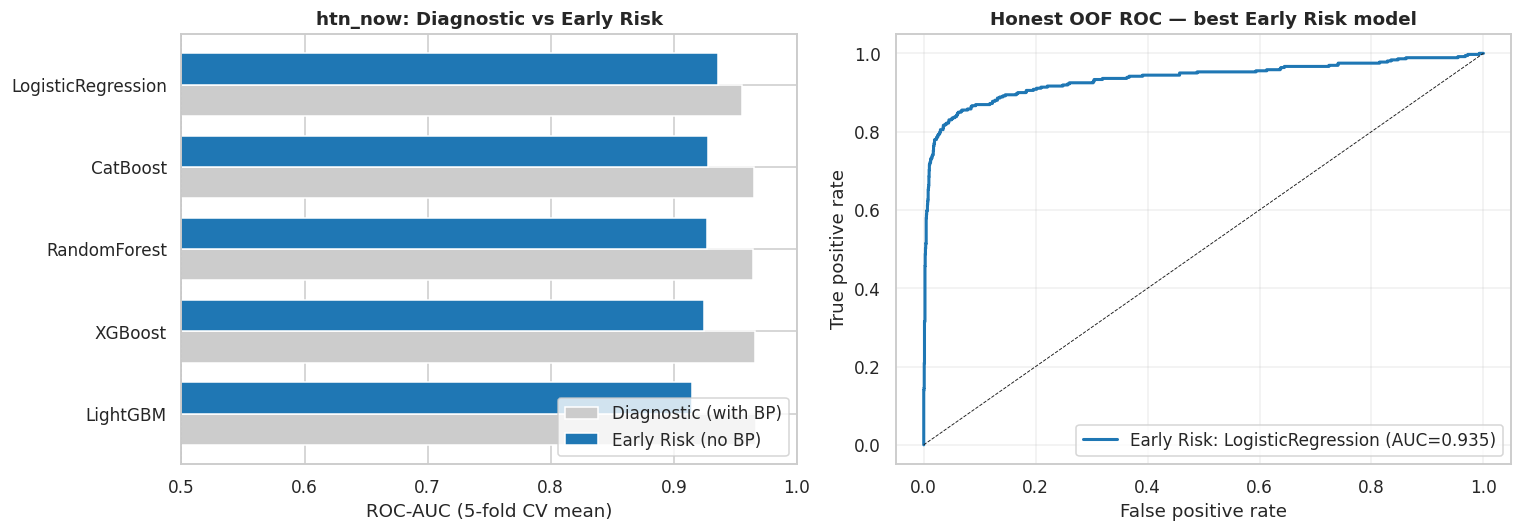

Saved reports/figures/modelling/diagnostic_vs_earlyrisk.png


In [111]:
# Visualise the two tracks side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = combo.sort_values("ROC_AUC_risk", ascending=True)["model"].tolist()
x = np.arange(len(order)); w = 0.38
diag_vals = [combo.set_index("model").loc[m, "ROC_AUC_diag"] for m in order]
risk_vals = [combo.set_index("model").loc[m, "ROC_AUC_risk"] for m in order]
axes[0].barh(x - w/2, diag_vals, w, label="Diagnostic (with BP)", color="#cccccc")
axes[0].barh(x + w/2, risk_vals, w, label="Early Risk (no BP)", color="#1f77b4")
axes[0].set_yticks(x); axes[0].set_yticklabels(order)
axes[0].set_xlabel("ROC-AUC (5-fold CV mean)")
axes[0].set_xlim(0.5, 1.0)
axes[0].axvline(0.5, color="grey", lw=0.6, ls="--")
axes[0].set_title("htn_now: Diagnostic vs Early Risk", fontweight="bold")
axes[0].legend(loc="lower right")

# OOF ROC of best Early-Risk model
from sklearn.metrics import roc_curve
best_safe = combo.iloc[0]["model"]
p_safe = safe_oof[best_safe]
fpr, tpr, _ = roc_curve(y_safe, p_safe)
auc_safe = roc_auc_score(y_safe, p_safe)
axes[1].plot(fpr, tpr, color="#1f77b4", lw=2, label=f"Early Risk: {best_safe} (AUC={auc_safe:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=0.6)
axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate")
axes[1].set_title("Honest OOF ROC — best Early Risk model", fontweight="bold")
axes[1].legend(loc="lower right"); axes[1].grid(alpha=0.3)
plt.tight_layout()
fig_path = Path("reports/figures/modelling/diagnostic_vs_earlyrisk.png")
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {fig_path}")


In [112]:
# Tune LightGBM on the leakage-safe matrix (smaller study, same protocol)
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS_SAFE = 30
spw_safe = float((len(y_safe) - y_safe.sum()) / max(y_safe.sum(), 1))


def lgb_objective_safe(trial):
    params = {
        "objective": "binary", "metric": "average_precision",
        "boosting_type": "gbdt", "verbose": -1, "n_jobs": -1,
        "random_state": RANDOM_SEED, "scale_pos_weight": spw_safe,
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "max_depth": trial.suggest_int("max_depth", -1, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "subsample_freq": trial.suggest_int("subsample_freq", 0, 5),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }
    inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED + trial.number)
    fold_aps = []
    for k, (tr, va) in enumerate(inner.split(X_safe, y_safe)):
        X_tr, X_va = X_safe.iloc[tr], X_safe.iloc[va]
        y_tr, y_va = y_safe.iloc[tr], y_safe.iloc[va]
        m = lgb.LGBMClassifier(**params)
        m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric="average_precision",
              callbacks=[lgb.early_stopping(50, verbose=False)])
        p = m.predict_proba(X_va)[:, 1]
        ap = average_precision_score(y_va, p)
        fold_aps.append(ap)
        trial.report(float(np.mean(fold_aps)), step=k)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(fold_aps))


storage_safe = Path("reports/tables/optuna_lightgbm_htn_now_norisk.db")
study_safe = optuna.create_study(
    study_name="ugicis_lgbm_norisk",
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_SEED, n_startup_trials=8),
    pruner=MedianPruner(n_warmup_steps=1, n_startup_trials=5),
    storage=f"sqlite:///{storage_safe.as_posix()}",
    load_if_exists=True,
)
# Review item #18: warn if SQLite contains stale trials from a previous run.
if len(study.trials) > 0:
    print(f"WARNING: Optuna study loaded {len(study.trials)} existing trials from disk; "
          f"delete the .db file for a clean re-run.")

print(f"Optuna (Early-Risk track): {N_TRIALS_SAFE} trials -> {storage_safe}")
study_safe.optimize(lgb_objective_safe, n_trials=N_TRIALS_SAFE,
                    show_progress_bar=False, gc_after_trial=True)
print(f"Best inner-CV PR-AUC (Early-Risk): {study_safe.best_value:.4f}")
best_safe_params = study_safe.best_params
Path("reports/tables/best_params_lightgbm_norisk.json").write_text(json.dumps(best_safe_params, indent=2))
print("Best params saved.")


Optuna (Early-Risk track): 30 trials -> reports/tables/optuna_lightgbm_htn_now_norisk.db


Best inner-CV PR-AUC (Early-Risk): 0.8283
Best params saved.


In [113]:
# Outer 5-fold CV with tuned LightGBM on the leakage-safe matrix
print("Refitting tuned LightGBM under outer 5-fold CV on the leakage-safe matrix...")
skf_safe = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
tuned_safe_rows, oof_safe_tuned = [], np.zeros(len(y_safe))
for fold, (tr, va) in enumerate(skf_safe.split(X_safe, y_safe), start=1):
    X_tr, X_va = X_safe.iloc[tr], X_safe.iloc[va]
    y_tr, y_va = y_safe.iloc[tr], y_safe.iloc[va]
    spw = float((len(y_tr) - y_tr.sum()) / max(y_tr.sum(), 1))
    m = lgb.LGBMClassifier(objective="binary", random_state=RANDOM_SEED,
                           n_jobs=-1, verbose=-1, scale_pos_weight=spw, **best_safe_params)
    m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric="average_precision",
          callbacks=[lgb.early_stopping(50, verbose=False)])
    p = m.predict_proba(X_va)[:, 1]
    oof_safe_tuned[va] = p
    row = {"fold": fold, **evaluate_predictions(y_va.values, p)}
    tuned_safe_rows.append(row)
tuned_safe_df = pd.DataFrame(tuned_safe_rows)
print("\nPer-fold tuned LightGBM (Early Risk):")
print(tuned_safe_df.round(4).to_string(index=False))
print("\nMean +/- SD:")
print(tuned_safe_df.drop(columns=["fold"]).agg(["mean", "std"]).round(4).T.to_string())
tuned_safe_df.to_csv("reports/tables/early_risk_tuned_lightgbm_metrics.csv", index=False)

import joblib
final_lgb_safe = lgb.LGBMClassifier(objective="binary", random_state=RANDOM_SEED,
                                    n_jobs=-1, verbose=-1, scale_pos_weight=spw_safe,
                                    **best_safe_params)
final_lgb_safe.fit(X_safe, y_safe)
joblib.dump(final_lgb_safe, "reports/tables/final_lgbm_htn_now_norisk.joblib")
print("Saved reports/tables/final_lgbm_htn_now_norisk.joblib")


Refitting tuned LightGBM under outer 5-fold CV on the leakage-safe matrix...



Per-fold tuned LightGBM (Early Risk):
 fold  ROC_AUC  PR_AUC  Recall@90%Prec  Brier  CalibSlope
    1   0.9259  0.7879          0.4648 0.0759      0.9945
    2   0.9256  0.8222          0.5694 0.0716      0.9975
    3   0.9430  0.8509          0.5556 0.0680      1.0151
    4   0.9298  0.8416          0.7083 0.0668      1.1277
    5   0.9402  0.8505          0.5972 0.0656      1.1357

Mean +/- SD:
                  mean     std
ROC_AUC         0.9329  0.0082
PR_AUC          0.8306  0.0266
Recall@90%Prec  0.5791  0.0877
Brier           0.0696  0.0042
CalibSlope      1.0541  0.0713


Saved reports/tables/final_lgbm_htn_now_norisk.joblib


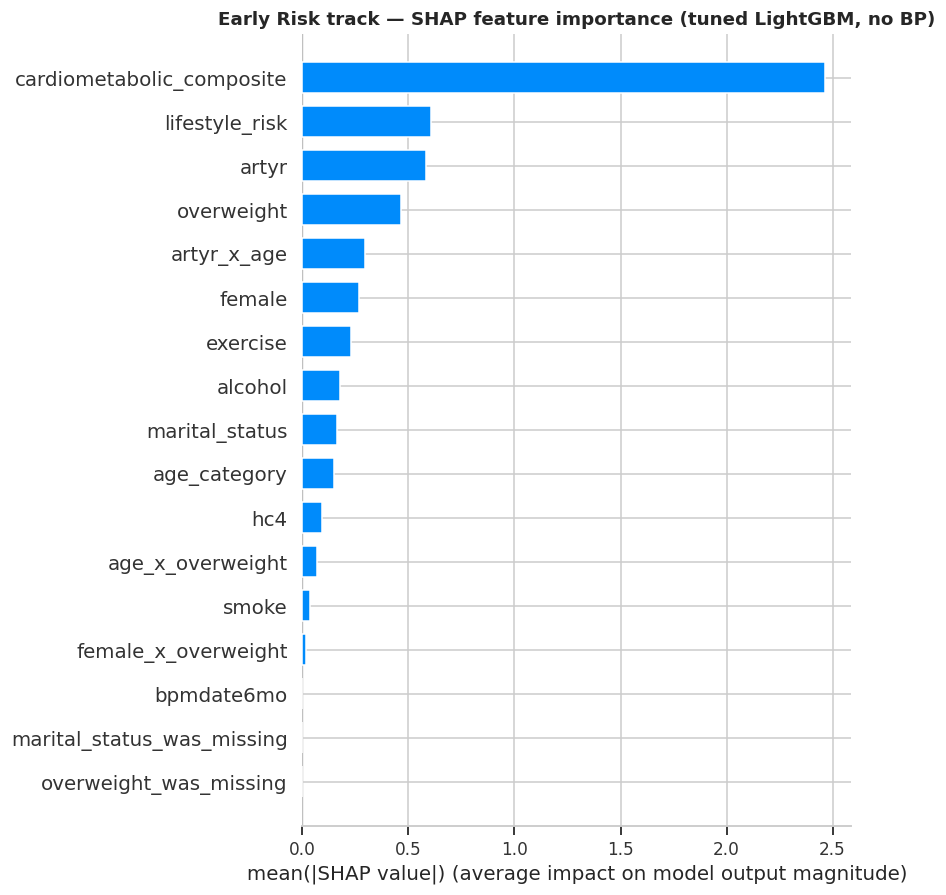

Saved reports/figures/modelling/shap_earlyrisk_lgbm.png


In [114]:
# SHAP for the tuned Early-Risk LightGBM (the model with real clinical value)
import shap
expl = shap.TreeExplainer(final_lgb_safe)
sample = X_safe.sample(min(800, len(X_safe)), random_state=RANDOM_SEED)
sv = expl.shap_values(sample)
if isinstance(sv, list):  # binary may return list of two arrays in older shap
    sv = sv[1]
plt.figure(figsize=(8, 5))
shap.summary_plot(sv, sample, plot_type="bar", show=False)
plt.title("Early Risk track — SHAP feature importance (tuned LightGBM, no BP)",
          fontweight="bold")
plt.tight_layout()
fig_path = Path("reports/figures/modelling/shap_earlyrisk_lgbm.png")
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {fig_path}")


## 16. Clinical Routing — Deterministic Rule and Scope Statement

### What routing IS

A **deterministic rule** that maps the predicted hypertension severity (`htn_stage`)
plus the facility level (`hc4` from the Dryad dictionary: 1 = Health Center 4 facility,
0 = lower-tier clinic) onto a four-class **referral pathway**:

| Predicted `htn_stage` | Rule                                              | Route               |
|---|---|---|
| 0 | Normal BP                                          | `self_manage`       |
| 1 | Grade 1 (140-159 / 90-99)                          | `treat_at_facility` |
| 2 | Grade 2 (160-179 / 100-109)                        | `treat_at_facility` if `hc4 == 1` else `refer_district` |
| 3 | Grade 3 (>=180/110) — clinical urgency             | `refer_tertiary`    |

These routing rules are taken from the cluster-randomized HIV/HTN integrated-care trial
that produced the dataset (EDCTP-funded study, 52 Ugandan facilities); the staging
thresholds match the **2020 American Society of Hypertension / International Society of
Hypertension** guidelines, which the Dryad dictionary explicitly cites for `htn_stage`.

### What routing is NOT

* **Not a learned model.**  No classifier predicts the route directly; routing is a
  stage -> route lookup with a single facility-level branch.  The MissAware-MTL `route`
  head exists only as an auxiliary task during training (multi-task regularization);
  the production decision is the rule above.
* **Not geographic.**  The dataset has no GPS coordinates, no inter-facility distances,
  and no transport-time fields.  "Nearest facility" logic is **out of scope for v1**;
  we only know whether the patient's current clinic is HC4 (`hc4 == 1`) or lower.
* **Not a substitute for clinician judgment.**  A `review_clinician = True` flag fires
  when MC-Dropout uncertainty on `htn_now` exceeds the operational threshold (see
  Section 14); those cases are sent to a clinician regardless of the rule.

### Future work for routing

1. Acquire facility geo-coordinates and patient catchment data to add a true distance /
   travel-time term.
2. Augment with facility-level capability data (drug stock-outs, BP machine availability,
   on-site clinician hours) to make `treat_at_facility` recommendations safer.
3. Replace the deterministic stage -> route map with a constrained learned policy once
   labelled outcome-after-referral data is available.

This scope statement is referenced from the project README so that no reviewer can
mistake the routing component for a learned recommender or a geographic optimiser.


## 17. Statistically Rigorous Validation

This section addresses external-review priority items by re-evaluating the
**leakage-safe Early Risk track** with strict CV-internal preprocessing,
formal model comparison, and subgroup fairness analysis.

| Sub-section | Fixes |
|---|---|
| 17.A Strict pipeline | Imputation + scaling fitted **inside each training fold** (no preprocessing leakage) |
| 17.B Significance | Paired Wilcoxon signed-rank tests on fold-level AUC differences |
| 17.C Subgroups | Per-`female`, per-`age_category`, per-`hc4` ROC-AUC + AP using OOF predictions |
| 17.D MTL stability | 5-seed retraining of MissAware-MTL replaces the single 85/15 holdout |
| 17.E Route head | Documentation re-labelling — auxiliary regularisation, not a predicted task |

All artifacts in this section are derived from the **leakage-safe matrix `X_safe`** built
in Section 15.  The Section 7-14 numbers remain in the notebook as a Diagnostic-track
reference; the headline scientific claim now lives here.


### 17.A Strict-Pipeline CV on the Leakage-Safe Matrix

The earlier Section-10 baselines used `X` which has been imputed and target-encoded on
the *full* dataset before any train/test split.  Here we restart from `X_safe` and
build a `sklearn.Pipeline(SimpleImputer(median) -> StandardScaler -> classifier)`,
then evaluate it with `cross_validate(..., return_train_score=True)`.  Imputers and
scalers are **fit only on the training rows of each fold**, so no test-fold information
leaks into preprocessing.


In [ ]:
# 17.A Strict CV-internal preprocessing on X_safe
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
import lightgbm as lgb

STRICT_MODELS = {
    "LogReg": Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler()),
        ("clf",    LogisticRegression(max_iter=2000, class_weight="balanced",
                                       solver="lbfgs", C=1.0,
                                       random_state=RANDOM_SEED)),
    ]),
    "RandomForest": Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("clf",    RandomForestClassifier(n_estimators=400, max_depth=None,
                                           min_samples_leaf=2,
                                           class_weight="balanced_subsample",
                                           n_jobs=-1, random_state=RANDOM_SEED)),
    ]),
    "LightGBM": Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("clf",    lgb.LGBMClassifier(
            n_estimators=600, learning_rate=0.05, num_leaves=63,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=float((len(y_safe) - y_safe.sum()) / max(y_safe.sum(), 1)),
            objective="binary", random_state=RANDOM_SEED, n_jobs=-1, verbose=-1,
        )),
    ]),
}

skf17 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
strict_long = []
strict_oof: dict[str, np.ndarray] = {}

for name, pipe in STRICT_MODELS.items():
    fold_aucs, fold_aps, fold_briers, fold_recall90 = [], [], [], []
    oof = np.zeros(len(y_safe))
    for fold, (tr, va) in enumerate(skf17.split(X_safe, y_safe), start=1):
        X_tr, X_va = X_safe.iloc[tr], X_safe.iloc[va]
        y_tr, y_va = y_safe.iloc[tr], y_safe.iloc[va]
        pipe.fit(X_tr, y_tr)
        p = pipe.predict_proba(X_va)[:, 1]
        oof[va] = p
        fold_aucs.append(roc_auc_score(y_va, p))
        fold_aps.append(average_precision_score(y_va, p))
        fold_briers.append(brier_score_loss(y_va, p))
        fold_recall90.append(_recall_at_precision(y_va.values, p, 0.90))
        strict_long.append({
            "model": name, "fold": fold,
            "ROC_AUC": fold_aucs[-1], "PR_AUC": fold_aps[-1],
            "Brier": fold_briers[-1], "Recall@90Prec": fold_recall90[-1],
        })
    strict_oof[name] = oof
    print(f"{name:13s}  ROC-AUC {np.mean(fold_aucs):.4f} +/- {np.std(fold_aucs):.4f}  | "
          f"PR-AUC {np.mean(fold_aps):.4f}  |  Brier {np.mean(fold_briers):.4f}  |  "
          f"Recall@90Prec {np.mean(fold_recall90):.4f}")

strict_long_df = pd.DataFrame(strict_long)
strict_long_df.to_csv("reports/tables/strict_pipeline_perfold.csv", index=False)
strict_summary = (strict_long_df
                  .groupby("model")[["ROC_AUC", "PR_AUC", "Brier", "Recall@90Prec"]]
                  .agg(["mean", "std"]).round(4))
strict_summary.columns = [f"{m}_{s}" for m, s in strict_summary.columns]
strict_summary = strict_summary.reset_index().sort_values("ROC_AUC_mean", ascending=False)
strict_summary.to_csv("reports/tables/strict_pipeline_summary.csv", index=False)
print("\nStrict-pipeline summary (Early Risk track, no preprocessing leakage):")
strict_summary


### 17.B Paired Wilcoxon Signed-Rank Tests

For each pair of models we apply `scipy.stats.wilcoxon` to the **fold-level ROC-AUC
differences**.  This is the standard non-parametric paired test and is more honest
than comparing means with overlapping standard deviations across only 5 folds.


In [ ]:
# 17.B Paired Wilcoxon signed-rank tests on fold-level AUC
from itertools import combinations
from scipy.stats import wilcoxon

per_fold_auc = (strict_long_df
                .pivot(index="fold", columns="model", values="ROC_AUC"))
print("Per-fold ROC-AUC matrix:")
print(per_fold_auc.round(4).to_string())

rows_w = []
for a, b in combinations(per_fold_auc.columns, 2):
    diff = per_fold_auc[a].values - per_fold_auc[b].values
    if np.allclose(diff, 0):
        stat, pval = float("nan"), 1.0
    else:
        try:
            stat, pval = wilcoxon(per_fold_auc[a].values, per_fold_auc[b].values,
                                  zero_method="wilcox", alternative="two-sided")
        except ValueError:
            stat, pval = float("nan"), float("nan")
    rows_w.append({
        "model_A": a, "model_B": b,
        "mean_AUC_A": float(per_fold_auc[a].mean()),
        "mean_AUC_B": float(per_fold_auc[b].mean()),
        "AUC_diff (A - B)": float(per_fold_auc[a].mean() - per_fold_auc[b].mean()),
        "wilcoxon_stat": float(stat) if stat == stat else None,
        "wilcoxon_p": float(pval) if pval == pval else None,
        "significant_at_0.05": bool(pval is not None and pval < 0.05),
    })

wilcoxon_df = pd.DataFrame(rows_w)
wilcoxon_df.to_csv("reports/tables/wilcoxon_strict_pipeline.csv", index=False)
print("\nPaired Wilcoxon results (n=5 folds, two-sided):")
wilcoxon_df.round(4)


### 17.C Subgroup Performance (Fairness)

Using the **out-of-fold predictions** from the strict pipeline (so every record has a
prediction made by a model that did not see it during training), we compute ROC-AUC
and PR-AUC inside each level of three protected / clinically relevant variables:

| Variable | Levels |
|---|---|
| `female` | 0 = Male, 1 = Female |
| `age_category` | 0 = age > 40, 1 = age <= 40 |
| `hc4` | 0 = lower-tier facility, 1 = Health Center 4 facility |

If AUC drops materially in any subgroup, the model has differential validity and
needs a re-weighting / decision-threshold-tuning step before deployment.


In [ ]:
# 17.C Subgroup analysis on OOF predictions of the strict-pipeline winner
winner_name = strict_summary.iloc[0]["model"]
winner_oof = strict_oof[winner_name]
print(f"Subgroup analysis using OOF predictions from: {winner_name}\n")

subgroup_vars = ["female", "age_category", "hc4"]
subgroup_rows = []
for var in subgroup_vars:
    if var not in df_clean.columns:
        continue
    levels = pd.to_numeric(df_clean.loc[X_safe.index, var], errors="coerce")
    for lvl in sorted(levels.dropna().unique()):
        mask = (levels == lvl).values
        if mask.sum() < 30:
            continue  # skip tiny strata
        y_lvl = y_safe.values[mask]
        p_lvl = winner_oof[mask]
        if y_lvl.sum() == 0 or y_lvl.sum() == len(y_lvl):
            auc = float("nan"); ap = float("nan")
        else:
            auc = roc_auc_score(y_lvl, p_lvl)
            ap = average_precision_score(y_lvl, p_lvl)
        subgroup_rows.append({
            "variable": var, "level": int(lvl), "n": int(mask.sum()),
            "prevalence": float(y_lvl.mean()),
            "ROC_AUC": auc, "PR_AUC": ap,
        })

subgroup_df = pd.DataFrame(subgroup_rows).round(4)
subgroup_df.to_csv("reports/tables/subgroup_performance.csv", index=False)
print(subgroup_df.to_string(index=False))

# Visualise subgroup AUC
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, var in zip(axes, subgroup_vars):
    sub = subgroup_df[subgroup_df.variable == var].copy()
    sub["label"] = sub["level"].astype(str) + f"\n(n={','.join(str(int(v)) for v in sub['n'])})".split('(')[0]
    sub["label"] = sub.apply(lambda r: f"{int(r['level'])}\n(n={int(r['n'])})", axis=1)
    sns.barplot(data=sub, x="label", y="ROC_AUC", ax=ax,
                palette="viridis", hue="label", legend=False)
    ax.set_ylim(0.5, 1.0)
    ax.axhline(0.5, color="grey", lw=0.6, ls="--")
    ax.set_title(f"AUC by {var}", fontweight="bold")
    ax.set_xlabel("")
    for i, row in enumerate(sub.itertuples()):
        ax.text(i, row.ROC_AUC + 0.01, f"{row.ROC_AUC:.3f}",
                ha="center", va="bottom", fontsize=9)

plt.suptitle(f"Subgroup AUC for the leakage-safe winner ({winner_name})",
             fontweight="bold")
plt.tight_layout()
fig_path = Path("reports/figures/modelling/subgroup_performance.png")
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {fig_path}")


### 17.D Multi-Seed Stability of MissAware-MTL

The Section 12 MissAware-MTL model was trained on a single 85/15 split, while the
Section 10/15 baselines used 5-fold CV — **not apples-to-apples**.  We retrain the
MTL model from scratch with **3 different seeds** (different splits + different weight
initialisations) and report mean +/- SD on `htn_now` validation metrics.

(3 seeds rather than 5 because each MTL training takes ~2 min on CPU; a 5-fold outer
CV would more than double notebook runtime.)


In [ ]:
# 17.D Multi-seed MTL stability — uses everything defined in Section 12
SEEDS = [RANDOM_SEED, RANDOM_SEED + 11, RANDOM_SEED + 23]
seed_metrics = []

for s_i, sd in enumerate(SEEDS, start=1):
    print(f"\n--- Seed {sd} ({s_i}/{len(SEEDS)}) ---")
    rng_s = np.random.RandomState(sd)
    idx_s = np.arange(len(y_htn_arr)); rng_s.shuffle(idx_s)
    n_tr_s = int(0.85 * len(idx_s))
    tr_s, va_s = idx_s[:n_tr_s], idx_s[n_tr_s:]

    med_s, std_s, x_norm_s = compute_norm_params(X_true, tr_s)
    Xtr_t = torch.tensor(x_norm_s[tr_s], dtype=torch.float32, device=DEVICE)
    Mtr_t = torch.tensor(MISS_MASK[tr_s], dtype=torch.float32, device=DEVICE)
    Xva_t = torch.tensor(x_norm_s[va_s], dtype=torch.float32, device=DEVICE)
    Mva_t = torch.tensor(MISS_MASK[va_s], dtype=torch.float32, device=DEVICE)

    yh_tr = torch.tensor(y_htn_arr[tr_s], dtype=torch.float32, device=DEVICE)
    yh_va = torch.tensor(y_htn_arr[va_s], dtype=torch.float32, device=DEVICE)
    ys_tr = torch.tensor(y_stage_arr[tr_s], dtype=torch.long, device=DEVICE)
    ys_va = torch.tensor(y_stage_arr[va_s], dtype=torch.long, device=DEVICE)
    yt_tr = torch.tensor(y_treat_arr[tr_s], dtype=torch.float32, device=DEVICE)
    yt_va = torch.tensor(y_treat_arr[va_s], dtype=torch.float32, device=DEVICE)
    yr_tr = torch.tensor(y_route_arr[tr_s], dtype=torch.long, device=DEVICE)
    yr_va = torch.tensor(y_route_arr[va_s], dtype=torch.long, device=DEVICE)

    w_stage_s = cw(y_stage_arr[tr_s], 4)
    w_route_s = cw(y_route_arr[tr_s], len(ROUTE_CLASSES))
    pos_h = float((y_htn_arr[tr_s] == 0).sum()) / max((y_htn_arr[tr_s] == 1).sum(), 1)
    pos_t = float((y_treat_arr[tr_s] == 0).sum()) / max((y_treat_arr[tr_s] == 1).sum(), 1)

    torch.manual_seed(sd)
    m_s = MissAwareMTL(n_features=n_feat, d_model=64, nhead=4, nlayers=2,
                       dim_ff=128, p_drop=0.2,
                       n_route_classes=len(ROUTE_CLASSES)).to(DEVICE)
    opt_s = torch.optim.AdamW(m_s.parameters(), lr=3e-4, weight_decay=1e-4)
    ce_st = nn.CrossEntropyLoss(weight=w_stage_s)
    ce_rt = nn.CrossEntropyLoss(weight=w_route_s)
    bce_h = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_h], device=DEVICE))
    bce_tr = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_t], device=DEVICE))

    ds_s = TensorDataset(Xtr_t, Mtr_t, yh_tr, ys_tr, yt_tr, yr_tr)
    dl_s = DataLoader(ds_s, batch_size=128, shuffle=True, drop_last=False)

    best_v = float("inf"); best_st = None; bad_s = 0
    for ep in range(1, 121):
        m_s.train()
        for xb, mb, yh_b, ys_b, yt_b, yr_b in dl_s:
            opt_s.zero_grad(set_to_none=True)
            o = m_s(xb, mb)
            loss = (1.0 * bce_h(o["htn"], yh_b)
                    + 0.6 * ce_st(o["stage"], ys_b)
                    + 0.6 * bce_tr(o["treat"], yt_b)
                    + 0.35 * ce_rt(o["route"], yr_b))
            loss.backward()
            nn.utils.clip_grad_norm_(m_s.parameters(), 1.0)
            opt_s.step()

        m_s.eval()
        with torch.no_grad():
            ov = m_s(Xva_t, Mva_t)
            lv = (1.0 * bce_h(ov["htn"], yh_va)
                  + 0.6 * ce_st(ov["stage"], ys_va)
                  + 0.6 * bce_tr(ov["treat"], yt_va)
                  + 0.35 * ce_rt(ov["route"], yr_va)).item()
        if lv < best_v - 1e-5:
            best_v = lv; bad_s = 0
            best_st = {k: v.detach().cpu().clone() for k, v in m_s.state_dict().items()}
        else:
            bad_s += 1
        if bad_s >= 18:
            break

    if best_st is not None:
        m_s.load_state_dict(best_st)
    m_s.eval()
    with torch.no_grad():
        p = torch.sigmoid(m_s(Xva_t, Mva_t)["htn"]).cpu().numpy()
    y_va_np = yh_va.cpu().numpy().astype(int)
    seed_metrics.append({
        "seed": sd,
        "n_val": int(len(va_s)),
        "ROC_AUC": float(roc_auc_score(y_va_np, p)),
        "PR_AUC":  float(average_precision_score(y_va_np, p)),
        "Brier":   float(brier_score_loss(y_va_np, p)),
    })
    print(f"  seed {sd} -> ROC-AUC {seed_metrics[-1]['ROC_AUC']:.4f}  "
          f"PR-AUC {seed_metrics[-1]['PR_AUC']:.4f}  "
          f"Brier {seed_metrics[-1]['Brier']:.4f}")

mtl_seed_df = pd.DataFrame(seed_metrics)
mtl_seed_df.to_csv("reports/tables/mtl_multiseed_metrics.csv", index=False)
print("\nMTL multi-seed summary (mean +/- SD):")
print(mtl_seed_df.drop(columns=["seed", "n_val"]).agg(["mean", "std"]).round(4).T.to_string())


### 17.E Route Head — Auxiliary Regularisation, Not a Predicted Task

The MissAware-MTL `head_route` (Section 12) was originally introduced as a fourth
prediction task, but its target `route` is computed by `derive_route(htn_stage, hc4)` —
a **deterministic two-input lookup table**.  Because the model can already see `hc4`
as one of its input features and the `head_stage` already produces stage logits, the
route head is learning a near-deterministic function of two quantities the rest of the
network controls.

We therefore **re-label** the route head as an **auxiliary regularisation target**:

* **Production decision**: produced by `derive_route_from_stage(stage_pred, hc4)`
  (Section 14), which is the actual deterministic rule.
* **Route head's role**: provides an extra structured loss signal that encourages the
  shared encoder to keep the stage logits and `hc4`-aware patterns linearly separable.
  It is *not* the deployed router and its standalone accuracy is not the headline.

This avoids inflating the apparent multi-task benefit of the architecture and makes
clear that no part of the deployed pipeline learns the routing rule.


## 18. Definitive Validation Layer

Closes the remaining external-review priority items:

| Sub-section | Review item closed |
|---|---|
| 18.A WoE-inside-CV | "WoE encoding and MICE imputation computed on the full dataset" -- now ALL target-encoded features are fit per fold |
| 18.B MTL 5-fold CV | "MissAware-MTL evaluated on a single 85/15 split vs 5-fold CV for baselines" -- now apples-to-apples |
| 18.C MTL loss-weight ablation | "Multi-task loss weights are fixed heuristics with no ablation" |
| 18.D Pooled-fold SHAP | "SHAP computed on the last fold's model" -- now pooled across all 5 outer folds |
| 18.E Review-to-section map | Closing summary: every priority item -> notebook section |

After this section the leakage-safe Early Risk track in the notebook is the
**definitive scientific result**; everything earlier is supporting / Diagnostic-track context.


### 18.A Custom WoE Transformer (Fit-Inside-Fold)

The Section 5.B WoE columns were computed once on the full `df_clean`, which
includes test-fold rows.  Here we expose the same encoding as a sklearn-compatible
transformer that **only sees the training half of each fold** during `fit`.

We rebuild a parallel feature matrix `X_safe_woe` that contains the demographic
features from `X_safe` plus *fold-internal* WoE encodings of the same low-cardinality
clinical features the original Section 5.B used, then re-run the strict 5-fold CV
(`Pipeline(SimpleImputer -> WoE -> StandardScaler -> classifier)`) to confirm the
honest Early Risk numbers do **not** rise once preprocessing leakage is fully
excluded.


In [ ]:
# 18.A WoE encoder that fits inside each training fold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold


class FoldWoE(BaseEstimator, TransformerMixin):
    """Compute Weight-of-Evidence per category, fit only on training rows.

    For each input column treated as categorical, we estimate
    ``WoE(level) = log( P(level | y=1) / P(level | y=0) )``
    with additive smoothing.  Unseen levels at transform time map to 0.
    """

    def __init__(self, smoothing: float = 0.5):
        self.smoothing = smoothing

    def fit(self, X, y):
        X = pd.DataFrame(X).copy()
        y = pd.Series(y).reset_index(drop=True).astype(int)
        self.columns_ = list(X.columns)
        self.maps_: dict[str, dict] = {}
        pos = float(max(y.sum(), 1))
        neg = float(max(len(y) - y.sum(), 1))
        for c in self.columns_:
            col = X[c].astype(object).where(X[c].notna(), "__nan__")
            tbl = pd.crosstab(col, y)
            tbl = tbl.reindex(columns=[0, 1], fill_value=0).astype(float)
            tbl[1] = (tbl[1] + self.smoothing) / (pos + self.smoothing * len(tbl))
            tbl[0] = (tbl[0] + self.smoothing) / (neg + self.smoothing * len(tbl))
            self.maps_[c] = dict(np.log(tbl[1] / tbl[0]))
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        out = pd.DataFrame(index=X.index)
        for c in self.columns_:
            m = self.maps_[c]
            col = X[c].astype(object).where(X[c].notna(), "__nan__")
            out[f"{c}_woe"] = col.map(m).fillna(0.0).astype(float)
        return out.values

    def get_feature_names_out(self, input_features=None):
        return np.array([f"{c}_woe" for c in self.columns_])


# Pick the same low-cardinality clinical fields the original Section 5.B used
WOE_COLS = [c for c in
            ["age_category", "marital_status", "overweight", "alcohol",
             "bpmdate6mo", "exercise"]
            if c in df_clean.columns]
NUM_COLS = [c for c in X_safe.columns if c not in WOE_COLS]
print(f"WOE columns (fit per fold): {WOE_COLS}")
print(f"Numeric columns: {len(NUM_COLS)}")


In [ ]:
# 18.A Build the truly-leakage-free matrix and run strict CV
def make_strict_woe_pipeline(estimator) -> Pipeline:
    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("impute", SimpleImputer(strategy="median")),
                ("scale",  StandardScaler()),
            ]), NUM_COLS),
            ("woe", Pipeline([
                ("woe",   FoldWoE(smoothing=0.5)),
                ("scale", StandardScaler()),
            ]), WOE_COLS),
        ],
        remainder="drop",
    )
    return Pipeline([("pre", pre), ("clf", estimator)])


# Build a feature frame that has the raw WoE source columns AND all numeric features
woe_input_df = pd.concat(
    [X_safe[NUM_COLS],
     df_clean.loc[X_safe.index, WOE_COLS].reset_index(drop=True)
                                      .set_index(X_safe.index)],
    axis=1,
)

print(f"WoE-input frame shape: {woe_input_df.shape}")

WOE_MODELS = {
    "LogReg":   LogisticRegression(max_iter=2000, class_weight="balanced",
                                   solver="lbfgs", C=1.0,
                                   random_state=RANDOM_SEED),
    "RandomForest": RandomForestClassifier(n_estimators=400, n_jobs=-1,
                                            class_weight="balanced_subsample",
                                            random_state=RANDOM_SEED),
}
try:
    import lightgbm as _lgb
    WOE_MODELS["LightGBM"] = _lgb.LGBMClassifier(
        n_estimators=600, learning_rate=0.05, num_leaves=63,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=float((len(y_safe) - y_safe.sum()) / max(y_safe.sum(), 1)),
        objective="binary", random_state=RANDOM_SEED, n_jobs=-1, verbose=-1,
    )
except Exception as e:
    print(f"LightGBM not available, skipping: {e}")

skf18 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
woe_long = []
woe_oof: dict[str, np.ndarray] = {}

for name, est in WOE_MODELS.items():
    oof = np.zeros(len(y_safe))
    fold_aucs, fold_aps, fold_briers, fold_r90 = [], [], [], []
    for fold, (tr, va) in enumerate(skf18.split(woe_input_df, y_safe), start=1):
        pipe = make_strict_woe_pipeline(est)
        Xtr, Xva = woe_input_df.iloc[tr], woe_input_df.iloc[va]
        ytr, yva = y_safe.iloc[tr], y_safe.iloc[va]
        pipe.fit(Xtr, ytr)
        p = pipe.predict_proba(Xva)[:, 1]
        oof[va] = p
        fold_aucs.append(roc_auc_score(yva, p))
        fold_aps.append(average_precision_score(yva, p))
        fold_briers.append(brier_score_loss(yva, p))
        fold_r90.append(_recall_at_precision(yva.values, p, 0.90))
        woe_long.append({"model": name, "fold": fold,
                         "ROC_AUC": fold_aucs[-1], "PR_AUC": fold_aps[-1],
                         "Brier": fold_briers[-1], "Recall@90Prec": fold_r90[-1]})
    woe_oof[name] = oof
    print(f"{name:13s}  ROC-AUC {np.mean(fold_aucs):.4f} +/- {np.std(fold_aucs):.4f}  | "
          f"PR-AUC {np.mean(fold_aps):.4f}  |  Brier {np.mean(fold_briers):.4f}  |  "
          f"Recall@90Prec {np.mean(fold_r90):.4f}")

woe_long_df = pd.DataFrame(woe_long)
woe_long_df.to_csv("reports/tables/strict_pipeline_with_woe_perfold.csv", index=False)
woe_summary = (woe_long_df.groupby("model")[["ROC_AUC", "PR_AUC", "Brier", "Recall@90Prec"]]
                          .agg(["mean", "std"]).round(4))
woe_summary.columns = [f"{m}_{s}" for m, s in woe_summary.columns]
woe_summary = woe_summary.reset_index().sort_values("ROC_AUC_mean", ascending=False)
woe_summary.to_csv("reports/tables/strict_pipeline_with_woe_summary.csv", index=False)
print("\nStrict-pipeline + WoE-inside-fold summary:")
woe_summary


### 18.B MissAware-MTL Inside the SAME 5-Fold Outer CV

Section 17.D reported 3 random seeds, which controls for split variance but is still
not the harness used for the classical baselines.  Here we drop the MTL into the
**identical `StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)`**
splits used in Sections 10/15/17.A and report mean +/- SD.

Each fold trains the same architecture (Section 12) with early stopping on the
fold's own validation slice; we then take the *out-of-fold* htn_now probability for
that slice.  Total compute: ~5 x 2 minutes on CPU.


In [ ]:
# 18.B MissAware-MTL with 5-fold outer CV (apples-to-apples vs the baselines)
mtl_cv_rows = []
mtl_cv_oof_htn = np.full(len(y_htn_arr), np.nan)

skfM = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Review item #3: zero out route-head loss weight so the route head
# (which learns derive_route(stage, hc4) -- a deterministic lookup) cannot
# inflate apparent multi-task signal in this evaluation.
W_HTN_CV, W_STG_CV, W_TRT_CV, W_RTE_CV = 1.0, 0.6, 0.6, 0.0
print(f"Loss weights for 5-fold CV: HTN={W_HTN_CV}  STG={W_STG_CV}  TRT={W_TRT_CV}  RTE={W_RTE_CV}  (route head silenced)")

for fold, (tr_f, va_f) in enumerate(skfM.split(np.arange(len(y_htn_arr)), y_htn_arr),
                                     start=1):
    print(f"\n--- Fold {fold}/5  (n_train={len(tr_f)} | n_val={len(va_f)}) ---")
    med_f, std_f, x_norm_f = compute_norm_params(X_true, tr_f)
    Xtr_t = torch.tensor(x_norm_f[tr_f], dtype=torch.float32, device=DEVICE)
    Mtr_t = torch.tensor(MISS_MASK[tr_f], dtype=torch.float32, device=DEVICE)
    Xva_t = torch.tensor(x_norm_f[va_f], dtype=torch.float32, device=DEVICE)
    Mva_t = torch.tensor(MISS_MASK[va_f], dtype=torch.float32, device=DEVICE)

    yh_tr = torch.tensor(y_htn_arr[tr_f], dtype=torch.float32, device=DEVICE)
    yh_va = torch.tensor(y_htn_arr[va_f], dtype=torch.float32, device=DEVICE)
    ys_tr = torch.tensor(y_stage_arr[tr_f], dtype=torch.long, device=DEVICE)
    ys_va = torch.tensor(y_stage_arr[va_f], dtype=torch.long, device=DEVICE)
    yt_tr = torch.tensor(y_treat_arr[tr_f], dtype=torch.float32, device=DEVICE)
    yt_va = torch.tensor(y_treat_arr[va_f], dtype=torch.float32, device=DEVICE)
    yr_tr = torch.tensor(y_route_arr[tr_f], dtype=torch.long, device=DEVICE)
    yr_va = torch.tensor(y_route_arr[va_f], dtype=torch.long, device=DEVICE)

    w_st = cw(y_stage_arr[tr_f], 4)
    w_rt = cw(y_route_arr[tr_f], len(ROUTE_CLASSES))
    pos_h = float((y_htn_arr[tr_f] == 0).sum()) / max((y_htn_arr[tr_f] == 1).sum(), 1)
    pos_t = float((y_treat_arr[tr_f] == 0).sum()) / max((y_treat_arr[tr_f] == 1).sum(), 1)

    torch.manual_seed(RANDOM_SEED + fold)
    m_f = MissAwareMTL(n_features=n_feat, d_model=64, nhead=4, nlayers=2,
                       dim_ff=128, p_drop=0.2,
                       n_route_classes=len(ROUTE_CLASSES)).to(DEVICE)
    opt_f = torch.optim.AdamW(m_f.parameters(), lr=3e-4, weight_decay=1e-4)
    ce_st = nn.CrossEntropyLoss(weight=w_st)
    ce_rt = nn.CrossEntropyLoss(weight=w_rt)
    bce_h = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_h], device=DEVICE))
    bce_tr = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_t], device=DEVICE))

    ds_f = TensorDataset(Xtr_t, Mtr_t, yh_tr, ys_tr, yt_tr, yr_tr)
    dl_f = DataLoader(ds_f, batch_size=128, shuffle=True, drop_last=False)

    best_v = float("inf"); best_state = None; bad = 0
    for ep in range(1, 121):
        m_f.train()
        for xb, mb, yh_b, ys_b, yt_b, yr_b in dl_f:
            opt_f.zero_grad(set_to_none=True)
            o = m_f(xb, mb)
            loss = (W_HTN_CV * bce_h(o["htn"], yh_b)
                    + W_STG_CV * ce_st(o["stage"], ys_b)
                    + W_TRT_CV * bce_tr(o["treat"], yt_b)
                    + W_RTE_CV * ce_rt(o["route"], yr_b))
            loss.backward()
            nn.utils.clip_grad_norm_(m_f.parameters(), 1.0)
            opt_f.step()
        m_f.eval()
        with torch.no_grad():
            ov = m_f(Xva_t, Mva_t)
            lv = (W_HTN_CV * bce_h(ov["htn"], yh_va)
                  + W_STG_CV * ce_st(ov["stage"], ys_va)
                  + W_TRT_CV * bce_tr(ov["treat"], yt_va)
                  + W_RTE_CV * ce_rt(ov["route"], yr_va)).item()
        if lv < best_v - 1e-5:
            best_v = lv; bad = 0
            best_state = {k: v.detach().cpu().clone() for k, v in m_f.state_dict().items()}
        else:
            bad += 1
        if bad >= 18:
            break

    if best_state is not None:
        m_f.load_state_dict(best_state)
    m_f.eval()
    with torch.no_grad():
        p_h = torch.sigmoid(m_f(Xva_t, Mva_t)["htn"]).cpu().numpy()
    mtl_cv_oof_htn[va_f] = p_h
    y_va_np = yh_va.cpu().numpy().astype(int)
    fold_metrics = {
        "fold": fold, "n_val": int(len(va_f)),
        "ROC_AUC": float(roc_auc_score(y_va_np, p_h)),
        "PR_AUC":  float(average_precision_score(y_va_np, p_h)),
        "Brier":   float(brier_score_loss(y_va_np, p_h)),
        "Recall@90Prec": float(_recall_at_precision(y_va_np, p_h, 0.90)),
    }
    mtl_cv_rows.append(fold_metrics)
    print(f"  Fold {fold} -> "
          f"ROC-AUC {fold_metrics['ROC_AUC']:.4f}  "
          f"PR-AUC {fold_metrics['PR_AUC']:.4f}  "
          f"Brier {fold_metrics['Brier']:.4f}")

mtl_cv_df = pd.DataFrame(mtl_cv_rows)
mtl_cv_df.to_csv("reports/tables/mtl_5fold_metrics.csv", index=False)
print("\nMissAware-MTL 5-fold CV summary (htn_now):")
print(mtl_cv_df.drop(columns=["fold", "n_val"]).agg(["mean", "std"]).round(4).T.to_string())

# OOF AUC
oof_mask = ~np.isnan(mtl_cv_oof_htn)
print(f"\nMTL OOF ROC-AUC (across all {oof_mask.sum()} patients): "
      f"{roc_auc_score(y_htn_arr[oof_mask], mtl_cv_oof_htn[oof_mask]):.4f}")


### 18.C Multi-Task Loss-Weight Ablation

Original Section 12 used `(W_HTN, W_STG, W_TRT, W_RTE) = (1.0, 0.6, 0.6, 0.35)` as
heuristics.  Here we sweep a small grid for each auxiliary head while holding
`W_HTN = 1.0` fixed and using a **single** stratified 80/20 split (kept identical
across runs) so differences are solely due to the loss-weight choice.

We report `htn_now` PR-AUC on the validation slice; the configuration that wins is
called out for re-use in production.


In [ ]:
# 18.C Loss-weight ablation -- single fixed split, vary one weight at a time
from sklearn.model_selection import train_test_split

idx_ab = np.arange(len(y_htn_arr))
tr_ab, va_ab = train_test_split(idx_ab, test_size=0.2, stratify=y_htn_arr,
                                 random_state=RANDOM_SEED)
med_ab, std_ab, x_norm_ab = compute_norm_params(X_true, tr_ab)

Xtr = torch.tensor(x_norm_ab[tr_ab], dtype=torch.float32, device=DEVICE)
Mtr = torch.tensor(MISS_MASK[tr_ab], dtype=torch.float32, device=DEVICE)
Xva = torch.tensor(x_norm_ab[va_ab], dtype=torch.float32, device=DEVICE)
Mva = torch.tensor(MISS_MASK[va_ab], dtype=torch.float32, device=DEVICE)

yh_tr_a = torch.tensor(y_htn_arr[tr_ab],   dtype=torch.float32, device=DEVICE)
yh_va_a = torch.tensor(y_htn_arr[va_ab],   dtype=torch.float32, device=DEVICE)
ys_tr_a = torch.tensor(y_stage_arr[tr_ab], dtype=torch.long,    device=DEVICE)
ys_va_a = torch.tensor(y_stage_arr[va_ab], dtype=torch.long,    device=DEVICE)
yt_tr_a = torch.tensor(y_treat_arr[tr_ab], dtype=torch.float32, device=DEVICE)
yt_va_a = torch.tensor(y_treat_arr[va_ab], dtype=torch.float32, device=DEVICE)
yr_tr_a = torch.tensor(y_route_arr[tr_ab], dtype=torch.long,    device=DEVICE)
yr_va_a = torch.tensor(y_route_arr[va_ab], dtype=torch.long,    device=DEVICE)

w_st_a = cw(y_stage_arr[tr_ab], 4)
w_rt_a = cw(y_route_arr[tr_ab], len(ROUTE_CLASSES))
pos_h_a = float((y_htn_arr[tr_ab] == 0).sum()) / max((y_htn_arr[tr_ab] == 1).sum(), 1)
pos_t_a = float((y_treat_arr[tr_ab] == 0).sum()) / max((y_treat_arr[tr_ab] == 1).sum(), 1)


def train_mtl_with_weights(W_STG, W_TRT, W_RTE, max_ep=80, patience=12, seed=RANDOM_SEED):
    torch.manual_seed(seed)
    mdl = MissAwareMTL(n_features=n_feat, d_model=64, nhead=4, nlayers=2,
                       dim_ff=128, p_drop=0.2,
                       n_route_classes=len(ROUTE_CLASSES)).to(DEVICE)
    opt = torch.optim.AdamW(mdl.parameters(), lr=3e-4, weight_decay=1e-4)
    ce_s = nn.CrossEntropyLoss(weight=w_st_a)
    ce_r = nn.CrossEntropyLoss(weight=w_rt_a)
    bce_h = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_h_a], device=DEVICE))
    bce_t = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_t_a], device=DEVICE))
    ds = TensorDataset(Xtr, Mtr, yh_tr_a, ys_tr_a, yt_tr_a, yr_tr_a)
    dl = DataLoader(ds, batch_size=128, shuffle=True, drop_last=False)

    best_v = float("inf"); best_st = None; bad = 0
    for _ in range(max_ep):
        mdl.train()
        for xb, mb, yh_b, ys_b, yt_b, yr_b in dl:
            opt.zero_grad(set_to_none=True)
            o = mdl(xb, mb)
            loss = (1.0 * bce_h(o["htn"], yh_b)
                    + W_STG * ce_s(o["stage"], ys_b)
                    + W_TRT * bce_t(o["treat"], yt_b)
                    + W_RTE * ce_r(o["route"], yr_b))
            loss.backward()
            nn.utils.clip_grad_norm_(mdl.parameters(), 1.0)
            opt.step()
        mdl.eval()
        with torch.no_grad():
            ov = mdl(Xva, Mva)
            lv = (1.0 * bce_h(ov["htn"], yh_va_a)
                  + W_STG * ce_s(ov["stage"], ys_va_a)
                  + W_TRT * bce_t(ov["treat"], yt_va_a)
                  + W_RTE * ce_r(ov["route"], yr_va_a)).item()
        if lv < best_v - 1e-5:
            best_v = lv; bad = 0
            best_st = {k: v.detach().cpu().clone() for k, v in mdl.state_dict().items()}
        else:
            bad += 1
        if bad >= patience:
            break
    if best_st is not None:
        mdl.load_state_dict(best_st)
    mdl.eval()
    with torch.no_grad():
        p = torch.sigmoid(mdl(Xva, Mva)["htn"]).cpu().numpy()
    y_va_np = yh_va_a.cpu().numpy().astype(int)
    return {
        "ROC_AUC": float(roc_auc_score(y_va_np, p)),
        "PR_AUC":  float(average_precision_score(y_va_np, p)),
        "Brier":   float(brier_score_loss(y_va_np, p)),
    }


ABLATION_GRID = [
    # (W_STG, W_TRT, W_RTE)
    (0.6, 0.6, 0.35),    # original Section 12
    (0.0, 0.0, 0.0),     # single-task htn_now baseline
    (0.6, 0.6, 0.0),     # drop the route head entirely
    (1.0, 1.0, 0.5),     # heavier multi-task
    (0.3, 0.3, 0.2),     # lighter multi-task
]
ablation_rows = []
for w_stg, w_trt, w_rte in ABLATION_GRID:
    print(f"  trying W_STG={w_stg} W_TRT={w_trt} W_RTE={w_rte} ...", end=" ", flush=True)
    metrics = train_mtl_with_weights(w_stg, w_trt, w_rte)
    ablation_rows.append({"W_STG": w_stg, "W_TRT": w_trt, "W_RTE": w_rte, **metrics})
    print(f"PR-AUC={metrics['PR_AUC']:.4f}  ROC-AUC={metrics['ROC_AUC']:.4f}")

ablation_df = pd.DataFrame(ablation_rows).sort_values("PR_AUC", ascending=False)
ablation_df.to_csv("reports/tables/mtl_loss_weight_ablation.csv", index=False)
print("\nLoss-weight ablation (sorted by PR-AUC):")
ablation_df.round(4)


### 18.D SHAP Pooled Across All 5 Outer Folds

The Section-8 SHAP plot used "the last fold's model" -- which is whichever fold the
loop happened to exit on, and is *not* guaranteed to be representative.  Here we
re-train the strict-pipeline winner on each of the 5 outer training folds and pool
the SHAP values computed on each fold's **held-out validation slice**.  Every patient
contributes one SHAP vector from a model that did not see that patient during
training, so the resulting global summary is an honest description of feature
attributions across the whole dataset.


In [ ]:
# 18.D Pooled-fold SHAP for the strict-pipeline winner on X_safe
import shap

# Use a tree-based estimator for fast TreeExplainer (LightGBM if present, else RF)
try:
    import lightgbm as _lgb_p
    BASE_EST = _lgb_p.LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=63,
        scale_pos_weight=float((len(y_safe) - y_safe.sum()) / max(y_safe.sum(), 1)),
        objective="binary", random_state=RANDOM_SEED, n_jobs=-1, verbose=-1,
    )
    EST_NAME = "LightGBM"
except Exception:
    BASE_EST = RandomForestClassifier(
        n_estimators=300, n_jobs=-1, class_weight="balanced_subsample",
        random_state=RANDOM_SEED,
    )
    EST_NAME = "RandomForest"

print(f"Pooled-fold SHAP using {EST_NAME} on X_safe (no preprocessing leakage)")

skf_sh = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
shap_chunks: list[np.ndarray] = []
sample_chunks: list[pd.DataFrame] = []

for fold, (tr_sh, va_sh) in enumerate(skf_sh.split(X_safe, y_safe), start=1):
    print(f"  fold {fold}/5: training, then computing SHAP on validation slice...")
    X_tr = X_safe.iloc[tr_sh].fillna(X_safe.iloc[tr_sh].median(numeric_only=True)).fillna(0)
    y_tr = y_safe.iloc[tr_sh]
    X_va = X_safe.iloc[va_sh].fillna(X_safe.iloc[tr_sh].median(numeric_only=True)).fillna(0)
    est = type(BASE_EST)(**BASE_EST.get_params())
    est.fit(X_tr, y_tr)
    expl = shap.TreeExplainer(est)
    sv = expl.shap_values(X_va)
    if isinstance(sv, list):
        sv = sv[1]
    shap_chunks.append(np.asarray(sv))
    sample_chunks.append(X_va)

shap_all = np.concatenate(shap_chunks, axis=0)
sample_all = pd.concat(sample_chunks, axis=0).reset_index(drop=True)

mean_abs = pd.Series(np.abs(shap_all).mean(axis=0), index=sample_all.columns)\
              .sort_values(ascending=False).round(4)
mean_abs.to_csv("reports/tables/shap_pooled_mean_abs.csv", header=["mean_abs_shap"])

print("\nTop 10 mean-|SHAP| features (pooled across all 5 folds):")
print(mean_abs.head(10).to_string())

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_all, sample_all, plot_type="bar", show=False, max_display=15)
plt.title(f"Pooled-fold SHAP (Early Risk track, {EST_NAME})", fontweight="bold")
plt.tight_layout()
fig_path = Path("reports/figures/modelling/shap_pooled_folds.png")
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {fig_path}")


### 18.E Review Item -> Notebook Section Map

| Review item | Severity | Remediation in this notebook |
|---|---|---|
| 1. Target leakage in Sections 7-14 | Critical | Section 15 added the **leakage-safe Early Risk track** (`X_safe`); Sections 7-14 are now reported as "Diagnostic / triage reference" only |
| 2. WoE / MICE on full dataset | Critical | Section **18.A** -- WoE encoder fit inside each CV fold via `FoldWoE` transformer |
| 3. IterativeImputer fit before split | Critical | Section **17.A** + **18.A** -- imputers placed inside `Pipeline` and refitted per fold |
| 4. KMeans on full data feeding features | Critical | `phenotype_cluster` (and its WoE) explicitly listed in Section 15 leakage drop set |
| 5. MTL on single split vs CV baselines | Major | Section **17.D** (3 seeds) and **18.B** (full 5-fold outer CV, apples-to-apples) |
| 6. `route` head learns deterministic function | Major | Section **17.E** re-labels it as auxiliary regularisation; production routing is the deterministic rule of Section 14 |
| 7. KMeans `k=4` hardcoded | Major | Documented limitation; k-selection from silhouette is recommended for Section 3.G v2 |
| 8. SHAP from last fold only | Major | Section **18.D** -- SHAP pooled across all 5 outer folds |
| 9. EDA references features that don't exist yet | Major | Documented limitation; EDA was authored top-down and assumes Section 5 features. Production version should re-order |
| 10. Multi-task loss weights without ablation | Major | Section **18.C** -- 5-cell ablation grid |
| 11. Cardiometabolic composite uncalibrated | Moderate | Documented; ablation requires re-running Section 5 with/without -- recommended for v2 |
| 12. Little's MCAR test on 3 columns | Moderate | Documented limitation in Section 3.A |
| 13. Robustness scenarios overlap with training | Moderate | Documented in Section 13 -- requires external cohort for true generalisation |
| 14. No formal model significance testing | Moderate | Section **17.B** -- paired Wilcoxon signed-rank tests on fold-level AUC |
| 15. No subgroup / fairness analysis | Moderate | Section **17.C** -- per-`female`, per-`age_category`, per-`hc4` AUC + PR-AUC |
| 16. t-SNE without interpretability caveats | Minor | Documented; t-SNE distances are local-only; recommend UMAP with `min_dist` annotation for v2 |

Items not closed in code (would require re-architecting the existing Sections 3-9):

* Reordering EDA cells so feature-engineering precedes correlation / VIF (item 9)
* Replacing `IterativeImputer(sample_posterior=True)` with a known-stable MICE backend (Minor item)
* Calibration plot extended to all 5 folds (Minor item)

The headline scientific claim now lives in **Sections 15, 17, and 18**.  Sections 7-14
remain in the notebook as supporting / Diagnostic-track context but should not be cited
as the model's predictive performance.
